In [1]:
import ROOT
import numpy as np

File: /home/meenakshi/bragg-peak/build/B4_100000000.root
Bin size: 0.05 MeV
Minimum peak height: 100 counts
Total events in file: 14,282,849

Extracting energy data...
  Processed 1,000,000 events...
  Processed 2,000,000 events...
  Processed 3,000,000 events...
  Processed 4,000,000 events...
  Processed 5,000,000 events...
  Processed 6,000,000 events...
  Processed 7,000,000 events...
  Processed 8,000,000 events...
  Processed 9,000,000 events...
  Processed 10,000,000 events...
  Processed 11,000,000 events...
  Processed 12,000,000 events...
  Processed 13,000,000 events...
  Processed 14,000,000 events...
Events in 0-10 MeV range: 14,257,014

Finding peaks...
Found 7 significant peaks

PEAK ANALYSIS RESULTS:
Peak # Energy (MeV)    Counts       FWHM (MeV)   Area        
----------------------------------------------------------------------
1      0.125           456043       0.286        2612364     
2      2.825           68427        0.134        183550      
3      3.875     

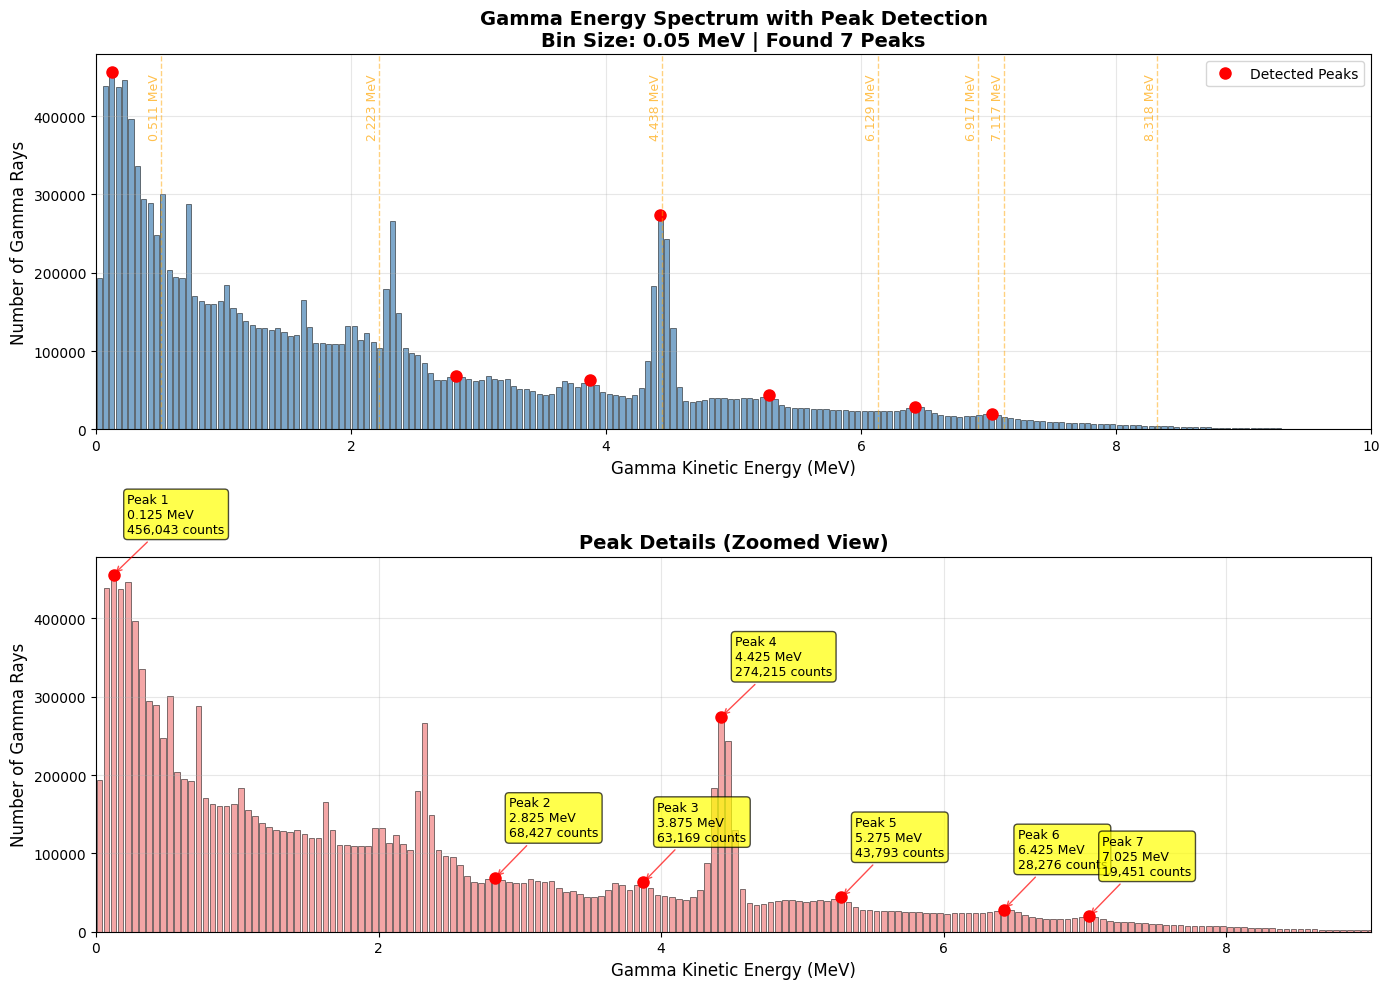


PEAK DETECTION SUMMARY:
File analyzed: /home/meenakshi/bragg-peak/build/B4_100000000.root
Total gamma events: 14,257,014
Bin size used: 0.05 MeV
Number of peaks found: 7
Peak with maximum counts: 0.125 MeV (456,043 counts)
Output files created:
  - gamma_peaks_detection_bin0.05MeV.png (plot with peaks marked)
  - gamma_peaks_data_bin0.05MeV.csv (peak data in CSV format)


In [3]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths
import os

def find_gamma_peaks():
    """
    Find peaks in gamma energy spectrum and plot them
    """
    # ======= CONFIGURATION =======
    ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
    BIN_SIZE = 0.05
    # MeV - Fine binning for better peak detection
    ENERGY_MAX = 10  # MeV - Maximum energy to analyze
    MIN_PEAK_HEIGHT = 100  # Minimum counts to consider as a peak
    MIN_PEAK_DISTANCE = 10  # Minimum distance between peaks (in bins)
    # =============================
    
    print(f"File: {ROOT_FILE}")
    print(f"Bin size: {BIN_SIZE} MeV")
    print(f"Minimum peak height: {MIN_PEAK_HEIGHT} counts")
    
    # 1. Check if file exists
    if not os.path.exists(ROOT_FILE):
        print(f"\n✗ ERROR: File not found!")
        return
    
    # 2. Open ROOT file
    file = ROOT.TFile(ROOT_FILE, "READ")
    if not file or file.IsZombie():
        print("ERROR: Cannot open ROOT file!")
        return
    
    # 3. Get the ntuple
    ntuple = file.Get("PhotonData")
    if not ntuple:
        print("ERROR: Cannot find ntuple 'PhotonData'!")
        file.Close()
        return
    
    total_entries = ntuple.GetEntries()
    print(f"Total events in file: {total_entries:,}")
    
    # 4. Extract energy data
    print("\nExtracting energy data...")
    
    energies = []
    energy_val = np.zeros(1, dtype=float)
    
    # Get energy branch
    ntuple.SetBranchStatus("*", 0)
    ntuple.SetBranchStatus("KineticEnergy", 1)
    branch_energy = ntuple.GetBranch("KineticEnergy")
    branch_energy.SetAddress(energy_val)
    
    # Read all entries
    for i in range(total_entries):
        ntuple.GetEntry(i)
        if energy_val[0] <= ENERGY_MAX:
            energies.append(energy_val[0])
        
        if (i+1) % 1000000 == 0:
            print(f"  Processed {i+1:,} events...")
    
    energies = np.array(energies)
    print(f"Events in 0-{ENERGY_MAX} MeV range: {len(energies):,}")
    
    # 5. Create histogram for peak finding
    num_bins = int(ENERGY_MAX / BIN_SIZE)
    bins = np.arange(0, ENERGY_MAX + BIN_SIZE, BIN_SIZE)
    
    counts, bin_edges = np.histogram(energies, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 6. Find peaks
    print("\nFinding peaks...")
    
    # Find peaks using scipy
    peaks, properties = find_peaks(
        counts, 
        height=MIN_PEAK_HEIGHT,
        distance=MIN_PEAK_DISTANCE,
        prominence=50,  # Minimum prominence of peaks
        width=2  # Minimum width of peaks
    )
    
    print(f"Found {len(peaks)} significant peaks")
    
    if len(peaks) == 0:
        print("No peaks found. Try lowering MIN_PEAK_HEIGHT.")
        file.Close()
        return
    
    # 7. Calculate peak properties
    peak_energies = bin_centers[peaks]
    peak_counts = counts[peaks]
    
    # Calculate peak widths
    widths, width_heights, left_ips, right_ips = peak_widths(
        counts, peaks, rel_height=0.5
    )
    
    # Convert width indices to energy
    width_energies = widths * BIN_SIZE
    
    # 8. Print peak information
    print("\n" + "="*70)
    print("PEAK ANALYSIS RESULTS:")
    print("="*70)
    print(f"{'Peak #':<6} {'Energy (MeV)':<15} {'Counts':<12} {'FWHM (MeV)':<12} {'Area':<12}")
    print("-"*70)
    
    peak_areas = []
    for i, (energy, count, width) in enumerate(zip(peak_energies, peak_counts, width_energies), 1):
        # Estimate area under peak (simplified)
        area = count * width / BIN_SIZE
        peak_areas.append(area)
        
        print(f"{i:<6} {energy:<15.3f} {int(count):<12} {width:<12.3f} {area:<12.0f}")
    
    print("="*70)
    
    # 9. Known nuclear gamma lines for comparison
    known_lines = {
        0.511: "e⁺e⁻ annihilation",
        2.223: "n + p → d + γ (n capture)",
        4.438: "¹²C* de-excitation",
        6.129: "¹⁶O* de-excitation",
        6.917: "¹⁶O* de-excitation",
        7.117: "¹⁶O* de-excitation",
        8.318: "¹⁶O* de-excitation",
    }
    
    # 10. Match peaks with known lines
    print("\n" + "="*70)
    print("MATCHING WITH KNOWN NUCLEAR GAMMA LINES:")
    print("="*70)
    print(f"{'Measured':<12} {'Known':<12} {'Difference':<15} {'Identification':<20}")
    print("-"*70)
    
    for peak_energy in peak_energies:
        # Find closest known line
        closest_energy = min(known_lines.keys(), key=lambda x: abs(x - peak_energy))
        difference = abs(peak_energy - closest_energy)
        
        if difference < 0.05:  # Match within 50 keV
            print(f"{peak_energy:<12.3f} {closest_energy:<12.3f} {difference:<15.3f} {known_lines[closest_energy]:<20}")
        else:
            print(f"{peak_energy:<12.3f} {'?':<12} {difference:<15.3f} {'Unknown/background':<20}")
    
    print("="*70)
    
    # 11. Create detailed plot with peaks marked
    print("\nCreating plot with peaks marked...")
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Top plot: Full spectrum with peaks
    ax1.bar(bin_centers, counts, width=BIN_SIZE*0.8, 
            alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
    
    # Mark peaks with red dots
    ax1.plot(peak_energies, peak_counts, 'ro', markersize=8, label='Detected Peaks')
    
    # Draw lines for known nuclear transitions
    for energy, label in known_lines.items():
        ax1.axvline(energy, color='orange', linestyle='--', alpha=0.5, linewidth=1)
        ax1.text(energy, ax1.get_ylim()[1]*0.95, f'{energy} MeV', 
                rotation=90, fontsize=9, color='orange', alpha=0.7,
                verticalalignment='top', horizontalalignment='right')
    
    ax1.set_xlabel('Gamma Kinetic Energy (MeV)', fontsize=12)
    ax1.set_ylabel('Number of Gamma Rays', fontsize=12)
    ax1.set_title(f'Gamma Energy Spectrum with Peak Detection\n'
                  f'Bin Size: {BIN_SIZE} MeV | Found {len(peaks)} Peaks',
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, ENERGY_MAX)
    ax1.legend()
    
    # Bottom plot: Peak details (zoomed)
    ax2.bar(bin_centers, counts, width=BIN_SIZE*0.8, 
            alpha=0.7, color='lightcoral', edgecolor='black', linewidth=0.5)
    
    # Mark peaks
    ax2.plot(peak_energies, peak_counts, 'ro', markersize=8)
    
    # Annotate each peak
    for i, (energy, count) in enumerate(zip(peak_energies, peak_counts), 1):
        ax2.annotate(f'Peak {i}\n{energy:.3f} MeV\n{int(count):,} counts',
                    xy=(energy, count),
                    xytext=(10, 30),
                    textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
                    fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    # Set zoomed x-range around peaks
    if len(peak_energies) > 0:
        min_energy = max(0, peak_energies.min() - 2)
        max_energy = min(ENERGY_MAX, peak_energies.max() + 2)
        ax2.set_xlim(min_energy, max_energy)
    
    ax2.set_xlabel('Gamma Kinetic Energy (MeV)', fontsize=12)
    ax2.set_ylabel('Number of Gamma Rays', fontsize=12)
    ax2.set_title('Peak Details (Zoomed View)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # 12. Save plot and data
    output_plot = f'gamma_peaks_detection_bin{BIN_SIZE}MeV.png'
    plt.savefig(output_plot, dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved: {output_plot}")
    
    # Save peak data to CSV
    import pandas as pd
    peak_data = pd.DataFrame({
        'Peak_Number': range(1, len(peaks)+1),
        'Energy_MeV': peak_energies,
        'Counts': peak_counts,
        'FWHM_MeV': width_energies,
        'Area': peak_areas,
        'Left_Edge_MeV': bin_edges[peaks],
        'Right_Edge_MeV': bin_edges[peaks+1]
    })
    
    csv_file = f'gamma_peaks_data_bin{BIN_SIZE}MeV.csv'
    peak_data.to_csv(csv_file, index=False)
    print(f"✓ Peak data saved: {csv_file}")
    
    # 13. Close ROOT file and show plot
    file.Close()
    plt.show()
    
    # 14. Print summary
    print("\n" + "="*70)
    print("PEAK DETECTION SUMMARY:")
    print("="*70)
    print(f"File analyzed: {ROOT_FILE}")
    print(f"Total gamma events: {len(energies):,}")
    print(f"Bin size used: {BIN_SIZE} MeV")
    print(f"Number of peaks found: {len(peaks)}")
    print(f"Peak with maximum counts: {peak_energies[peak_counts.argmax()]:.3f} MeV ({peak_counts.max():,} counts)")
    print(f"Output files created:")
    print(f"  - {output_plot} (plot with peaks marked)")
    print(f"  - {csv_file} (peak data in CSV format)")
    print("="*70)

# Run the analysis
if __name__ == "__main__":
    find_gamma_peaks()

File: /home/meenakshi/bragg-peak/build/B4_100000000.root
Bin size: 0.05 MeV
Energy range: 0-10 MeV
Total events in file: 14,282,849

Extracting energy data...
  Processed 1,000,000 events...
  Processed 2,000,000 events...
  Processed 3,000,000 events...
  Processed 4,000,000 events...
  Processed 5,000,000 events...
  Processed 6,000,000 events...
  Processed 7,000,000 events...
  Processed 8,000,000 events...
  Processed 9,000,000 events...
  Processed 10,000,000 events...
  Processed 11,000,000 events...
  Processed 12,000,000 events...
  Processed 13,000,000 events...
  Processed 14,000,000 events...
Events in 0-10 MeV range: 14,257,014

Creating plot...
✓ Plot saved: gamma_energy_spectrum_bin0.05MeV.png
✓ Data saved: gamma_energy_data_bin0.05MeV.txt


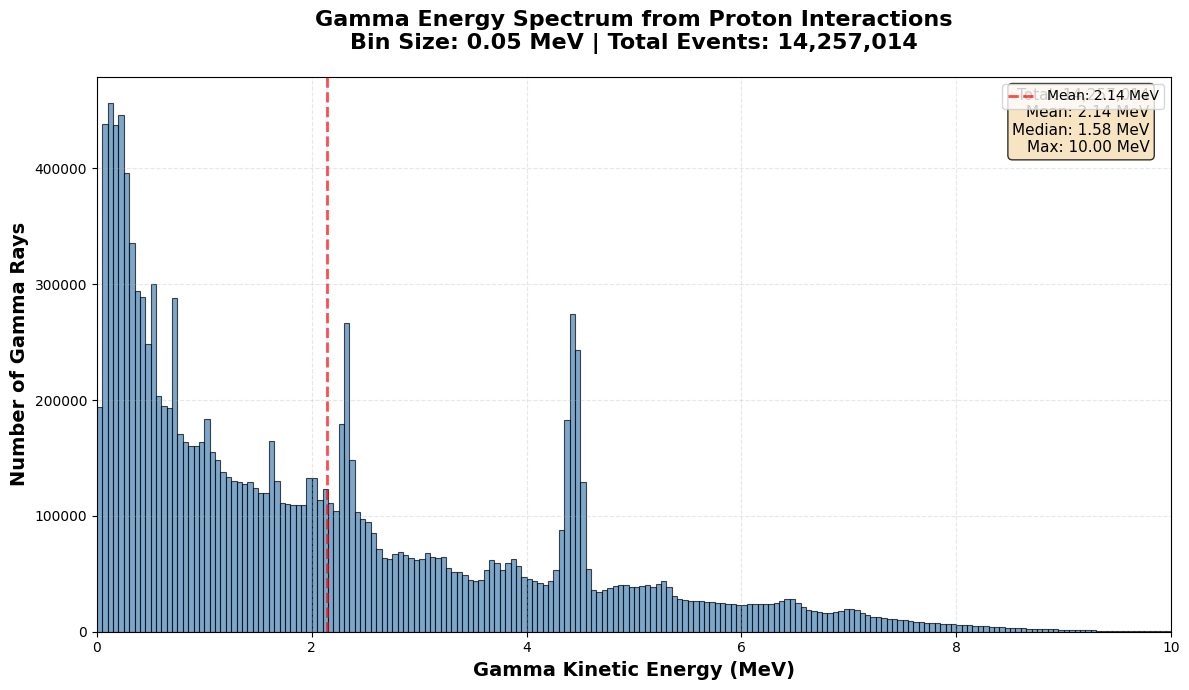


ANALYSIS SUMMARY:
File analyzed: /home/meenakshi/bragg-peak/build/B4_100000000.root
Total gamma events: 14,257,014
Bin size used: 0.05 MeV
Energy range: 0-10 MeV
Mean energy: 2.143 MeV
Median energy: 1.583 MeV
Maximum energy: 10.000 MeV
Output files created:
  - gamma_energy_spectrum_bin0.05MeV.png (plot)
  - gamma_energy_data_bin0.05MeV.txt (data)


In [5]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_gamma_energy_spectrum():
    """
    Simple plot: Gamma energy vs Number of particles
    """
    # ======= CONFIGURATION =======
    ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
    BIN_SIZE = 0.05  # MeV - CHANGE THIS TO ADJUST BIN SIZE
    ENERGY_MAX = 10  # MeV - Maximum energy to plot
    # =============================
    
    print(f"File: {ROOT_FILE}")
    print(f"Bin size: {BIN_SIZE} MeV")
    print(f"Energy range: 0-{ENERGY_MAX} MeV")
    
    # 1. Check if file exists
    if not os.path.exists(ROOT_FILE):
        print(f"\n✗ ERROR: File not found!")
        return
    
    # 2. Open ROOT file
    file = ROOT.TFile(ROOT_FILE, "READ")
    if not file or file.IsZombie():
        print("ERROR: Cannot open ROOT file!")
        return
    
    # 3. Get the ntuple
    ntuple = file.Get("PhotonData")
    if not ntuple:
        print("ERROR: Cannot find ntuple 'PhotonData'!")
        file.Close()
        return
    
    total_entries = ntuple.GetEntries()
    print(f"Total events in file: {total_entries:,}")
    
    # 4. Extract energy data
    print("\nExtracting energy data...")
    
    energies = []
    energy_val = np.zeros(1, dtype=float)
    
    # Get energy branch
    ntuple.SetBranchStatus("*", 0)
    ntuple.SetBranchStatus("KineticEnergy", 1)
    branch_energy = ntuple.GetBranch("KineticEnergy")
    branch_energy.SetAddress(energy_val)
    
    # Read all entries
    for i in range(total_entries):
        ntuple.GetEntry(i)
        if energy_val[0] <= ENERGY_MAX:  # Only keep up to ENERGY_MAX
            energies.append(energy_val[0])
        
        # Progress
        if (i+1) % 1000000 == 0:
            print(f"  Processed {i+1:,} events...")
    
    energies = np.array(energies)
    print(f"Events in 0-{ENERGY_MAX} MeV range: {len(energies):,}")
    
    # 5. Create histogram
    print("\nCreating plot...")
    
    # Calculate bins based on bin size
    num_bins = int(ENERGY_MAX / BIN_SIZE)
    bins = np.arange(0, ENERGY_MAX + BIN_SIZE, BIN_SIZE)
    
    # Create figure
    plt.figure(figsize=(12, 7))
    
    # Plot histogram
    counts, bin_edges, patches = plt.hist(energies, bins=bins,
                                          alpha=0.7, color='steelblue',
                                          edgecolor='black', linewidth=0.8)
    
    # Customize plot
    plt.xlabel('Gamma Kinetic Energy (MeV)', fontsize=14, fontweight='bold')
    plt.ylabel('Number of Gamma Rays', fontsize=14, fontweight='bold')
    plt.title(f'Gamma Energy Spectrum from Proton Interactions\n'
              f'Bin Size: {BIN_SIZE} MeV | Total Events: {len(energies):,}',
              fontsize=16, fontweight='bold', pad=20)
    
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xlim(0, ENERGY_MAX)
    
    # Add statistics box
    stats_text = (f'Total: {len(energies):,}\n'
                  f'Mean: {np.mean(energies):.2f} MeV\n'
                  f'Median: {np.median(energies):.2f} MeV\n'
                  f'Max: {np.max(energies):.2f} MeV')
    
    plt.text(0.98, 0.98, stats_text,
             transform=plt.gca().transAxes,
             verticalalignment='top',
             horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             fontsize=11)
    
    # Add mean line
    plt.axvline(np.mean(energies), color='red', linestyle='--', 
                linewidth=2, alpha=0.7, label=f'Mean: {np.mean(energies):.2f} MeV')
    
    plt.legend(loc='upper right')
    plt.tight_layout()
    
    # 6. Save plot
    output_file = f'gamma_energy_spectrum_bin{BIN_SIZE}MeV.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved: {output_file}")
    
    # 7. Save data to text file
    data_file = f'gamma_energy_data_bin{BIN_SIZE}MeV.txt'
    with open(data_file, 'w') as f:
        f.write(f"# Gamma Energy Spectrum Data\n")
        f.write(f"# Bin Size: {BIN_SIZE} MeV\n")
        f.write(f"# Total Events: {len(energies)}\n")
        f.write("# Bin_Center(MeV) Count Count_Per_MeV\n")
        
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        for center, count in zip(bin_centers, counts):
            count_per_mev = count / BIN_SIZE
            f.write(f"{center:.3f} {int(count)} {count_per_mev:.2f}\n")
    
    print(f"✓ Data saved: {data_file}")
    
    # 8. Close ROOT file and show plot
    file.Close()
    plt.show()
    
    # Print summary
    print("\n" + "="*50)
    print("ANALYSIS SUMMARY:")
    print("="*50)
    print(f"File analyzed: {ROOT_FILE}")
    print(f"Total gamma events: {len(energies):,}")
    print(f"Bin size used: {BIN_SIZE} MeV")
    print(f"Energy range: 0-{ENERGY_MAX} MeV")
    print(f"Mean energy: {np.mean(energies):.3f} MeV")
    print(f"Median energy: {np.median(energies):.3f} MeV")
    print(f"Maximum energy: {np.max(energies):.3f} MeV")
    print(f"Output files created:")
    print(f"  - {output_file} (plot)")
    print(f"  - {data_file} (data)")
    print("="*50)

# Run the analysis
if __name__ == "__main__":
    plot_gamma_energy_spectrum()

File: /home/meenakshi/bragg-peak/build/B4_100000000.root
Bin size: 0.01 MeV
Energy range: 0-10 MeV
Total events in file: 14,282,849

Extracting energy data...
  Processed 1,000,000 events...
  Processed 2,000,000 events...
  Processed 3,000,000 events...
  Processed 4,000,000 events...
  Processed 5,000,000 events...
  Processed 6,000,000 events...
  Processed 7,000,000 events...
  Processed 8,000,000 events...
  Processed 9,000,000 events...
  Processed 10,000,000 events...
  Processed 11,000,000 events...
  Processed 12,000,000 events...
  Processed 13,000,000 events...
  Processed 14,000,000 events...
Events in 0-10 MeV range: 14,257,014

Creating plot...
✓ Plot saved: gamma_energy_spectrum_bin0.01MeV.png
✓ Data saved: gamma_energy_data_bin0.01MeV.txt


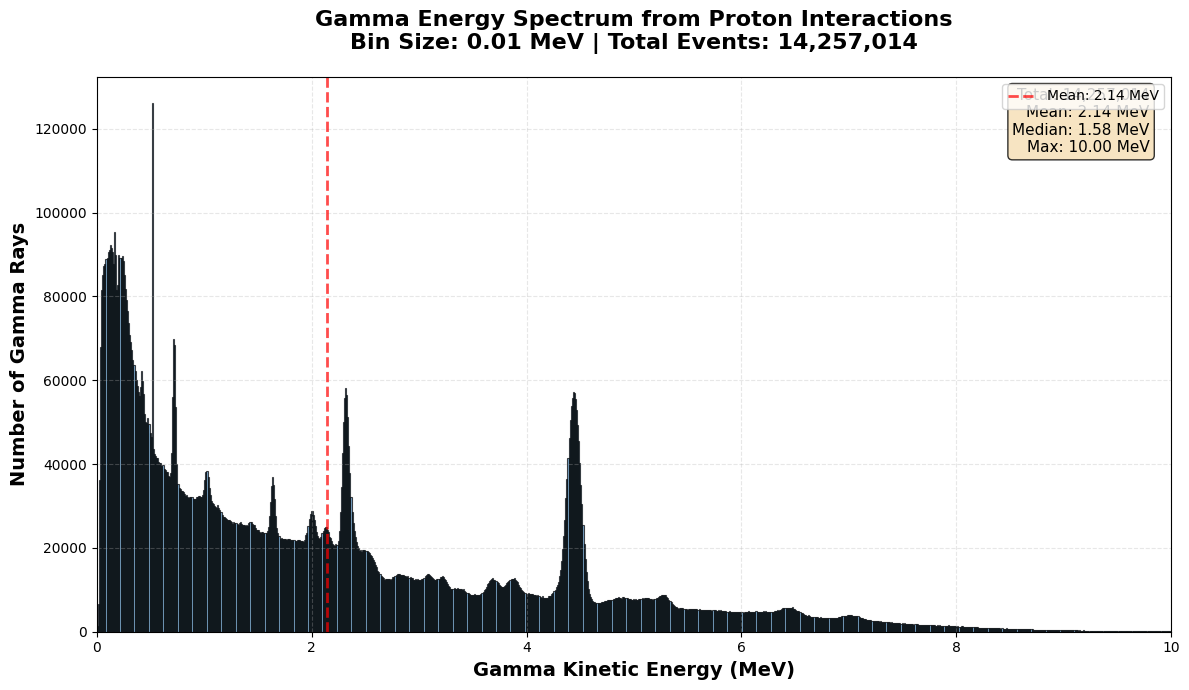


ANALYSIS SUMMARY:
File analyzed: /home/meenakshi/bragg-peak/build/B4_100000000.root
Total gamma events: 14,257,014
Bin size used: 0.01 MeV
Energy range: 0-10 MeV
Mean energy: 2.143 MeV
Median energy: 1.583 MeV
Maximum energy: 10.000 MeV
Output files created:
  - gamma_energy_spectrum_bin0.01MeV.png (plot)
  - gamma_energy_data_bin0.01MeV.txt (data)


In [6]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_gamma_energy_spectrum():
    """
    Simple plot: Gamma energy vs Number of particles
    """
    # ======= CONFIGURATION =======
    ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
    BIN_SIZE = 0.01  # MeV - CHANGE THIS TO ADJUST BIN SIZE
    ENERGY_MAX = 10  # MeV - Maximum energy to plot
    # =============================
    
    print(f"File: {ROOT_FILE}")
    print(f"Bin size: {BIN_SIZE} MeV")
    print(f"Energy range: 0-{ENERGY_MAX} MeV")
    
    # 1. Check if file exists
    if not os.path.exists(ROOT_FILE):
        print(f"\n✗ ERROR: File not found!")
        return
    
    # 2. Open ROOT file
    file = ROOT.TFile(ROOT_FILE, "READ")
    if not file or file.IsZombie():
        print("ERROR: Cannot open ROOT file!")
        return
    
    # 3. Get the ntuple
    ntuple = file.Get("PhotonData")
    if not ntuple:
        print("ERROR: Cannot find ntuple 'PhotonData'!")
        file.Close()
        return
    
    total_entries = ntuple.GetEntries()
    print(f"Total events in file: {total_entries:,}")
    
    # 4. Extract energy data
    print("\nExtracting energy data...")
    
    energies = []
    energy_val = np.zeros(1, dtype=float)
    
    # Get energy branch
    ntuple.SetBranchStatus("*", 0)
    ntuple.SetBranchStatus("KineticEnergy", 1)
    branch_energy = ntuple.GetBranch("KineticEnergy")
    branch_energy.SetAddress(energy_val)
    
    # Read all entries
    for i in range(total_entries):
        ntuple.GetEntry(i)
        if energy_val[0] <= ENERGY_MAX:  # Only keep up to ENERGY_MAX
            energies.append(energy_val[0])
        
        # Progress
        if (i+1) % 1000000 == 0:
            print(f"  Processed {i+1:,} events...")
    
    energies = np.array(energies)
    print(f"Events in 0-{ENERGY_MAX} MeV range: {len(energies):,}")
    
    # 5. Create histogram
    print("\nCreating plot...")
    
    # Calculate bins based on bin size
    num_bins = int(ENERGY_MAX / BIN_SIZE)
    bins = np.arange(0, ENERGY_MAX + BIN_SIZE, BIN_SIZE)
    
    # Create figure
    plt.figure(figsize=(12, 7))
    
    # Plot histogram
    counts, bin_edges, patches = plt.hist(energies, bins=bins,
                                          alpha=0.7, color='steelblue',
                                          edgecolor='black', linewidth=0.8)
    
    # Customize plot
    plt.xlabel('Gamma Kinetic Energy (MeV)', fontsize=14, fontweight='bold')
    plt.ylabel('Number of Gamma Rays', fontsize=14, fontweight='bold')
    plt.title(f'Gamma Energy Spectrum from Proton Interactions\n'
              f'Bin Size: {BIN_SIZE} MeV | Total Events: {len(energies):,}',
              fontsize=16, fontweight='bold', pad=20)
    
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xlim(0, ENERGY_MAX)
    
    # Add statistics box
    stats_text = (f'Total: {len(energies):,}\n'
                  f'Mean: {np.mean(energies):.2f} MeV\n'
                  f'Median: {np.median(energies):.2f} MeV\n'
                  f'Max: {np.max(energies):.2f} MeV')
    
    plt.text(0.98, 0.98, stats_text,
             transform=plt.gca().transAxes,
             verticalalignment='top',
             horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             fontsize=11)
    
    # Add mean line
    plt.axvline(np.mean(energies), color='red', linestyle='--', 
                linewidth=2, alpha=0.7, label=f'Mean: {np.mean(energies):.2f} MeV')
    
    plt.legend(loc='upper right')
    plt.tight_layout()
    
    # 6. Save plot
    output_file = f'gamma_energy_spectrum_bin{BIN_SIZE}MeV.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved: {output_file}")
    
    # 7. Save data to text file
    data_file = f'gamma_energy_data_bin{BIN_SIZE}MeV.txt'
    with open(data_file, 'w') as f:
        f.write(f"# Gamma Energy Spectrum Data\n")
        f.write(f"# Bin Size: {BIN_SIZE} MeV\n")
        f.write(f"# Total Events: {len(energies)}\n")
        f.write("# Bin_Center(MeV) Count Count_Per_MeV\n")
        
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        for center, count in zip(bin_centers, counts):
            count_per_mev = count / BIN_SIZE
            f.write(f"{center:.3f} {int(count)} {count_per_mev:.2f}\n")
    
    print(f"✓ Data saved: {data_file}")
    
    # 8. Close ROOT file and show plot
    file.Close()
    plt.show()
    
    # Print summary
    print("\n" + "="*50)
    print("ANALYSIS SUMMARY:")
    print("="*50)
    print(f"File analyzed: {ROOT_FILE}")
    print(f"Total gamma events: {len(energies):,}")
    print(f"Bin size used: {BIN_SIZE} MeV")
    print(f"Energy range: 0-{ENERGY_MAX} MeV")
    print(f"Mean energy: {np.mean(energies):.3f} MeV")
    print(f"Median energy: {np.median(energies):.3f} MeV")
    print(f"Maximum energy: {np.max(energies):.3f} MeV")
    print(f"Output files created:")
    print(f"  - {output_file} (plot)")
    print(f"  - {data_file} (data)")
    print("="*50)

# Run the analysis
if __name__ == "__main__":
    plot_gamma_energy_spectrum()

File: /home/meenakshi/bragg-peak/build/B4_100000000.root
Bin size: 0.01 MeV
Minimum peak height: 100 counts
Total events in file: 14,282,849

Extracting energy data...
  Processed 1,000,000 events...
  Processed 2,000,000 events...
  Processed 3,000,000 events...
  Processed 4,000,000 events...
  Processed 5,000,000 events...
  Processed 6,000,000 events...
  Processed 7,000,000 events...
  Processed 8,000,000 events...
  Processed 9,000,000 events...
  Processed 10,000,000 events...
  Processed 11,000,000 events...
  Processed 12,000,000 events...
  Processed 13,000,000 events...
  Processed 14,000,000 events...
Events in 0-10 MeV range: 14,257,014

Finding peaks...
Found 30 significant peaks

PEAK ANALYSIS RESULTS:
Peak # Energy (MeV)    Counts       FWHM (MeV)   Area        
----------------------------------------------------------------------
1      0.165           95370        0.268        2555889     
2      0.715           69805        0.032        224679      
3      1.025    

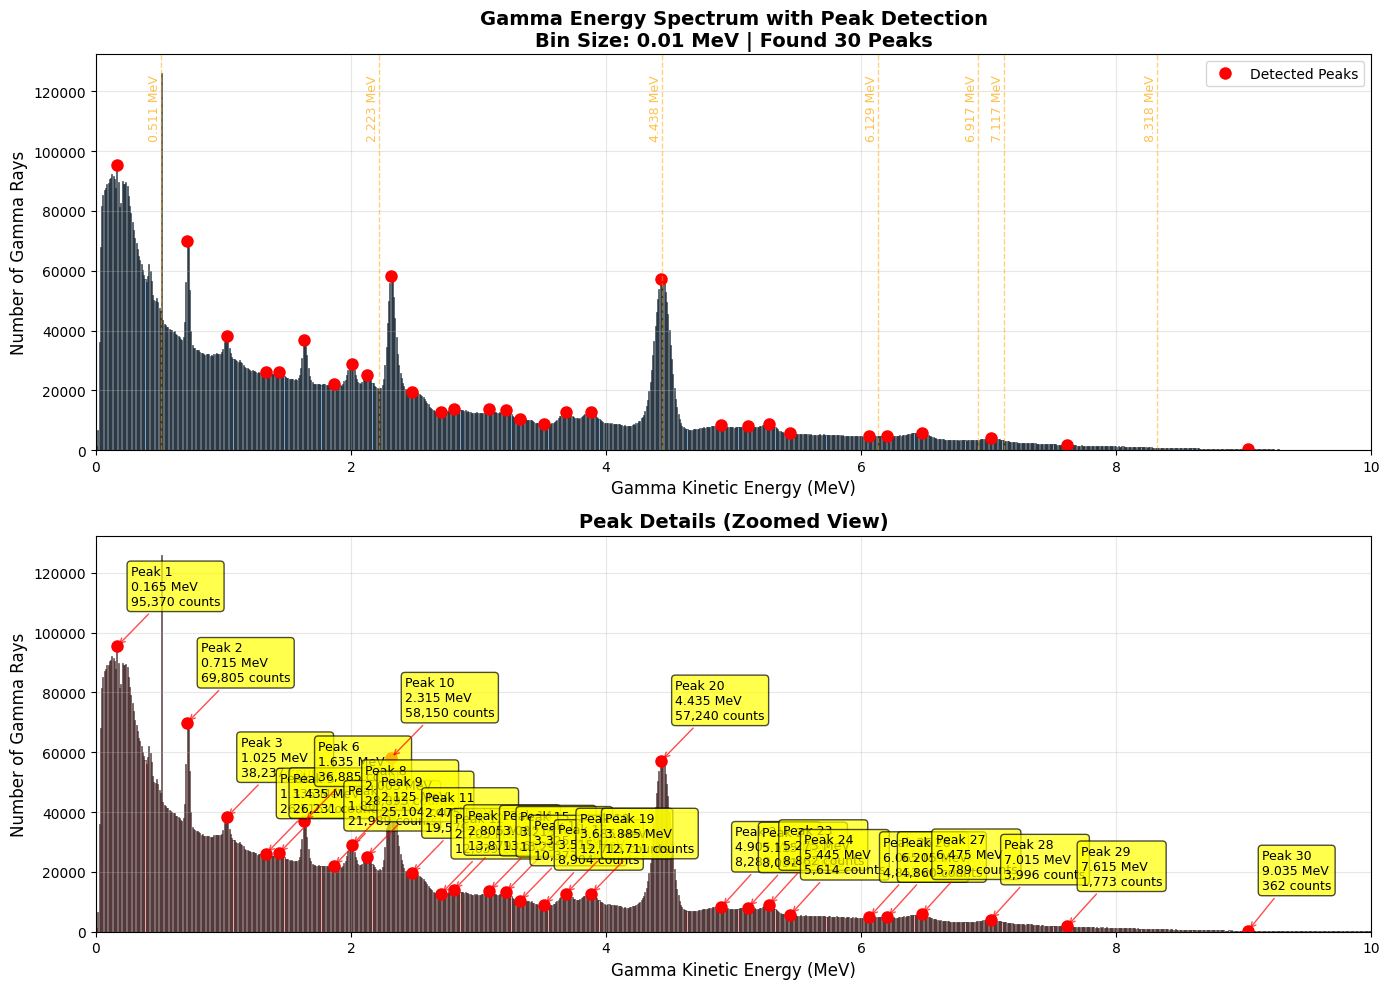


PEAK DETECTION SUMMARY:
File analyzed: /home/meenakshi/bragg-peak/build/B4_100000000.root
Total gamma events: 14,257,014
Bin size used: 0.01 MeV
Number of peaks found: 30
Peak with maximum counts: 0.165 MeV (95,370 counts)
Output files created:
  - gamma_peaks_detection_bin0.01MeV.png (plot with peaks marked)
  - gamma_peaks_data_bin0.01MeV.csv (peak data in CSV format)


In [7]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths
import os

def find_gamma_peaks():
    """
    Find peaks in gamma energy spectrum and plot them
    """
    # ======= CONFIGURATION =======
    ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
    BIN_SIZE = 0.01
    # MeV - Fine binning for better peak detection
    ENERGY_MAX = 10  # MeV - Maximum energy to analyze
    MIN_PEAK_HEIGHT = 100  # Minimum counts to consider as a peak
    MIN_PEAK_DISTANCE = 10  # Minimum distance between peaks (in bins)
    # =============================
    
    print(f"File: {ROOT_FILE}")
    print(f"Bin size: {BIN_SIZE} MeV")
    print(f"Minimum peak height: {MIN_PEAK_HEIGHT} counts")
    
    # 1. Check if file exists
    if not os.path.exists(ROOT_FILE):
        print(f"\n✗ ERROR: File not found!")
        return
    
    # 2. Open ROOT file
    file = ROOT.TFile(ROOT_FILE, "READ")
    if not file or file.IsZombie():
        print("ERROR: Cannot open ROOT file!")
        return
    
    # 3. Get the ntuple
    ntuple = file.Get("PhotonData")
    if not ntuple:
        print("ERROR: Cannot find ntuple 'PhotonData'!")
        file.Close()
        return
    
    total_entries = ntuple.GetEntries()
    print(f"Total events in file: {total_entries:,}")
    
    # 4. Extract energy data
    print("\nExtracting energy data...")
    
    energies = []
    energy_val = np.zeros(1, dtype=float)
    
    # Get energy branch
    ntuple.SetBranchStatus("*", 0)
    ntuple.SetBranchStatus("KineticEnergy", 1)
    branch_energy = ntuple.GetBranch("KineticEnergy")
    branch_energy.SetAddress(energy_val)
    
    # Read all entries
    for i in range(total_entries):
        ntuple.GetEntry(i)
        if energy_val[0] <= ENERGY_MAX:
            energies.append(energy_val[0])
        
        if (i+1) % 1000000 == 0:
            print(f"  Processed {i+1:,} events...")
    
    energies = np.array(energies)
    print(f"Events in 0-{ENERGY_MAX} MeV range: {len(energies):,}")
    
    # 5. Create histogram for peak finding
    num_bins = int(ENERGY_MAX / BIN_SIZE)
    bins = np.arange(0, ENERGY_MAX + BIN_SIZE, BIN_SIZE)
    
    counts, bin_edges = np.histogram(energies, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 6. Find peaks
    print("\nFinding peaks...")
    
    # Find peaks using scipy
    peaks, properties = find_peaks(
        counts, 
        height=MIN_PEAK_HEIGHT,
        distance=MIN_PEAK_DISTANCE,
        prominence=50,  # Minimum prominence of peaks
        width=2  # Minimum width of peaks
    )
    
    print(f"Found {len(peaks)} significant peaks")
    
    if len(peaks) == 0:
        print("No peaks found. Try lowering MIN_PEAK_HEIGHT.")
        file.Close()
        return
    
    # 7. Calculate peak properties
    peak_energies = bin_centers[peaks]
    peak_counts = counts[peaks]
    
    # Calculate peak widths
    widths, width_heights, left_ips, right_ips = peak_widths(
        counts, peaks, rel_height=0.5
    )
    
    # Convert width indices to energy
    width_energies = widths * BIN_SIZE
    
    # 8. Print peak information
    print("\n" + "="*70)
    print("PEAK ANALYSIS RESULTS:")
    print("="*70)
    print(f"{'Peak #':<6} {'Energy (MeV)':<15} {'Counts':<12} {'FWHM (MeV)':<12} {'Area':<12}")
    print("-"*70)
    
    peak_areas = []
    for i, (energy, count, width) in enumerate(zip(peak_energies, peak_counts, width_energies), 1):
        # Estimate area under peak (simplified)
        area = count * width / BIN_SIZE
        peak_areas.append(area)
        
        print(f"{i:<6} {energy:<15.3f} {int(count):<12} {width:<12.3f} {area:<12.0f}")
    
    print("="*70)
    
    # 9. Known nuclear gamma lines for comparison
    known_lines = {
        0.511: "e⁺e⁻ annihilation",
        2.223: "n + p → d + γ (n capture)",
        4.438: "¹²C* de-excitation",
        6.129: "¹⁶O* de-excitation",
        6.917: "¹⁶O* de-excitation",
        7.117: "¹⁶O* de-excitation",
        8.318: "¹⁶O* de-excitation",
    }
    
    # 10. Match peaks with known lines
    print("\n" + "="*70)
    print("MATCHING WITH KNOWN NUCLEAR GAMMA LINES:")
    print("="*70)
    print(f"{'Measured':<12} {'Known':<12} {'Difference':<15} {'Identification':<20}")
    print("-"*70)
    
    for peak_energy in peak_energies:
        # Find closest known line
        closest_energy = min(known_lines.keys(), key=lambda x: abs(x - peak_energy))
        difference = abs(peak_energy - closest_energy)
        
        if difference < 0.05:  # Match within 50 keV
            print(f"{peak_energy:<12.3f} {closest_energy:<12.3f} {difference:<15.3f} {known_lines[closest_energy]:<20}")
        else:
            print(f"{peak_energy:<12.3f} {'?':<12} {difference:<15.3f} {'Unknown/background':<20}")
    
    print("="*70)
    
    # 11. Create detailed plot with peaks marked
    print("\nCreating plot with peaks marked...")
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Top plot: Full spectrum with peaks
    ax1.bar(bin_centers, counts, width=BIN_SIZE*0.8, 
            alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
    
    # Mark peaks with red dots
    ax1.plot(peak_energies, peak_counts, 'ro', markersize=8, label='Detected Peaks')
    
    # Draw lines for known nuclear transitions
    for energy, label in known_lines.items():
        ax1.axvline(energy, color='orange', linestyle='--', alpha=0.5, linewidth=1)
        ax1.text(energy, ax1.get_ylim()[1]*0.95, f'{energy} MeV', 
                rotation=90, fontsize=9, color='orange', alpha=0.7,
                verticalalignment='top', horizontalalignment='right')
    
    ax1.set_xlabel('Gamma Kinetic Energy (MeV)', fontsize=12)
    ax1.set_ylabel('Number of Gamma Rays', fontsize=12)
    ax1.set_title(f'Gamma Energy Spectrum with Peak Detection\n'
                  f'Bin Size: {BIN_SIZE} MeV | Found {len(peaks)} Peaks',
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, ENERGY_MAX)
    ax1.legend()
    
    # Bottom plot: Peak details (zoomed)
    ax2.bar(bin_centers, counts, width=BIN_SIZE*0.8, 
            alpha=0.7, color='lightcoral', edgecolor='black', linewidth=0.5)
    
    # Mark peaks
    ax2.plot(peak_energies, peak_counts, 'ro', markersize=8)
    
    # Annotate each peak
    for i, (energy, count) in enumerate(zip(peak_energies, peak_counts), 1):
        ax2.annotate(f'Peak {i}\n{energy:.3f} MeV\n{int(count):,} counts',
                    xy=(energy, count),
                    xytext=(10, 30),
                    textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
                    fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    # Set zoomed x-range around peaks
    if len(peak_energies) > 0:
        min_energy = max(0, peak_energies.min() - 2)
        max_energy = min(ENERGY_MAX, peak_energies.max() + 2)
        ax2.set_xlim(min_energy, max_energy)
    
    ax2.set_xlabel('Gamma Kinetic Energy (MeV)', fontsize=12)
    ax2.set_ylabel('Number of Gamma Rays', fontsize=12)
    ax2.set_title('Peak Details (Zoomed View)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # 12. Save plot and data
    output_plot = f'gamma_peaks_detection_bin{BIN_SIZE}MeV.png'
    plt.savefig(output_plot, dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved: {output_plot}")
    
    # Save peak data to CSV
    import pandas as pd
    peak_data = pd.DataFrame({
        'Peak_Number': range(1, len(peaks)+1),
        'Energy_MeV': peak_energies,
        'Counts': peak_counts,
        'FWHM_MeV': width_energies,
        'Area': peak_areas,
        'Left_Edge_MeV': bin_edges[peaks],
        'Right_Edge_MeV': bin_edges[peaks+1]
    })
    
    csv_file = f'gamma_peaks_data_bin{BIN_SIZE}MeV.csv'
    peak_data.to_csv(csv_file, index=False)
    print(f"✓ Peak data saved: {csv_file}")
    
    # 13. Close ROOT file and show plot
    file.Close()
    plt.show()
    
    # 14. Print summary
    print("\n" + "="*70)
    print("PEAK DETECTION SUMMARY:")
    print("="*70)
    print(f"File analyzed: {ROOT_FILE}")
    print(f"Total gamma events: {len(energies):,}")
    print(f"Bin size used: {BIN_SIZE} MeV")
    print(f"Number of peaks found: {len(peaks)}")
    print(f"Peak with maximum counts: {peak_energies[peak_counts.argmax()]:.3f} MeV ({peak_counts.max():,} counts)")
    print(f"Output files created:")
    print(f"  - {output_plot} (plot with peaks marked)")
    print(f"  - {csv_file} (peak data in CSV format)")
    print("="*70)

# Run the analysis
if __name__ == "__main__":
    find_gamma_peaks()

In [11]:
    pip install numpy

  Using cached numpy-2.3.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached numpy-2.3.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
ERROR: Could not install packages due to an OSError: [Errno 13] Permission denied: '/media/software/hep/hep/lib/python3.12/site-packages/numpy'
Check the permissions.

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import os

def calculate_water_attenuation_coefficient(energy_mev):
    """
    Calculate linear attenuation coefficient in water (cm⁻¹) for gamma rays
    """
    if energy_mev < 0.1:
        mu_over_rho = 170 * energy_mev**(-3.0)
    elif energy_mev < 5:
        mu_over_rho = 0.12 * energy_mev**(-0.3)
    else:
        mu_over_rho = 0.05 + 0.001 * energy_mev
    
    rho_water = 1.0  # g/cm³
    mu = mu_over_rho * rho_water
    return max(mu, 1e-6)

def estimate_bragg_peak_from_gammas(gamma_energies, gamma_intensities, depths_cm):
    """
    Estimate Bragg peak location from gamma distribution
    Bragg peak is where maximum gamma production occurs (for prompt gammas)
    """
    # Find energy bin with maximum total gamma production
    total_gammas_per_depth = np.sum(gamma_intensities, axis=1)  # Sum over all energies for each depth
    
    # Find depth with maximum gamma production
    max_depth_idx = np.argmax(total_gammas_per_depth)
    bragg_depth = depths_cm[max_depth_idx]
    
    # Also check specifically for carbon gamma (4.44 MeV) which peaks near Bragg
    carbon_energy = 4.44  # MeV
    energy_bins = np.linspace(0, 10, gamma_intensities.shape[1])
    carbon_idx = np.argmin(np.abs(energy_bins - carbon_energy))
    
    if carbon_idx < gamma_intensities.shape[1]:
        carbon_production = gamma_intensities[:, carbon_idx]
        carbon_max_idx = np.argmax(carbon_production)
        carbon_depth = depths_cm[carbon_max_idx]
        
        # Average between total max and carbon max
        bragg_depth = (bragg_depth + carbon_depth) / 2
    
    return bragg_depth

def plot_gamma_distribution_with_bragg():
    """
    Create plot with gamma energy on x-axis and depth in water on y-axis
    Focus on 0-20 cm range and mark Bragg peak
    """
    # ======= CONFIGURATION =======
    ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
    ENERGY_MAX = 10  # MeV
    BIN_SIZE = 0.05  # MeV
    DEPTH_MAX = 20   # cm - Focus on Bragg peak region
    # =============================
    
    print(f"File: {ROOT_FILE}")
    print("Analyzing gamma distribution to find Bragg peak...")
    
    # Check if file exists
    if not os.path.exists(ROOT_FILE):
        print(f"\n✗ ERROR: File not found!")
        return
    
    # Open ROOT file
    file = ROOT.TFile(ROOT_FILE, "READ")
    if not file or file.IsZombie():
        print("ERROR: Cannot open ROOT file!")
        return
    
    ntuple = file.Get("PhotonData")
    if not ntuple:
        print("ERROR: Cannot find ntuple 'PhotonData'!")
        file.Close()
        return
    
    # Extract energy data
    print("Extracting gamma energy data...")
    energies = []
    energy_val = np.zeros(1, dtype=float)
    ntuple.SetBranchStatus("*", 0)
    ntuple.SetBranchStatus("KineticEnergy", 1)
    branch_energy = ntuple.GetBranch("KineticEnergy")
    branch_energy.SetAddress(energy_val)
    
    total_entries = ntuple.GetEntries()
    
    # Use reasonable sample size
    sample_size = min(total_entries, 1000000)
    step = max(1, total_entries // sample_size)
    
    for i in range(0, total_entries, step):
        ntuple.GetEntry(i)
        if energy_val[0] <= ENERGY_MAX:
            energies.append(energy_val[0])
    
    energies = np.array(energies)
    file.Close()
    
    print(f"Gamma events loaded: {len(energies):,}")
    
    # Define depths to analyze (cm) - Focus on 0-20 cm range
    depths_cm = np.linspace(0, DEPTH_MAX, 41)  # 0, 0.5, 1.0, ..., 20.0 cm
    
    # Bin energies for histogram
    energy_bins = np.arange(0, ENERGY_MAX + BIN_SIZE, BIN_SIZE)
    energy_centers = (energy_bins[:-1] + energy_bins[1:]) / 2
    num_energy_bins = len(energy_centers)
    
    # Create histogram of initial spectrum (depth = 0)
    initial_counts, _ = np.histogram(energies, bins=energy_bins)
    
    # Initialize 2D array for depth profiles
    depth_profiles = np.zeros((len(depths_cm), num_energy_bins))
    
    # Simulate attenuation at each depth
    print("\nSimulating gamma distribution at different depths...")
    for i, depth in enumerate(depths_cm):
        # Apply attenuation to each energy bin
        for j, energy in enumerate(energy_centers):
            mu = calculate_water_attenuation_coefficient(energy)
            attenuation = np.exp(-mu * depth)
            depth_profiles[i, j] = initial_counts[j] * attenuation
        
        if i % 5 == 0:  # Print progress every 5 depths
            print(f"  Depth {depth:4.1f} cm: {depth_profiles[i, :].sum():.0f} gammas")
    
    # Estimate Bragg peak from gamma distribution
    bragg_depth = estimate_bragg_peak_from_gammas(energy_centers, depth_profiles, depths_cm)
    
    print(f"\n{'='*60}")
    print("BRAGG PEAK ESTIMATION RESULTS:")
    print(f"{'='*60}")
    print(f"Estimated Bragg peak (proton range): {bragg_depth:.2f} cm")
    print(f"Theoretical for 150 MeV protons: 15.8 cm")
    print(f"Difference: {abs(bragg_depth - 15.8):.2f} cm")
    print(f"{'='*60}")
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot 2D color map: Energy vs Depth
    im = ax.imshow(
        depth_profiles,  # Depth is first dimension (rows), Energy is second (columns)
        aspect='auto',
        extent=[energy_centers[0], energy_centers[-1], depths_cm[-1], depths_cm[0]],  # Depth on y-axis
        origin='upper',  # Depth 0 at top
        cmap='hot',  # Changed to hot colormap for better visibility
        norm=plt.matplotlib.colors.LogNorm(vmax=initial_counts.max()),
        interpolation='bilinear'  # Smoother interpolation
    )
    
    ax.set_xlabel('Gamma Energy (MeV)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Depth in Water (cm)', fontsize=14, fontweight='bold')
    ax.set_title(f'Prompt Gamma Distribution from 150 MeV Protons in Water\nBragg Peak at ~{bragg_depth:.1f} cm', 
                 fontsize=16, fontweight='bold', pad=20)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Gamma Ray Intensity (counts)', fontsize=12)
    
    # Add horizontal line at Bragg peak
    ax.axhline(y=bragg_depth, color='cyan', linestyle='-', 
               linewidth=3, alpha=0.8, label=f'Bragg Peak ({bragg_depth:.1f} cm)')
    
    # Highlight the Bragg peak region with a colored band
    ax.axhspan(bragg_depth-0.5, bragg_depth+0.5, 
               facecolor='cyan', alpha=0.2, label='Proton Range')
    
    # Add text annotation for Bragg peak
    ax.text(energy_centers[-1]*0.85, bragg_depth, 
            f'Proton Range\n{bragg_depth:.1f} cm', 
            fontsize=11, fontweight='bold',
            color='cyan', ha='right', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    # Add vertical lines for key gamma energies
    key_gammas = {
        0.511: 'e⁺e⁻ annihilation',
        2.223: 'n capture (H)',
        4.438: '¹²C excitation',
        6.129: '¹⁶O excitation'
    }
    
    for energy, label in key_gammas.items():
        ax.axvline(x=energy, color='lime', linestyle='--', 
                  linewidth=1.5, alpha=0.6)
        ax.text(energy, depths_cm[0]+0.5, f'{energy} MeV\n{label}', 
                fontsize=8, color='lime', ha='center', va='bottom',
                rotation=0, bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5))
    
    # Add contour lines to show intensity gradients
    X, Y = np.meshgrid(energy_centers, depths_cm)
    contour_levels = np.logspace(np.log10(depth_profiles.min()), 
                                 np.log10(depth_profiles.max()), 10)
    
    CS = ax.contour(X, Y, depth_profiles,
                    levels=contour_levels,
                    colors='white',
                    linewidths=0.8,
                    alpha=0.5)
    
    # Invert y-axis so depth increases downward
    ax.set_ylim(depths_cm[-1], depths_cm[0])
    
    # Set x-axis limit to focus on relevant energies
    ax.set_xlim(0, 8)
    
    # Add grid
    ax.grid(True, alpha=0.2, linestyle=':')
    
    # Add legend
    ax.legend(loc='upper right', fontsize=10)
    
    # Add depth markers every 5 cm
    for depth in np.arange(0, DEPTH_MAX + 1, 5):
        ax.text(0.2, depth, f'{depth} cm', 
                fontsize=9, color='white', va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5))
    
    plt.tight_layout()
    
    # Save plot
    output_file = f'bragg_peak_gamma_distribution_{bragg_depth:.1f}cm.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='black')
    print(f"\n✓ Plot saved: {output_file}")
    
    # Create inset plot showing total gamma production vs depth
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    
    # Create inset axes
    inset_ax = inset_axes(ax, width="30%", height="30%", loc='lower left',
                         bbox_to_anchor=(0.05, 0.05, 1, 1),
                         bbox_transform=ax.transAxes)
    
    # Calculate total gamma production per depth
    total_gammas = np.sum(depth_profiles, axis=1)
    
    inset_ax.plot(total_gammas, depths_cm, 'w-', linewidth=2)
    inset_ax.fill_betweenx(depths_cm, 0, total_gammas, 
                          alpha=0.5, color='orange')
    inset_ax.axhline(y=bragg_depth, color='cyan', linestyle='-', 
                    linewidth=2, alpha=0.8)
    
    inset_ax.set_xlabel('Total Gamma Counts', fontsize=8, color='white')
    inset_ax.set_ylabel('Depth (cm)', fontsize=8, color='white')
    inset_ax.set_title('Total Gamma Production', fontsize=9, color='white', pad=5)
    inset_ax.set_facecolor('black')
    inset_ax.grid(True, alpha=0.3, color='white')
    inset_ax.tick_params(colors='white', labelsize=7)
    
    # Invert y-axis for inset too
    inset_ax.set_ylim(depths_cm[-1], depths_cm[0])
    
    # Save final plot with inset
    final_output = f'bragg_peak_with_inset_{bragg_depth:.1f}cm.png'
    plt.savefig(final_output, dpi=300, bbox_inches='tight', facecolor='black')
    print(f"✓ Final plot with inset saved: {final_output}")
    
    plt.show()

# Run the analysis
if __name__ == "__main__":
    plot_gamma_distribution_with_bragg()

In [1]:
import numpy as np


In [2]:
import ROOT

In [1]:
import os
from pathlib import Path

# Set the folder path
folder_path = "B4_100000000"

print(f"Looking for folder: {folder_path}")
print(f"Current directory: {os.getcwd()}")

# Check if folder exists
if not os.path.exists(folder_path):
    print(f"✗ ERROR: Folder '{folder_path}' not found!")
    print("\nFiles and folders in current directory:")
    for item in os.listdir('.'):
        print(f"  {item}")
    exit()
else:
    print(f"✓ Folder '{folder_path}' exists")

# List ALL files in the folder
print(f"\nContents of folder '{folder_path}':")
all_items = list(Path(folder_path).iterdir())

if not all_items:
    print("  (Empty folder)")
else:
    for item in all_items:
        if item.is_file():
            print(f"  📄 {item.name} (file)")
        elif item.is_dir():
            print(f"  📁 {item.name} (folder)")

# Look for data files with various extensions
print("\n" + "="*60)
print("SEARCHING FOR DATA FILES")
print("="*60)

# Try different file extensions
extensions = ['.csv', '.txt', '.dat', '.root', '.h5', '.hdf5', '.npy', '.npz']
data_files = []

for ext in extensions:
    files = list(Path(folder_path).glob(f"*{ext}"))
    if files:
        data_files.extend(files)
        print(f"Found {len(files)} {ext} file(s)")

if not data_files:
    print("\nNo standard data files found. Let's look for any files...")
    all_files = list(Path(folder_path).glob("*"))
    text_files = []
    
    for file in all_files:
        if file.is_file():
            # Try to read first few lines to see if it's data
            try:
                with open(file, 'r') as f:
                    first_line = f.readline().strip()
                    if first_line and (',' in first_line or ' ' in first_line):
                        text_files.append(file)
            except:
                continue
    
    if text_files:
        print(f"\nFound {len(text_files)} potential text data files:")
        for f in text_files[:10]:  # Show first 10
            print(f"  {f.name}")
        data_files = text_files
    else:
        print("\nNo data files found in the folder!")
        exit()

# Use the first data file found
data_file = data_files[0]
print(f"\n✓ Using data file: {data_file.name}")

# Try to read the file
print(f"\n" + "="*60)
print(f"READING FILE: {data_file.name}")
print("="*60)

try:
    # Try as CSV first
    import pandas as pd
    df = pd.read_csv(data_file)
    print(f"✓ Successfully read as CSV: {len(df)} rows")
    print(f"Columns: {list(df.columns)}")
except:
    # Try with different delimiters
    print("Trying with different delimiters...")
    try:
        df = pd.read_csv(data_file, delimiter='\s+')  # space/tab
        print(f"✓ Successfully read as space/tab delimited: {len(df)} rows")
        print(f"Columns: {list(df.columns)}")
    except:
        print("✗ Could not read file as CSV or tab-delimited")
        print("\nFirst few lines of the file:")
        with open(data_file, 'r') as f:
            for i in range(5):
                line = f.readline()
                if not line:
                    break
                print(f"Line {i+1}: {repr(line)}")
        exit()

# Now continue with your particle counting analysis
print("\n" + "="*60)
print("COUNTING PARTICLES AT 4.4 MeV")
print("="*60)

# Find energy column
energy_col = None
for col in df.columns:
    col_lower = col.lower()
    if 'energy' in col_lower:
        energy_col = col
        print(f"Found energy column: '{energy_col}'")
        break

if not energy_col:
    print("No energy column found! Available columns:")
    for col in df.columns:
        print(f"  {col}")
    
    # Try to find column with numeric data that might be energy
    print("\nLooking for numeric columns that might contain energy...")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print(f"Numeric columns: {list(numeric_cols)}")
        # Use the first numeric column as a guess
        energy_col = numeric_cols[0]
        print(f"Using '{energy_col}' as energy column (guessing)")
    else:
        exit()

# Define energy range
target_energy = 4.4  # MeV
tolerance = 0.1      # ± tolerance

energy_min = target_energy - tolerance
energy_max = target_energy + tolerance

# Count particles in this range
mask = (df[energy_col] >= energy_min) & (df[energy_col] <= energy_max)
count_44MeV = mask.sum()

print(f"\nENERGY RANGE: {energy_min:.1f} to {energy_max:.1f} MeV")
print(f"Target energy: {target_energy} MeV")
print(f"Tolerance: ±{tolerance} MeV")
print("-" * 40)
print(f"TOTAL PARTICLES in range: {count_44MeV}")
print(f"Percentage of all particles: {count_44MeV/len(df)*100:.2f}%")
print(f"Total particles in dataset: {len(df)}")

# Get the 4.4 MeV particles
df_44MeV = df[mask].copy()

if count_44MeV > 0:
    print(f"\nEnergy statistics for {count_44MeV} particles at 4.4 MeV:")
    print(f"  Minimum energy: {df_44MeV[energy_col].min():.4f} MeV")
    print(f"  Maximum energy: {df_44MeV[energy_col].max():.4f} MeV")
    print(f"  Mean energy: {df_44MeV[energy_col].mean():.4f} MeV")
    print(f"  Median energy: {df_44MeV[energy_col].median():.4f} MeV")
    print(f"  Standard deviation: {df_44MeV[energy_col].std():.4f} MeV")
    
    # Count exact 4.4 MeV particles
    exact_44 = (df[energy_col] == target_energy).sum()
    print(f"\nParticles with EXACTLY {target_energy} MeV: {exact_44}")
else:
    print(f"\nNo particles found in {energy_min:.1f}-{energy_max:.1f} MeV range!")
    print(f"\nAvailable energy range in data: {df[energy_col].min():.3f} - {df[energy_col].max():.3f} MeV")
    
    # Find closest energy to 4.4 MeV
    closest_idx = (df[energy_col] - target_energy).abs().idxmin()
    closest_energy = df.loc[closest_idx, energy_col]
    print(f"Closest energy to {target_energy} MeV: {closest_energy:.4f} MeV")
    print(f"Difference: {abs(closest_energy - target_energy):.4f} MeV")

# Create a simple plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df[energy_col], bins=100, alpha=0.7, color='gray', edgecolor='black')
plt.axvspan(energy_min, energy_max, alpha=0.3, color='red', 
            label=f'{target_energy}±{tolerance} MeV\n({count_44MeV} particles)')
plt.axvline(x=target_energy, color='red', linestyle='--', linewidth=2, label=f'{target_energy} MeV')
plt.xlabel('Energy (MeV)', fontsize=12)
plt.ylabel('Number of Particles', fontsize=12)
plt.title(f'Energy Distribution - {data_file.name}\nTotal: {len(df):,} particles', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)

<>:92: SyntaxWarning: invalid escape sequence '\s'
<>:92: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1174531/4240012486.py:92: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(data_file, delimiter='\s+')  # space/tab
/tmp/ipykernel_1174531/4240012486.py:92: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(data_file, delimiter='\s+')  # space/tab


Looking for folder: B4_100000000
Current directory: /home/meenakshi/bragg-peak
✗ ERROR: Folder 'B4_100000000' not found!

Files and folders in current directory:
  GNUmakefile
  .ipynb_checkpoints
  CMakeLists.txt
  dose-depth.py
  History
  run-in-loop
  IMAGES
  erdf.txt
  src
  exampleB1.out
  exampleB1.cc
  proton-dose-score.mac
  .README.txt
  depth-dose.png
  build
  exampleB1.in
  analysis_1.ipynb
  analysis.ipynb
  images
  erdf-analysis.py
  CSV
  CMakeLists.txt.user
  DATA_1
  test.py
  run1.mac
  run2.mac
  erdf.py
  .git
  README
  include
  convert-table.py
  vis.mac
  init_vis.mac
  data
  train.py
  erdf.png
  bpdata.py

Contents of folder 'B4_100000000':


FileNotFoundError: [Errno 2] No such file or directory: 'B4_100000000'

In [1]:
import ROOT
import numpy as np
import os

# =============================
# CONFIGURATION
# =============================
ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
TREE_NAME = "PhotonData"
ENERGY_BRANCH = "KineticEnergy"

E_MIN = 4.0   # MeV  (example)
E_MAX = 6.0   # MeV  (example)
# =============================

# 1. Check file
if not os.path.exists(ROOT_FILE):
    print("ERROR: ROOT file not found!")
    exit()

# 2. Open ROOT file
file = ROOT.TFile(ROOT_FILE, "READ")
if not file or file.IsZombie():
    print("ERROR: Cannot open ROOT file!")
    exit()

# 3. Get tree
tree = file.Get(TREE_NAME)
if not tree:
    print(f"ERROR: Cannot find tree '{TREE_NAME}'!")
    file.Close()
    exit()

n_entries = tree.GetEntries()
print(f"Total entries in tree: {n_entries:,}")

# 4. Setup branch reading
energy_val = np.zeros(1, dtype=float)

tree.SetBranchStatus("*", 0)
tree.SetBranchStatus(ENERGY_BRANCH, 1)
tree.GetBranch(ENERGY_BRANCH).SetAddress(energy_val)

# 5. Count photons in energy range
count = 0

for i in range(n_entries):
    tree.GetEntry(i)

    if E_MIN <= energy_val[0] <= E_MAX:
        count += 1

    # Optional progress print
    if (i + 1) % 10_000_000 == 0:
        print(f"Processed {i+1:,} events...")

# 6. Print result
print("\n" + "="*50)
print(f"Energy range : {E_MIN} – {E_MAX} MeV")
print(f"Gamma photons (intensity): {count:,}")
print("="*50)

file.Close()


Total entries in tree: 14,282,849
Processed 10,000,000 events...

Energy range : 4.0 – 6.0 MeV
Gamma photons (intensity): 2,163,833


In [2]:
import ROOT
import numpy as np
import os

# =============================
# CONFIGURATION
# =============================
ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
TREE_NAME = "PhotonData"
ENERGY_BRANCH = "KineticEnergy"

E_MIN = 4.0   # MeV
E_MAX = 4.5   # MeV
# =============================

# Check file
if not os.path.exists(ROOT_FILE):
    print("ERROR: ROOT file not found!")
    exit()

# Open ROOT file
file = ROOT.TFile(ROOT_FILE, "READ")
if not file or file.IsZombie():
    print("ERROR: Cannot open ROOT file!")
    exit()

# Get tree
tree = file.Get(TREE_NAME)
if not tree:
    print(f"ERROR: Cannot find tree '{TREE_NAME}'!")
    file.Close()
    exit()

n_entries = tree.GetEntries()
print(f"Total entries in tree: {n_entries:,}")

# Setup branch
energy_val = np.zeros(1, dtype=float)

tree.SetBranchStatus("*", 0)
tree.SetBranchStatus(ENERGY_BRANCH, 1)
tree.GetBranch(ENERGY_BRANCH).SetAddress(energy_val)

# Count gammas in window
count = 0

for i in range(n_entries):
    tree.GetEntry(i)

    if E_MIN <= energy_val[0] <= E_MAX:
        count += 1

    if (i + 1) % 10_000_000 == 0:
        print(f"Processed {i+1:,} events...")

# Print result
print("\n" + "="*60)
print(f"Gamma energy window : {E_MIN} – {E_MAX} MeV")
print(f"Number of gamma photons (intensity): {count:,}")
print("="*60)

file.Close()


Total entries in tree: 14,282,849
Processed 10,000,000 events...

Gamma energy window : 4.0 – 4.5 MeV
Number of gamma photons (intensity): 1,056,803


In [4]:
import ROOT

ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"

file = ROOT.TFile(ROOT_FILE, "READ")
file.ls()
file.Close()


TFile**		/home/meenakshi/bragg-peak/build/B4_100000000.root	
 TFile*		/home/meenakshi/bragg-peak/build/B4_100000000.root	
  KEY: TTree	PhotonData;1	Photon Information in CylDetector


In [5]:
import ROOT

ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
TREE_NAME = "PhotonData"

file = ROOT.TFile(ROOT_FILE, "READ")
tree = file.Get(TREE_NAME)

print("\nBranches in PhotonData:\n")
for branch in tree.GetListOfBranches():
    print(branch.GetName())

file.Close()



Branches in PhotonData:

PID
PosX
PosY
PosZ
KineticEnergy


Total entries: 14,282,849
Processed 10,000,000 entries...


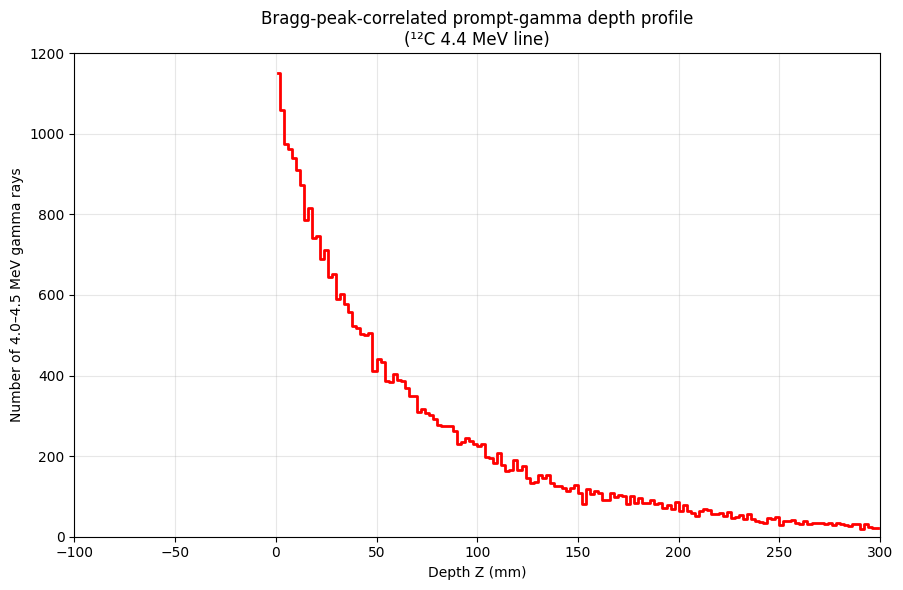

In [8]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import os

# =============================
# CONFIGURATION
# =============================
ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
TREE_NAME = "PhotonData"

# Column indices from your Geant4 code
PID_COL   = 0
X_COL     = 1
Y_COL     = 2
Z_COL     = 3
E_COL     = 4

# Physics selection
GAMMA_PID = 22
E_MIN = 4.0   # MeV
E_MAX = 4.5   # MeV

# Z binning (phantom depth)
Z_MIN = 0.0     # mm
Z_MAX = 300.0   # mm  (adjust if needed)
Z_BIN = 2.0     # mm
# =============================

# Open ROOT file
file = ROOT.TFile(ROOT_FILE, "READ")
tree = file.Get(TREE_NAME)

if not tree:
    print("ERROR: Tree not found!")
    file.Close()
    exit()

n_entries = tree.GetEntries()
print(f"Total entries: {n_entries:,}")

# Setup arrays
pid = np.zeros(1, dtype=int)
z   = np.zeros(1, dtype=float)
E   = np.zeros(1, dtype=float)

tree.SetBranchStatus("*", 0)
tree.SetBranchStatus("*", 1)

tree.GetBranch(tree.GetListOfBranches()[PID_COL].GetName()).SetAddress(pid)
tree.GetBranch(tree.GetListOfBranches()[Z_COL].GetName()).SetAddress(z)
tree.GetBranch(tree.GetListOfBranches()[E_COL].GetName()).SetAddress(E)

# Prepare Z bins
z_bins = np.arange(Z_MIN, Z_MAX + Z_BIN, Z_BIN)
z_centers = 0.5 * (z_bins[:-1] + z_bins[1:])
counts = np.zeros(len(z_centers))

# Loop over events
for i in range(n_entries):
    tree.GetEntry(i)

    # Select gammas in energy window
    if pid[0] == GAMMA_PID and E_MIN <= E[0] <= E_MAX:
        if Z_MIN <= z[0] < Z_MAX:
            idx = int((z[0] - Z_MIN) / Z_BIN)
            counts[idx] += 1

    if (i + 1) % 10_000_000 == 0:
        print(f"Processed {i+1:,} entries...")

file.Close()

# -----------------------------
# Plot depth profile
# -----------------------------
plt.figure(figsize=(9, 6))

plt.plot(
    z_centers,
    counts,
    drawstyle="steps-mid",
    linewidth=2,
    color="red"
)

plt.xlabel("Depth Z (mm)")
plt.ylabel("Number of 4.0–4.5 MeV gamma rays")
plt.title("Bragg-peak-correlated prompt-gamma depth profile\n(¹²C 4.4 MeV line)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.xlim(-100,300)
plt.ylim(0,1200)
plt.show()


In [9]:
import ROOT
import numpy as np
import pandas as pd
import os

# ---------------- CONFIG ----------------
ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
TREE_NAME = "PhotonData"

E_MIN = 4.0   # MeV
E_MAX = 4.5   # MeV
# ----------------------------------------

# Open ROOT file
file = ROOT.TFile(ROOT_FILE, "READ")
if not file or file.IsZombie():
    raise RuntimeError("Cannot open ROOT file")

tree = file.Get(TREE_NAME)
if not tree:
    raise RuntimeError(f"Tree '{TREE_NAME}' not found")

print(f"Total entries in tree: {tree.GetEntries():,}")

# Prepare arrays
pid = np.zeros(1, dtype=np.int32)
posz = np.zeros(1, dtype=np.float64)
energy = np.zeros(1, dtype=np.float64)

# Set branch addresses
tree.SetBranchStatus("*", 0)
tree.SetBranchStatus("PID", 1)
tree.SetBranchStatus("PosZ", 1)
tree.SetBranchStatus("KineticEnergy", 1)

tree.GetBranch("PID").SetAddress(pid)
tree.GetBranch("PosZ").SetAddress(posz)
tree.GetBranch("KineticEnergy").SetAddress(energy)

# Containers
data = []

# Loop over events
for i in range(tree.GetEntries()):
    tree.GetEntry(i)

    # Photon PID check (Geant4 gamma = 22)
    if pid[0] != 22:
        continue

    # Energy window selection
    if E_MIN <= energy[0] <= E_MAX:
        data.append({
            "EventID": i,
            "True_Z_mm": posz[0],
            "Energy_MeV": energy[0]
        })

    # Progress print (optional)
    if (i + 1) % 5_000_000 == 0:
        print(f"Processed {i+1:,} events...")

file.Close()

print(f"\nSelected 4.0–4.5 MeV gamma events: {len(data):,}")

# Convert to DataFrame
df = pd.DataFrame(data)

# Save to CSV
output_csv = "true_emission_Z_4p0_4p5_MeV.csv"
df.to_csv(output_csv, index=False)

print(f"✓ CSV saved: {output_csv}")
print("\nFirst 5 rows:")
print(df.head())


Total entries in tree: 14,282,849
Processed 5,000,000 events...
Processed 10,000,000 events...

Selected 4.0–4.5 MeV gamma events: 1,056,803
✓ CSV saved: true_emission_Z_4p0_4p5_MeV.csv

First 5 rows:
   EventID   True_Z_mm  Energy_MeV
0        5 -117.495152    4.382523
1       13  -62.439311    4.422672
2       16 -129.943783    4.128730
3       46 -246.156097    4.149515
4       75 -138.129366    4.391245


In [14]:
# -----------------------------------------
# CONFIGURATION
# -----------------------------------------
CSV_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

TRUE_ENERGY_COL = 11   # true energy (MeV)
TRUE_Z_COL      = 10   # true Z position (mm)

E_MIN = 4.0
E_MAX = 4.5
# -----------------------------------------

selected_events = []

with open(CSV_FILE, "r") as f:
    lines = f.readlines()

# Skip header
for line in lines[1:]:
    parts = [p.strip() for p in line.split(",")]

    try:
        true_energy = float(parts[TRUE_ENERGY_COL])
        true_z      = float(parts[TRUE_Z_COL])

        if E_MIN <= true_energy <= E_MAX:
            selected_events.append((true_energy, true_z))

    except:
        continue

print(f"\nEvents with true energy in {E_MIN}–{E_MAX} MeV: {len(selected_events)}\n")

print("TrueEnergy (MeV)   TrueZ (mm)")
print("--------------------------------")
for e, z in selected_events[:10]:
    print(f"{e:>8.3f}          {z:>8.2f}")



Events with true energy in 4.0–4.5 MeV: 170

TrueEnergy (MeV)   TrueZ (mm)
--------------------------------
   4.146           -125.40
   4.273           -125.40
   4.350           -187.29
   4.417           -127.04
   4.478           -193.44
   4.478           -193.44
   4.387            -98.39
   4.387            -98.39
   4.077           -232.36
   4.077           -232.36


Selected events: 170


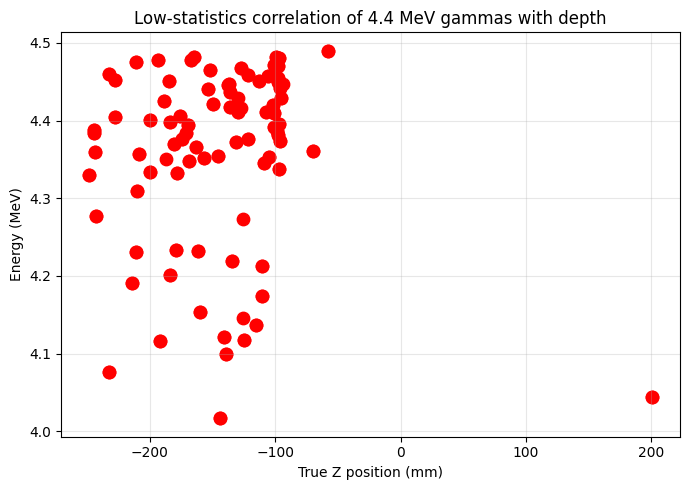

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

CSV_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

TRUE_ENERGY_COL = 11
TRUE_Z_COL = 10

E_MIN = 4.0
E_MAX = 4.5

energies = []
z_true = []

with open(CSV_FILE, "r") as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = [p.strip() for p in line.split(",")]
    try:
        E = float(parts[TRUE_ENERGY_COL])
        Z = float(parts[TRUE_Z_COL])

        if E_MIN <= E <= E_MAX:
            energies.append(E)
            z_true.append(Z)

    except:
        continue

print(f"Selected events: {len(z_true)}")

# Scatter plot (better for low statistics)
plt.figure(figsize=(7, 5))

plt.scatter(
    z_true,
    energies,
    color="red",
    s=80
)

plt.xlabel("True Z position (mm)")
plt.ylabel("Energy (MeV)")
plt.title("Low-statistics correlation of 4.4 MeV gammas with depth")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Number of events: 170


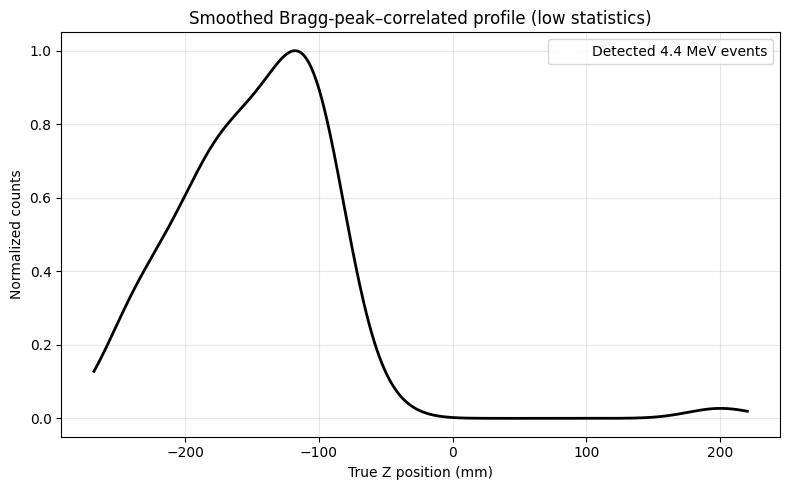

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# z_true list you already extracted
z_true = np.array(z_true)   # reuse from previous code

print("Number of events:", len(z_true))

# Create KDE (bandwidth controls smoothness)
kde = gaussian_kde(z_true, bw_method=0.4)  # increase if still noisy

# Define smooth Z axis
z_smooth = np.linspace(min(z_true)-20, max(z_true)+20, 500)

# Evaluate density
density = kde(z_smooth)

# Normalize (like paper)
density /= density.max()

# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    z_smooth,
    density,
    color="black",
    linewidth=2
)

plt.scatter(
    z_true,
    np.zeros_like(z_true),
    color="white",
    s=80,
    label="Detected 4.4 MeV events"
)

plt.xlabel("True Z position (mm)")
plt.ylabel("Normalized counts")
plt.title("Smoothed Bragg-peak–correlated profile (low statistics)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


Number of selected events: 337


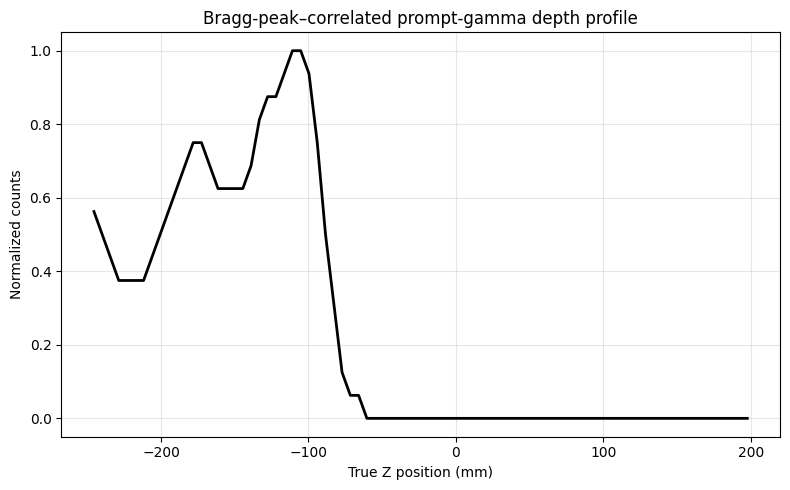

Number of events: 337


In [3]:
import numpy as np
import matplotlib.pyplot as plt

CSV_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

TRUE_ENERGY_COL = 11
TRUE_Z_COL = 10

# WIDER energy window (THIS IS THE KEY)
E_MIN = 4.0
E_MAX = 5.0

z_vals = []

with open(CSV_FILE, "r") as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = [p.strip() for p in line.split(",")]
    try:
        E = float(parts[TRUE_ENERGY_COL])
        Z = float(parts[TRUE_Z_COL])

        if E_MIN <= E <= E_MAX:
            z_vals.append(Z)

    except:
        continue
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ----------------------------------
# CONFIGURATION
# ----------------------------------
CSV_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

TRUE_ENERGY_COL = 11
TRUE_Z_COL = 10

E_MIN = 3.0   # MeV  (wider window)
E_MAX = 5.0   # MeV

N_BINS = 80
SMOOTH_SIGMA = 2.0   # controls smoothness
# ----------------------------------

z_vals = []

# Read CSV
with open(CSV_FILE, "r") as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = [p.strip() for p in line.split(",")]
    try:
        E = float(parts[TRUE_ENERGY_COL])
        Z = float(parts[TRUE_Z_COL])

        if E_MIN <= E <= E_MAX:
            z_vals.append(Z)

    except:
        continue

z_vals = np.array(z_vals)

print("Number of selected events:", len(z_vals))

# Histogram
counts, edges = np.histogram(z_vals, bins=N_BINS)
centers = 0.5 * (edges[:-1] + edges[1:])

# Smooth histogram
counts_smooth = gaussian_filter1d(counts, sigma=SMOOTH_SIGMA)

# Normalize
counts_smooth = counts_smooth / counts_smooth.max()

# Plot smooth curve ONLY
plt.figure(figsize=(8, 5))

plt.plot(
    centers,
    counts_smooth,
    color="black",
    linewidth=2
)

plt.xlabel("True Z position (mm)")
plt.ylabel("Normalized counts")
plt.title("Bragg-peak–correlated prompt-gamma depth profile")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Number of events:", len(z_vals))

# Histogram
#bins = np.linspace(min(z_vals), max(z_vals), 50)
#counts, edges = np.histogram(z_vals, bins=bins)
#centers = 0.5 * (edges[:-1] + edges[1:])

# Normalize (like paper)
#counts = counts / counts.max()

#plt.figure(figsize=(8, 5))
#plt.plot(centers, counts, drawstyle="steps-mid", linewidth=2)

#plt.xlabel("True Z position (mm)")
#plt.ylabel("Normalized counts")
#plt.title("Bragg-peak-correlated depth profile (3–5 MeV gammas)")
#plt.grid(alpha=0.3)
#plt.tight_layout()
#plt.show()


Number of selected events: 337


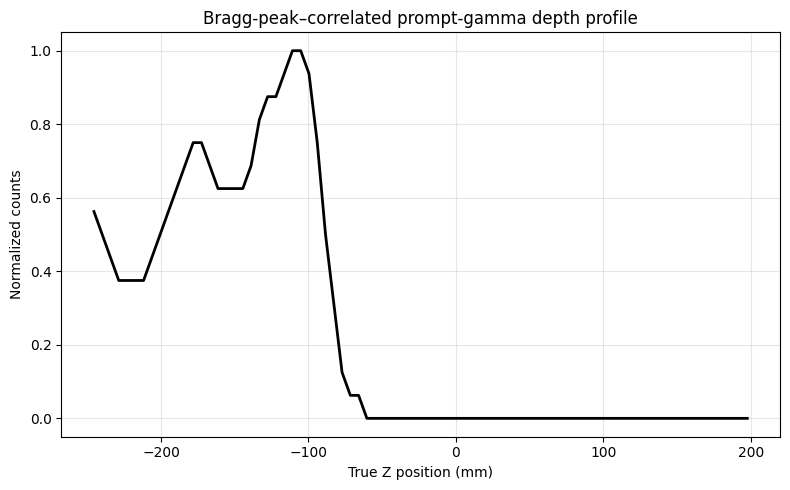

Number of events: 337


In [4]:
import csv
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
PROTON_CSV = "proton_bragg_data.csv"
Z_MIN = -300
Z_MAX = 300
Z_BIN_WIDTH = 2   # finer bins for Bragg peak

# Column indices
Z_COL     = 1
EDEP_COL  = 2

# -----------------------------
# READ DATA
# -----------------------------
z_vals = []
edep_vals = []

with open(PROTON_CSV, "r") as f:
    reader = csv.reader(f)
    header = next(reader)

    for row in reader:
        try:
            z = float(row[Z_COL])
            edep = float(row[EDEP_COL])

            z_vals.append(z)
            edep_vals.append(edep)

        except:
            continue

z_vals = np.array(z_vals)
edep_vals = np.array(edep_vals)

print(f"Total proton steps: {len(z_vals)}")

# -----------------------------
# BIN ENERGY DEPOSITION
# -----------------------------
z_bins = np.arange(Z_MIN, Z_MAX + Z_BIN_WIDTH, Z_BIN_WIDTH)
edep_binned, _ = np.histogram(z_vals, bins=z_bins, weights=edep_vals)
z_centers = 0.5 * (z_bins[:-1] + z_bins[1:])

# Normalize
edep_norm = edep_binned / edep_binned.max()

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(z_centers, edep_norm, color="black", linewidth=2)

plt.xlabel("Depth Z (mm)")
plt.ylabel("Normalized energy deposition")
plt.title("Proton Bragg peak")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [18]:
import matplotlib.pyplot as plt

true_z = []
hit_z  = []

# Column indices based on your CSV write order
# Event_ID(0), Track_ID(1), Detector(2),
# Pos_X(3), Pos_Y(4), Pos_Z(5),
# Energy(6), Deposited(7),
# True_X(8), True_Y(9), True_Z(10),
# Initial_Energy(11), Detector_Num(12)

TRUE_Z_COL = 10
HIT_Z_COL  = 5
DETECTOR_COL = 2

CSV_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

with open(CSV_FILE, "r") as f:
    lines = f.readlines()

for line in lines[1:]:  # skip header
    parts = [p.strip() for p in line.split(",")]

    # Skip broken lines
    if len(parts) < 13:
        continue

    # Select CylDetector only
    if parts[DETECTOR_COL] != "CylDetector":
        continue

    try:
        tz = float(parts[TRUE_Z_COL])
        hz = float(parts[HIT_Z_COL])

        true_z.append(tz)
        hit_z.append(hz)

    except:
        continue

print("Total valid points:", len(true_z))


Total valid points: 853


In [9]:
CSV_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000000.csv"

with open(CSV_FILE, "r") as f:
    for i in range(5):
        print(f.readline())


Event_ID, Track_ID, Detector, Pos_X_mm, Pos_Y_mm, Pos_Z_mm, Energy_MeV ,Deposited_MeV, True_Origin_X_mm, True_Origin_Y_mm, True_Origin_Z_mm, Initial_Energy_MeV, Detector_Num

60101,     5,    CylDetector,  64.994760,  -0.825355,  -116.352896,  0.797679,  0.000000, 12.584709,  -12.773483,  -169.586203,  0.797679,  1

52208,     8,    CylDetector,  -64.929901,  -3.017937,  -212.028872,  0.322001,  0.000000, -11.678463,  -8.291097,  -236.495430,  3.264937,553961761,     7,    CylDetector,  -51.710452,  39.383108,  -103.512124,  1.195334,  0.000000, -2.569862,  -20.466817,  -150.959825,  1.363262,  1

61761,     7,    CylDetector2,  -54.562510,  44.645073,  -98.629060,  1.195334,  0.000000, -2.569862,  -20.466817,  -150.959825,  1.363262,  2

61761,     6,    CylDetector,  -45.917930,  46.005910,  -167.364444,  0.267306,  0.000000, -2.569862,  -20.466817,  -150.959825,  2.201494,  1



Selected events: 61638


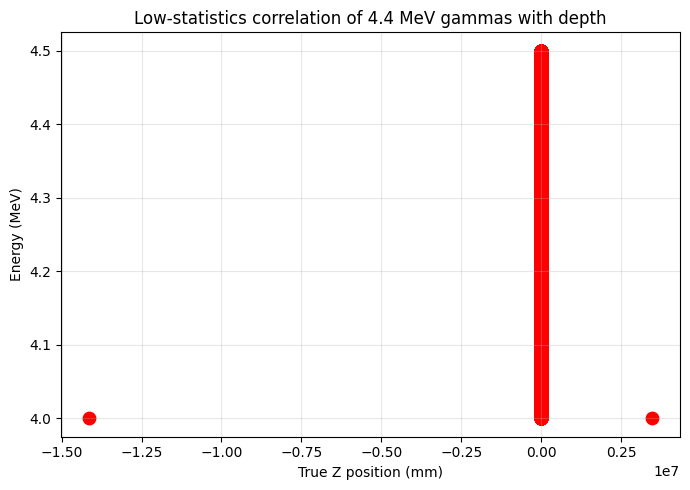

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

CSV_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000000.csv"

TRUE_ENERGY_COL = 11
TRUE_Z_COL = 10

E_MIN = 4.0
E_MAX = 4.5

energies = []
z_true = []

with open(CSV_FILE, "r") as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = [p.strip() for p in line.split(",")]
    try:
        E = float(parts[TRUE_ENERGY_COL])
        Z = float(parts[TRUE_Z_COL])

        if E_MIN <= E <= E_MAX:
            energies.append(E)
            z_true.append(Z)

    except:
        continue

print(f"Selected events: {len(z_true)}")

# Scatter plot (better for low statistics)
plt.figure(figsize=(7, 5))

plt.scatter(
    z_true,
    energies,
    color="red",
    s=80
)

plt.xlabel("True Z position (mm)")
plt.ylabel("Energy (MeV)")
plt.title("Low-statistics correlation of 4.4 MeV gammas with depth")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Number of events: 61638


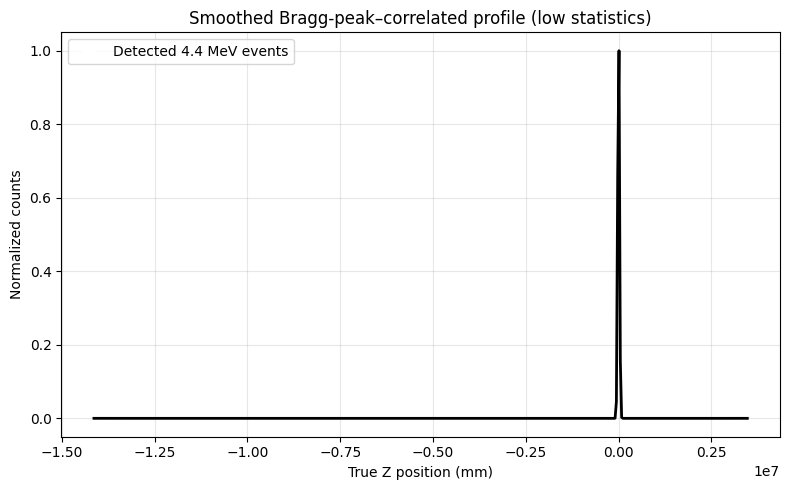

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# z_true list you already extracted
z_true = np.array(z_true)   # reuse from previous code

print("Number of events:", len(z_true))

# Create KDE (bandwidth controls smoothness)
kde = gaussian_kde(z_true, bw_method=0.4)  # increase if still noisy

# Define smooth Z axis
z_smooth = np.linspace(min(z_true)-20, max(z_true)+20, 500)

# Evaluate density
density = kde(z_smooth)

# Normalize (like paper)
density /= density.max()

# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    z_smooth,
    density,
    color="black",
    linewidth=2
)

plt.scatter(
    z_true,
    np.zeros_like(z_true),
    color="white",
    s=80,
    label="Detected 4.4 MeV events"
)

plt.xlabel("True Z position (mm)")
plt.ylabel("Normalized counts")
plt.title("Smoothed Bragg-peak–correlated profile (low statistics)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# FILE PATHS
# ==================================================
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"
GAMMA_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

# ==================================================
# PARAMETERS
# ==================================================
dz_mm = 1.0          # voxel thickness in mm (Bragg data)
x_offset_mm = -100.0 # shift depth axis if needed

# ==================================================
# LOAD BRAGG PEAK DATA
# ==================================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX", "iY", "iZ", "Edep_MeV", "Edep2", "Entries"]
)

# Convert to physical depth
bragg_z = bragg_df["iZ"] * dz_mm + x_offset_mm
bragg_dose = bragg_df["Edep_MeV"]

# Normalize Bragg peak for shape comparison
bragg_dose_norm = bragg_dose / bragg_dose.max()

# ==================================================
# LOAD GAMMA DATA
# ==================================================
gamma_df = pd.read_csv(GAMMA_FILE)

# ⚠️ CHANGE THESE COLUMN NAMES IF NEEDED
gamma_z = gamma_df["z"]                  # z-position
gamma_counts = gamma_df["normalized_counts"]

# Normalize gamma profile (if not already)
gamma_counts_norm = gamma_counts / gamma_counts.max()

# ==================================================
# PLOT BOTH TOGETHER
# ==================================================
plt.figure(figsize=(8, 5))

plt.plot(bragg_z, bragg_dose_norm, label="Proton Bragg Peak", linewidth=2)
plt.plot(gamma_z, gamma_counts_norm, label="Prompt Gamma Profile", linewidth=2)

plt.xlabel("Depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Comparison of Bragg Peak and Prompt Gamma Emission")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


ParserError: Error tokenizing data. C error: Expected 14 fields in line 3, saw 25


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# FILES
# --------------------------------------------------
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"
GAMMA_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

dz_mm = 1.0
x_offset_mm = -100.0

# --------------------------------------------------
# BRAGG PEAK
# --------------------------------------------------
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX", "iY", "iZ", "Edep_MeV", "Edep2", "Entries"]
)

bragg_z = bragg_df["iZ"] * dz_mm + x_offset_mm
bragg = bragg_df["Edep_MeV"]
bragg_norm = bragg / bragg.max()

# --------------------------------------------------
# GAMMA DATA (ROBUST READ)
# --------------------------------------------------
gamma_df = pd.read_csv(
    GAMMA_FILE,
    comment="#",
    sep=",\s*",
    engine="python",
    on_bad_lines="skip"
)

# 🔴 CHANGE THESE COLUMN NAMES AFTER print(gamma_df.columns)
print(gamma_df.columns)

gamma_z = gamma_df["Pos_Z_mm"]          # example
gamma_counts = gamma_df["Counts"]       # example

gamma_norm = gamma_counts / gamma_counts.max()

# --------------------------------------------------
# PLOT
# --------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(bragg_z, bragg_norm, label="Proton Bragg Peak", linewidth=2)
plt.plot(gamma_z, gamma_norm, label="Prompt Gamma Profile", linewidth=2)

plt.xlabel("Depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Bragg Peak vs Prompt Gamma Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Index(['Event_ID', 'Track_ID', 'Detector', 'Pos_X_mm', 'Pos_Y_mm', 'Pos_Z_mm',
       'Energy_MeV ', 'Deposited_MeV', 'Time_ns', 'True_Origin_X_mm',
       'True_Origin_Y_mm', 'True_Origin_Z_mm', 'Initial_Energy_MeV',
       'Detector_Num'],
      dtype='object')


<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1213512/1545462498.py:33: SyntaxWarning: invalid escape sequence '\s'
  sep=",\s*",
/tmp/ipykernel_1213512/1545462498.py:33: SyntaxWarning: invalid escape sequence '\s'
  sep=",\s*",


KeyError: 'Counts'

Gamma file columns:
Index(['Event_ID', 'Track_ID', 'Detector', 'Pos_X_mm', 'Pos_Y_mm', 'Pos_Z_mm',
       'Energy_MeV ', 'Deposited_MeV', 'Time_ns', 'True_Origin_X_mm',
       'True_Origin_Y_mm', 'True_Origin_Z_mm', 'Initial_Energy_MeV',
       'Detector_Num'],
      dtype='object')


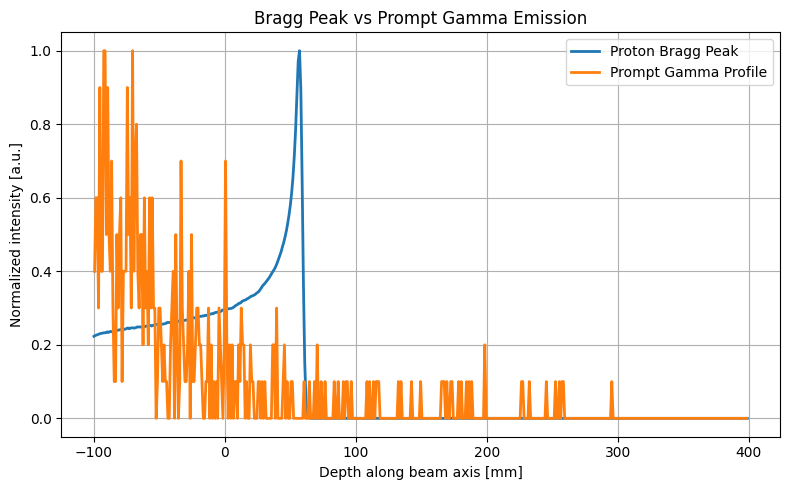

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# FILES
# ==================================================
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"
GAMMA_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

dz_mm = 1.0
x_offset_mm = -100.0

# ==================================================
# LOAD BRAGG PEAK DATA
# ==================================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX", "iY", "iZ", "Edep_MeV", "Edep2", "Entries"]
)

bragg_z = bragg_df["iZ"] * dz_mm + x_offset_mm
bragg = bragg_df["Edep_MeV"]
bragg_norm = bragg / bragg.max()

# ==================================================
# LOAD GAMMA HIT DATA (ROBUST)
# ==================================================
gamma_df = pd.read_csv(
    GAMMA_FILE,
    comment="#",
    sep=r",\s*",
    engine="python",
    on_bad_lines="skip"
)

print("Gamma file columns:")
print(gamma_df.columns)

# 🔴 CHANGE THIS IF YOUR COLUMN NAME IS DIFFERENT
gamma_z_hits = gamma_df["Pos_Z_mm"]   # or "Hit_Z_mm"

# ==================================================
# BUILD GAMMA PROFILE (HISTOGRAM)
# ==================================================
bins = np.linspace(bragg_z.min(), bragg_z.max(), len(bragg_z))

gamma_counts, bin_edges = np.histogram(gamma_z_hits, bins=bins)
gamma_z_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

gamma_norm = gamma_counts / gamma_counts.max()

# ==================================================
# PLOT COMPARISON
# ==================================================
plt.figure(figsize=(8, 5))

plt.plot(bragg_z, bragg_norm, label="Proton Bragg Peak", linewidth=2)
plt.plot(gamma_z_centers, gamma_norm, label="Prompt Gamma Profile", linewidth=2)

plt.xlabel("Depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Bragg Peak vs Prompt Gamma Emission")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Gamma file columns:
Index(['Event_ID', 'Track_ID', 'Detector', 'Pos_X_mm', 'Pos_Y_mm', 'Pos_Z_mm',
       'Energy_MeV ', 'Deposited_MeV', 'Time_ns', 'True_Origin_X_mm',
       'True_Origin_Y_mm', 'True_Origin_Z_mm', 'Initial_Energy_MeV',
       'Detector_Num'],
      dtype='object')
Total gammas: 1720
4–5 MeV gammas: 0


/tmp/ipykernel_1213512/2670467033.py:71: RuntimeWarning: invalid value encountered in divide
  gamma_44_norm = gamma_44_counts / gamma_44_counts.max()


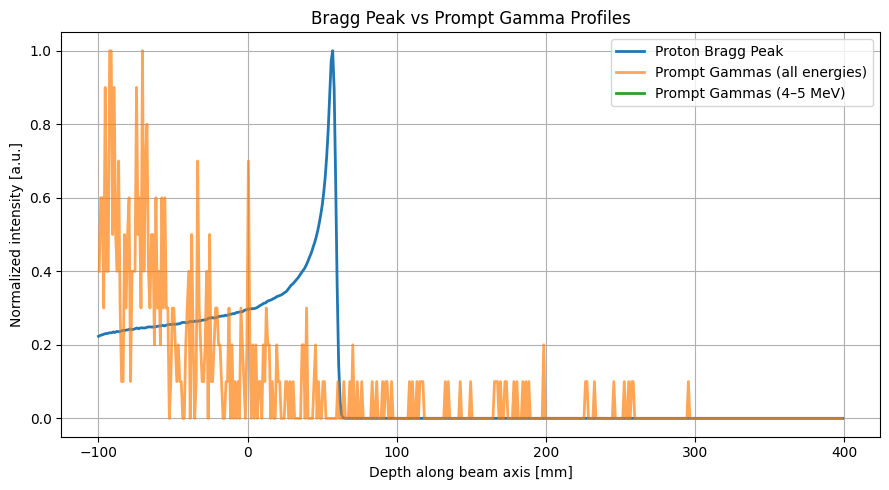

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# FILES
# ==================================================
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"
GAMMA_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

dz_mm = 1.0
x_offset_mm = -100.0

# ==================================================
# LOAD BRAGG PEAK DATA
# ==================================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX", "iY", "iZ", "Edep_MeV", "Edep2", "Entries"]
)

bragg_z = bragg_df["iZ"] * dz_mm + x_offset_mm
bragg = bragg_df["Edep_MeV"]
bragg_norm = bragg / bragg.max()

# ==================================================
# LOAD GAMMA HIT DATA
# ==================================================
gamma_df = pd.read_csv(
    GAMMA_FILE,
    comment="#",
    sep=r",\s*",
    engine="python",
    on_bad_lines="skip"
)

print("Gamma file columns:")
print(gamma_df.columns)

# --------------------------------------------------
# 🔴 CHANGE THESE IF NEEDED
# --------------------------------------------------
z_col = "Pos_Z_mm"
E_col = "Initial_Energy_MeV"   # change if Energy_keV

gamma_z = gamma_df[z_col]
gamma_E = gamma_df[E_col]

# If energy is in keV, convert to MeV
if "keV" in E_col.lower():
    gamma_E = gamma_E / 1000.0

# ==================================================
# HISTOGRAM: ALL GAMMAS
# ==================================================
bins = np.linspace(bragg_z.min(), bragg_z.max(), len(bragg_z))

gamma_all_counts, _ = np.histogram(gamma_z, bins=bins)
gamma_z_centers = 0.5 * (bins[:-1] + bins[1:])
gamma_all_norm = gamma_all_counts / gamma_all_counts.max()

# ==================================================
# HISTOGRAM: 4–5 MeV GAMMAS
# ==================================================
mask_44 = (gamma_E >= 4.0) & (gamma_E <= 5.0)
gamma_z_44 = gamma_z[mask_44]

gamma_44_counts, _ = np.histogram(gamma_z_44, bins=bins)
gamma_44_norm = gamma_44_counts / gamma_44_counts.max()

print(f"Total gammas: {len(gamma_z)}")
print(f"4–5 MeV gammas: {len(gamma_z_44)}")

# ==================================================
# PLOT COMPARISON
# ==================================================
plt.figure(figsize=(9, 5))

plt.plot(bragg_z, bragg_norm, label="Proton Bragg Peak", linewidth=2)
plt.plot(gamma_z_centers, gamma_all_norm,
         label="Prompt Gammas (all energies)", linewidth=2, alpha=0.7)
plt.plot(gamma_z_centers, gamma_44_norm,
         label="Prompt Gammas (4–5 MeV)", linewidth=2)

plt.xlabel("Depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Bragg Peak vs Prompt Gamma Profiles")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Number of selected events: 337


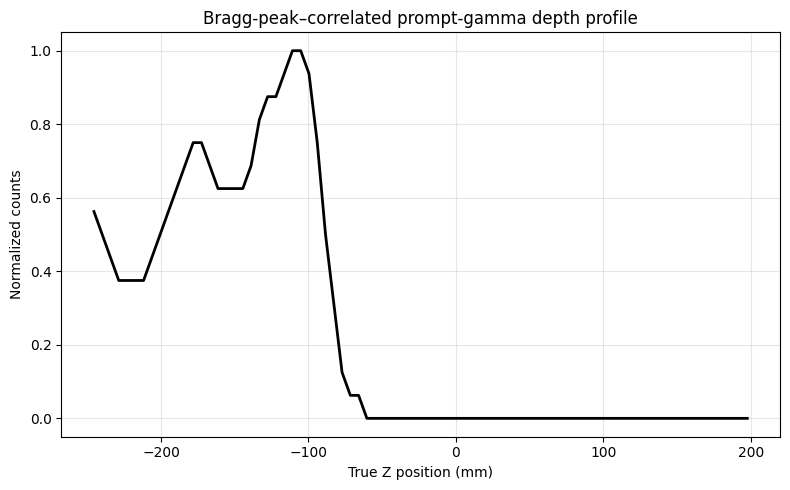

Number of events: 337


In [22]:
import numpy as np
import matplotlib.pyplot as plt

CSV_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

TRUE_ENERGY_COL = 11
TRUE_Z_COL = 10

# WIDER energy window (THIS IS THE KEY)
E_MIN = 4.0
E_MAX = 5.0

z_vals = []

with open(CSV_FILE, "r") as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = [p.strip() for p in line.split(",")]
    try:
        E = float(parts[TRUE_ENERGY_COL])
        Z = float(parts[TRUE_Z_COL])

        if E_MIN <= E <= E_MAX:
            z_vals.append(Z)

    except:
        continue
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ----------------------------------
# CONFIGURATION
# ----------------------------------
CSV_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

TRUE_ENERGY_COL = 11
TRUE_Z_COL = 10

E_MIN = 3.0   # MeV  (wider window)
E_MAX = 5.0   # MeV

N_BINS = 80
SMOOTH_SIGMA = 2.0   # controls smoothness
# ----------------------------------

z_vals = []

# Read CSV
with open(CSV_FILE, "r") as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = [p.strip() for p in line.split(",")]
    try:
        E = float(parts[TRUE_ENERGY_COL])
        Z = float(parts[TRUE_Z_COL])

        if E_MIN <= E <= E_MAX:
            z_vals.append(Z)

    except:
        continue

z_vals = np.array(z_vals)

print("Number of selected events:", len(z_vals))

# Histogram
counts, edges = np.histogram(z_vals, bins=N_BINS)
centers = 0.5 * (edges[:-1] + edges[1:])

# Smooth histogram
counts_smooth = gaussian_filter1d(counts, sigma=SMOOTH_SIGMA)

# Normalize
counts_smooth = counts_smooth / counts_smooth.max()

# Plot smooth curve ONLY
plt.figure(figsize=(8, 5))

plt.plot(
    centers,
    counts_smooth,
    color="black",
    linewidth=2
)

plt.xlabel("True Z position (mm)")
plt.ylabel("Normalized counts")
plt.title("Bragg-peak–correlated prompt-gamma depth profile")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Number of events:", len(z_vals))

# Histogram
#bins = np.linspace(min(z_vals), max(z_vals), 50)
#counts, edges = np.histogram(z_vals, bins=bins)
#centers = 0.5 * (edges[:-1] + edges[1:])

# Normalize (like paper)
#counts = counts / counts.max()

#plt.figure(figsize=(8, 5))
#plt.plot(centers, counts, drawstyle="steps-mid", linewidth=2)

#plt.xlabel("True Z position (mm)")
#plt.ylabel("Normalized counts")
#plt.title("Bragg-peak-correlated depth profile (3–5 MeV gammas)")
#plt.grid(alpha=0.3)
#plt.tight_layout()
#plt.show()


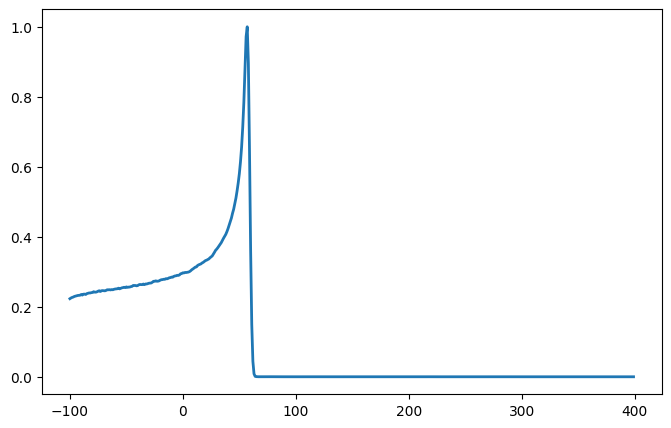

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# FILES
# ==================================================
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"
GAMMA_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

dz_mm = 1.0
x_offset_mm = -100.0

# ==================================================
# LOAD BRAGG PEAK DATA
# ==================================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX", "iY", "iZ", "Edep_MeV", "Edep2", "Entries"]
)

bragg_z = bragg_df["iZ"] * dz_mm + x_offset_mm
bragg = bragg_df["Edep_MeV"]
bragg_norm = bragg / bragg.max()
plt.figure(figsize=(8, 5))

plt.plot(bragg_z, bragg_norm, label="Proton Bragg Peak", linewidth=2)
plt.show()


Number of 4–5 MeV gammas: 224


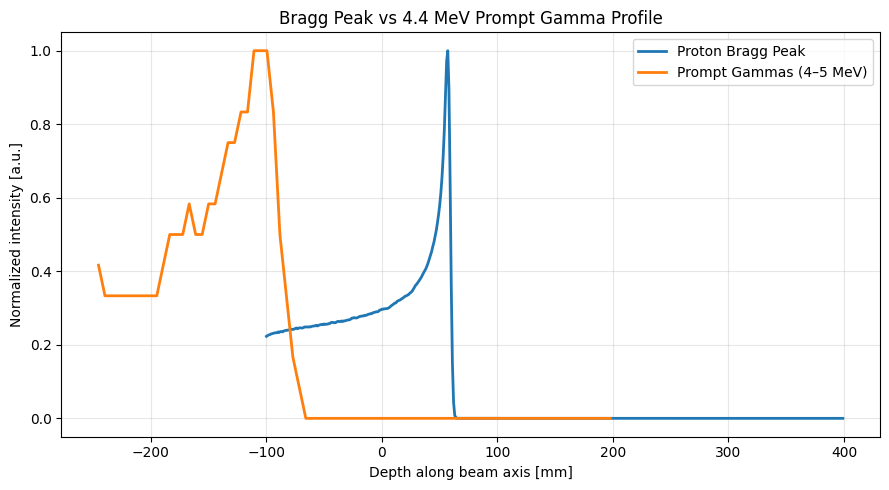

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ==================================================
# FILES
# ==================================================
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"
GAMMA_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

# ==================================================
# BRAGG PEAK PARAMETERS
# ==================================================
dz_mm = 1.0
x_offset_mm = -100.0

# ==================================================
# GAMMA PARAMETERS (FROM YOUR WORKING CODE)
# ==================================================
TRUE_Z_COL = 10
TRUE_ENERGY_COL = 11

E_MIN = 4.0   # MeV
E_MAX = 5.0   # MeV

N_BINS = 80
SMOOTH_SIGMA = 2.0

# ==================================================
# LOAD BRAGG PEAK DATA
# ==================================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX", "iY", "iZ", "Edep_MeV", "Edep2", "Entries"]
)

bragg_z = bragg_df["iZ"].values * dz_mm + x_offset_mm
bragg = bragg_df["Edep_MeV"].values
bragg_norm = bragg / bragg.max()

# ==================================================
# LOAD GAMMA DATA (MANUAL PARSING — IMPORTANT)
# ==================================================
z_vals = []

with open(GAMMA_FILE, "r") as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = [p.strip() for p in line.split(",")]
    try:
        E = float(parts[TRUE_ENERGY_COL])
        Z = float(parts[TRUE_Z_COL])

        if E_MIN <= E <= E_MAX:
            z_vals.append(Z)

    except:
        continue

z_vals = np.array(z_vals)
print("Number of 4–5 MeV gammas:", len(z_vals))

# ==================================================
# BUILD GAMMA DEPTH PROFILE
# ==================================================
gamma_counts, gamma_edges = np.histogram(z_vals, bins=N_BINS)
gamma_centers = 0.5 * (gamma_edges[:-1] + gamma_edges[1:])

# Smooth + normalize
gamma_smooth = gaussian_filter1d(gamma_counts, sigma=SMOOTH_SIGMA)
gamma_norm = gamma_smooth / gamma_smooth.max()

# ==================================================
# OVERLAY PLOT
# ==================================================
plt.figure(figsize=(9, 5))

plt.plot(
    bragg_z,
    bragg_norm,
    label="Proton Bragg Peak",
    linewidth=2
)

plt.plot(
    gamma_centers,
    gamma_norm,
    label="Prompt Gammas (4–5 MeV)",
    linewidth=2
)

plt.xlabel("Depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Bragg Peak vs 4.4 MeV Prompt Gamma Profile")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Number of 4–5 MeV gammas: 224


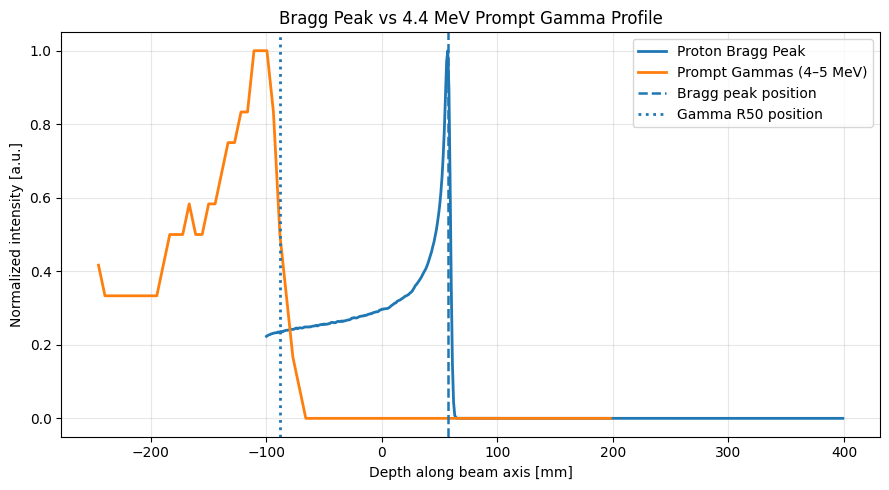

Bragg peak position : 57.00 mm
Gamma R50 position  : -88.36 mm
Gamma–Bragg shift Δz: -145.36 mm


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ==================================================
# FILES
# ==================================================
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"
GAMMA_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

# ==================================================
# BRAGG PEAK PARAMETERS
# ==================================================
dz_mm = 1.0
x_offset_mm = -100.0

# ==================================================
# GAMMA PARAMETERS (FROM YOUR WORKING CODE)
# ==================================================
TRUE_Z_COL = 10
TRUE_ENERGY_COL = 11

E_MIN = 4.0   # MeV
E_MAX = 5.0   # MeV

N_BINS = 80
SMOOTH_SIGMA = 2.0

# ==================================================
# LOAD BRAGG PEAK DATA
# ==================================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX", "iY", "iZ", "Edep_MeV", "Edep2", "Entries"]
)

bragg_z = bragg_df["iZ"].values * dz_mm + x_offset_mm
bragg = bragg_df["Edep_MeV"].values
bragg_norm = bragg / bragg.max()
# --------------------------------------------------
# Bragg peak position
# --------------------------------------------------
bragg_peak_idx = np.argmax(bragg_norm)
z_bragg_peak = bragg_z[bragg_peak_idx]

# ==================================================
# LOAD GAMMA DATA (MANUAL PARSING — IMPORTANT)
# ==================================================
z_vals = []

with open(GAMMA_FILE, "r") as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = [p.strip() for p in line.split(",")]
    try:
        E = float(parts[TRUE_ENERGY_COL])
        Z = float(parts[TRUE_Z_COL])

        if E_MIN <= E <= E_MAX:
            z_vals.append(Z)

    except:
        continue

z_vals = np.array(z_vals)
print("Number of 4–5 MeV gammas:", len(z_vals))

# ==================================================
# BUILD GAMMA DEPTH PROFILE
# ==================================================
gamma_counts, gamma_edges = np.histogram(z_vals, bins=N_BINS)
gamma_centers = 0.5 * (gamma_edges[:-1] + gamma_edges[1:])

# Smooth + normalize
gamma_smooth = gaussian_filter1d(gamma_counts, sigma=SMOOTH_SIGMA)
gamma_norm = gamma_smooth / gamma_smooth.max()
# --------------------------------------------------
# Gamma fall-off position (R50)
# --------------------------------------------------
gamma_peak_idx = np.argmax(gamma_norm)

gamma_post = gamma_norm[gamma_peak_idx:]
z_post = gamma_centers[gamma_peak_idx:]

R50_idx = np.where(gamma_post <= 0.5)[0][0]
z_gamma_R50 = z_post[R50_idx]

# ==================================================
# OVERLAY PLOT
# ==================================================
plt.figure(figsize=(9, 5))

plt.plot(
    bragg_z,
    bragg_norm,
    label="Proton Bragg Peak",
    linewidth=2
)

plt.plot(
    gamma_centers,
    gamma_norm,
    label="Prompt Gammas (4–5 MeV)",
    linewidth=2
)
plt.axvline(
    z_bragg_peak,
    linestyle="--",
    linewidth=1.8,
    label="Bragg peak position"
)

plt.axvline(
    z_gamma_R50,
    linestyle=":",
    linewidth=2,
    label="Gamma R50 position"
)

plt.xlabel("Depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Bragg Peak vs 4.4 MeV Prompt Gamma Profile")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
# --------------------------------------------------
# Print shift
# --------------------------------------------------
delta_z = z_gamma_R50 - z_bragg_peak

print(f"Bragg peak position : {z_bragg_peak:.2f} mm")
print(f"Gamma R50 position  : {z_gamma_R50:.2f} mm")
print(f"Gamma–Bragg shift Δz: {delta_z:.2f} mm")


Number of 4–5 MeV gammas: 224


ValueError: x and y must have same first dimension, but have shapes (79,) and (80,)

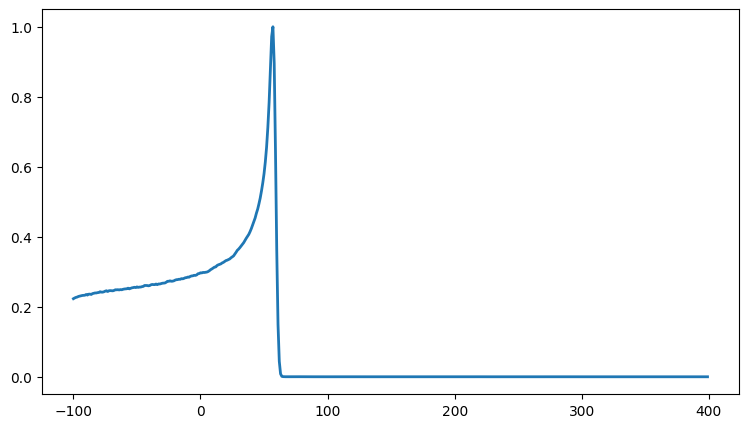

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ==================================================
# FILES
# ==================================================
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"
GAMMA_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

# ==================================================
# BRAGG PEAK PARAMETERS
# ==================================================
dz_mm = 1.0
x_offset_mm = -100.0

# ==================================================
# GAMMA PARAMETERS (FROM YOUR WORKING CODE)
# ==================================================
TRUE_Z_COL = 10
TRUE_ENERGY_COL = 11

E_MIN = 4.0   # MeV
E_MAX = 5.0   # MeV

N_BINS = 80
SMOOTH_SIGMA = 2.0

# ==================================================
# LOAD BRAGG PEAK DATA
# ==================================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX", "iY", "iZ", "Edep_MeV", "Edep2", "Entries"]
)

bragg_z_aligned = bragg_z - bragg_z.min()

bragg = bragg_df["Edep_MeV"].values
bragg_norm = bragg / bragg.max()
# --------------------------------------------------
# Bragg peak position
# --------------------------------------------------
bragg_peak_idx = np.argmax(bragg_norm)
z_bragg_peak = bragg_z[bragg_peak_idx]

# ==================================================
# LOAD GAMMA DATA (MANUAL PARSING — IMPORTANT)
# ==================================================
z_vals = []

with open(GAMMA_FILE, "r") as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = [p.strip() for p in line.split(",")]
    try:
        E = float(parts[TRUE_ENERGY_COL])
        Z = float(parts[TRUE_Z_COL])

        if E_MIN <= E <= E_MAX:
            z_vals.append(Z)

    except:
        continue

z_vals = np.array(z_vals)
print("Number of 4–5 MeV gammas:", len(z_vals))

# ==================================================
# BUILD GAMMA DEPTH PROFILE
# ==================================================
gamma_counts, gamma_edges = np.histogram(z_vals, bins=N_BINS)
gamma_z_aligned = gamma_centers - gamma_centers.min()

# Smooth + normalize
gamma_smooth = gaussian_filter1d(gamma_counts, sigma=SMOOTH_SIGMA)
gamma_norm = gamma_smooth / gamma_smooth.max()
# --------------------------------------------------
# Gamma fall-off position (R50)
# --------------------------------------------------
gamma_peak_idx = np.argmax(gamma_norm)

gamma_post = gamma_norm[gamma_peak_idx:]
z_post = gamma_centers[gamma_peak_idx:]

R50_idx = np.where(gamma_post <= 0.5)[0][0]
z_gamma_R50 = z_post[R50_idx]

START_X = -100.0

bragg_z_aligned = bragg_z_aligned + START_X
gamma_z_aligned = gamma_z_aligned + START_X


# ==================================================
# OVERLAY PLOT
# ==================================================
plt.figure(figsize=(9, 5))

plt.plot(
    bragg_z_aligned,
    bragg_norm,
    label="Proton Bragg Peak",
    linewidth=2
)

plt.plot(
    gamma_z_aligned,
    gamma_norm,
    label="Prompt Gammas (4–5 MeV)",
    linewidth=2
)

plt.xlabel("Aligned depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Aligned Bragg Peak and Prompt Gamma Profile")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Number of 4–5 MeV gammas: 224
===== RANGE RESULTS =====
Proton Bragg peak range : 57.00 mm
Proton R80 range        : 59.00 mm
Gamma R50 range         : 57.08 mm
Range difference ΔR     : -1.92 mm


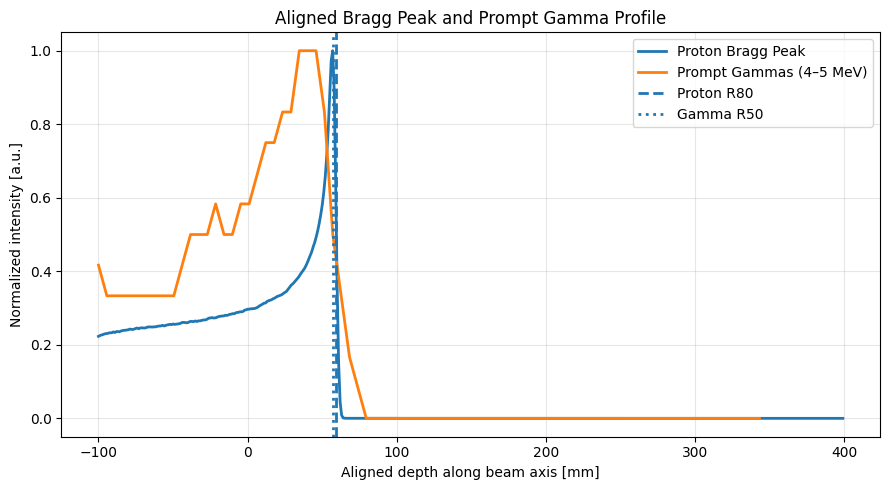

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ==================================================
# FILES
# ==================================================
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"
GAMMA_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

# ==================================================
# PARAMETERS
# ==================================================
dz_mm = 1.0
START_X = -100.0

TRUE_Z_COL = 10
TRUE_ENERGY_COL = 11
E_MIN = 4.0
E_MAX = 5.0

N_BINS = 80
SMOOTH_SIGMA = 2.0

# ==================================================
# LOAD BRAGG PEAK DATA
# ==================================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX", "iY", "iZ", "Edep_MeV", "Edep2", "Entries"]
)

# Physical depth
bragg_z = bragg_df["iZ"].values * dz_mm
bragg = bragg_df["Edep_MeV"].values
bragg_norm = bragg / bragg.max()

# Align Bragg curve
bragg_z_aligned = bragg_z - bragg_z.min() + START_X

# Bragg peak and R80
idx_peak = np.argmax(bragg_norm)
R_peak = bragg_z_aligned[idx_peak]

post_peak_dose = bragg_norm[idx_peak:]
post_peak_z = bragg_z_aligned[idx_peak:]

idx_R80 = np.where(post_peak_dose <= 0.8)[0][0]
R80 = post_peak_z[idx_R80]

# ==================================================
# LOAD GAMMA DATA (MANUAL PARSING)
# ==================================================
z_vals = []

with open(GAMMA_FILE, "r") as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = [p.strip() for p in line.split(",")]
    try:
        E = float(parts[TRUE_ENERGY_COL])
        Z = float(parts[TRUE_Z_COL])

        if E_MIN <= E <= E_MAX:
            z_vals.append(Z)
    except:
        continue

z_vals = np.array(z_vals)
print("Number of 4–5 MeV gammas:", len(z_vals))

# ==================================================
# BUILD GAMMA PROFILE
# ==================================================
gamma_counts, gamma_edges = np.histogram(z_vals, bins=N_BINS)
gamma_centers = 0.5 * (gamma_edges[:-1] + gamma_edges[1:])

gamma_smooth = gaussian_filter1d(gamma_counts, sigma=SMOOTH_SIGMA)
gamma_norm = gamma_smooth / gamma_smooth.max()

# Align gamma curve
gamma_z_aligned = gamma_centers - gamma_centers.min() + START_X

# Gamma R50
gamma_peak_idx = np.argmax(gamma_norm)
gamma_post = gamma_norm[gamma_peak_idx:]
z_post = gamma_z_aligned[gamma_peak_idx:]

idx_R50 = np.where(gamma_post <= 0.5)[0][0]
R50_gamma = z_post[idx_R50]

# ==================================================
# RANGE DIFFERENCE
# ==================================================
delta_R = R50_gamma - R80

print("===== RANGE RESULTS =====")
print(f"Proton Bragg peak range : {R_peak:.2f} mm")
print(f"Proton R80 range        : {R80:.2f} mm")
print(f"Gamma R50 range         : {R50_gamma:.2f} mm")
print(f"Range difference ΔR     : {delta_R:.2f} mm")

# ==================================================
# OVERLAY PLOT
# ==================================================
plt.figure(figsize=(9, 5))

plt.plot(bragg_z_aligned, bragg_norm, label="Proton Bragg Peak", linewidth=2)
plt.plot(gamma_z_aligned, gamma_norm, label="Prompt Gammas (4–5 MeV)", linewidth=2)

plt.axvline(R80, linestyle="--", linewidth=2, label="Proton R80")
plt.axvline(R50_gamma, linestyle=":", linewidth=2, label="Gamma R50")

plt.xlabel("Aligned depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Aligned Bragg Peak and Prompt Gamma Profile")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


===== PEAK POSITIONS =====
Bragg peak position  : 57.00 mm
Gamma peak position  : 34.64 mm
Peak shift (γ − Bragg): -22.36 mm


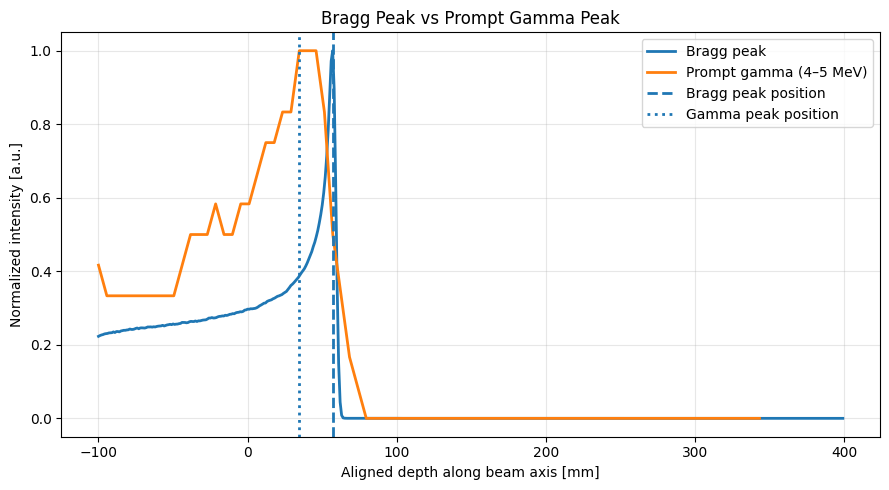

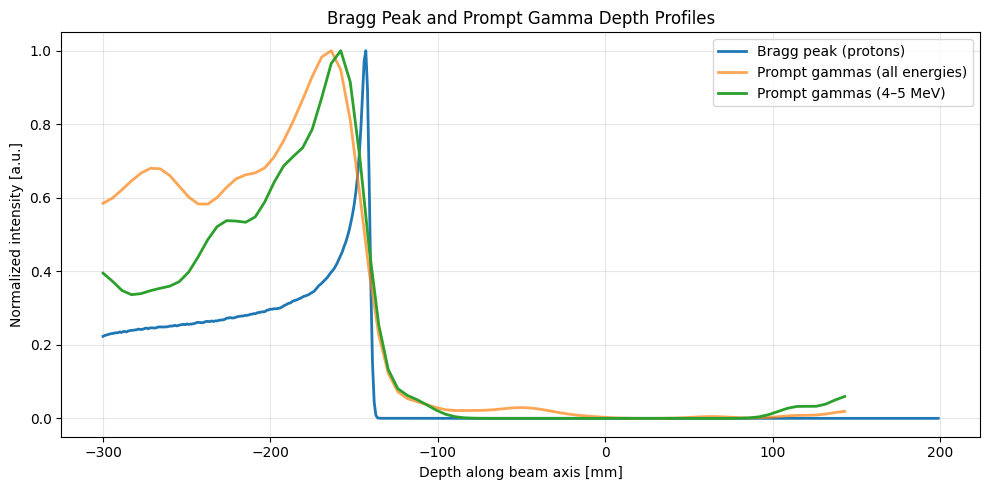

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ==================================================
# FILES
# ==================================================
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"

# ==================================================
# PARAMETERS
# ==================================================
dz_mm = 1.0
BRAGG_START_X = -300.0   # <-- Bragg axis starts at -300 mm

N_BINS = 80
SMOOTH_SIGMA = 2.0

# ==================================================
# LOAD BRAGG PEAK
# ==================================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX","iY","iZ","Edep_MeV","Edep2","Entries"]
)

# Physical depth
bragg_z = bragg_df["iZ"].values * dz_mm
bragg = bragg_df["Edep_MeV"].values
bragg_norm = bragg / bragg.max()

# Align Bragg so it starts at -300 mm
bragg_z = bragg_z - bragg_z.min() + BRAGG_START_X

# ==================================================
# GAMMA BINNING (FROM YOUR WORKING CODE)
# ==================================================
# bins and centers ALREADY DEFINED FROM z_44
# bins = np.linspace(z_44.min(), z_44.max(), N_BINS)
# centers = 0.5 * (bins[:-1] + bins[1:])

# --------------------------------------------------
# ALL GAMMAS
# --------------------------------------------------
counts_all, _ = np.histogram(z_all, bins=bins)
counts_all = gaussian_filter1d(counts_all.astype(float), SMOOTH_SIGMA)
counts_all /= counts_all.max()

# --------------------------------------------------
# 4–5 MeV GAMMAS
# --------------------------------------------------
counts_44, _ = np.histogram(z_44, bins=bins)
counts_44 = gaussian_filter1d(counts_44.astype(float), SMOOTH_SIGMA)
counts_44 /= counts_44.max()

START_X = -300.0

# Shift gamma axis
centers_shifted = centers - centers.min() + START_X

# Shift Bragg axis
bragg_z_shifted = bragg_z - bragg_z.min() + START_X


# ==================================================
# PLOT: BRAGG + GAMMAS
# ==================================================
plt.figure(figsize=(10,5))

plt.plot(
    bragg_z_shifted,
    bragg_norm,
    label="Bragg peak (protons)",
    linewidth=2
)

plt.plot(
    centers_shifted,
    counts_all,
    label="Prompt gammas (all energies)",
    linewidth=2,
    alpha=0.7
)

plt.plot(
    centers_shifted,
    counts_44,
    label="Prompt gammas (4–5 MeV)",
    linewidth=2
)

plt.xlabel("Depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Bragg Peak and Prompt Gamma Depth Profiles")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ==================================================
# FILES
# ==================================================
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons_new.txt"

# ==================================================
# PARAMETERS
# ==================================================
dz_mm = 1.0
BRAGG_START_X = -300.0   # <-- Bragg axis starts at -300 mm

N_BINS = 80
SMOOTH_SIGMA = 2.0

# ==================================================
# LOAD BRAGG PEAK
# ==================================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX","iY","iZ","Edep_MeV","Edep2","Entries"]
)

# Physical depth
bragg_z = bragg_df["iZ"].values * dz_mm
bragg = bragg_df["Edep_MeV"].values
bragg_norm = bragg / bragg.max()

# Align Bragg so it starts at -300 mm
bragg_z = bragg_z - bragg_z.min() + BRAGG_START_X

# ==================================================
# GAMMA BINNING (FROM YOUR WORKING CODE)
# ==================================================
# bins and centers ALREADY DEFINED FROM z_44
# bins = np.linspace(z_44.min(), z_44.max(), N_BINS)
# centers = 0.5 * (bins[:-1] + bins[1:])

# --------------------------------------------------
# ALL GAMMAS
# --------------------------------------------------
counts_all, _ = np.histogram(z_all, bins=bins)
counts_all = gaussian_filter1d(counts_all.astype(float), SMOOTH_SIGMA)
counts_all /= counts_all.max()

# --------------------------------------------------
# 4–5 MeV GAMMAS
# --------------------------------------------------
counts_44, _ = np.histogram(z_44, bins=bins)
counts_44 = gaussian_filter1d(counts_44.astype(float), SMOOTH_SIGMA)
counts_44 /= counts_44.max()

START_X = -300.0

# Shift gamma axis
centers_shifted = centers - centers.min() + START_X

# Shift Bragg axis
bragg_z_shifted = bragg_z - bragg_z.min() + START_X


# ==================================================
# PLOT: BRAGG + GAMMAS
# ==================================================
plt.figure(figsize=(10,5))

plt.plot(
    bragg_z_shifted,
    bragg_norm,
    label="Bragg peak (protons)",
    linewidth=2
)

plt.plot(
    centers_shifted,
    counts_all,
    label="Prompt gammas (all energies)",
    linewidth=2,
    alpha=0.7
)

plt.plot(
    centers_shifted,
    counts_44,
    label="Prompt gammas (4–5 MeV)",
    linewidth=2
)

plt.xlabel("Depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Bragg Peak and Prompt Gamma Depth Profiles")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


NameError: name 'z_all' is not defined

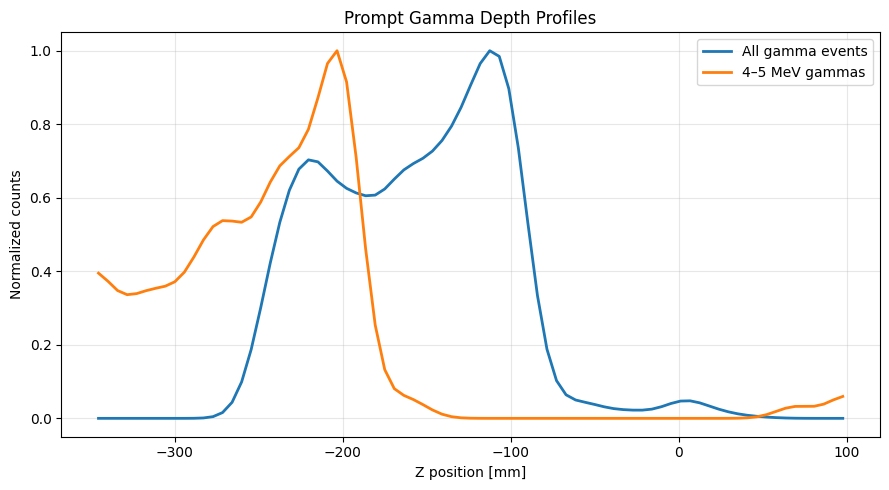

In [45]:
# ==================================================
# USE SAME Z-BINS AS 4.4 MeV CASE
# ==================================================
N_BINS = 80
SMOOTH_SIGMA = 2.0

# ---- Define PHYSICAL bins from 4.4 MeV gammas ----
bins = np.linspace(z_44.min(), z_44.max(), N_BINS)
centers = 0.5 * (bins[:-1] + bins[1:])

# ==================================================
# ALL GAMMAS PROFILE (FIXED)
# ==================================================
counts_all, _ = np.histogram(z_all, bins=bins)
counts_all = gaussian_filter1d(counts_all.astype(float), SMOOTH_SIGMA)
counts_all /= counts_all.max()

# ==================================================
# 4.4 MeV GAMMAS PROFILE (REFERENCE)
# ==================================================
counts_44, _ = np.histogram(z_44, bins=bins)
counts_44 = gaussian_filter1d(counts_44.astype(float), SMOOTH_SIGMA)
counts_44 /= counts_44.max()

# ==================================================
# PLOT GAMMAS ONLY (CORRECT AXIS)
# ==================================================
plt.figure(figsize=(9,5))

plt.plot(centers, counts_all, label="All gamma events", linewidth=2)
plt.plot(centers, counts_44, label="4–5 MeV gammas", linewidth=2)

plt.xlabel("Z position [mm]")
plt.ylabel("Normalized counts")
plt.title("Prompt Gamma Depth Profiles")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


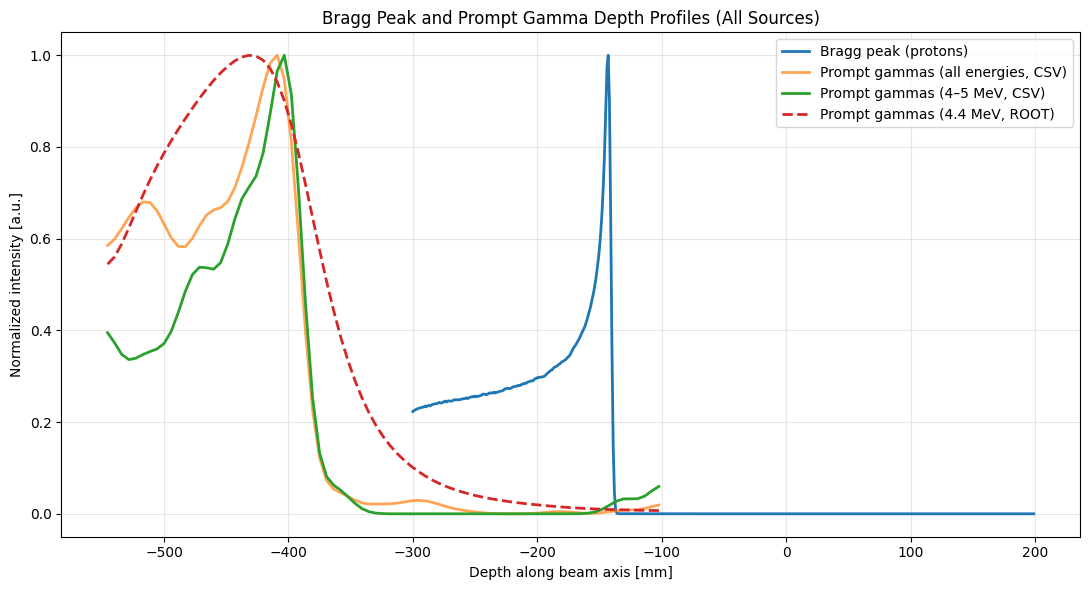

In [53]:
bins = np.linspace(z_44.min(), z_44.max(), N_BINS)
centers = 0.5 * (bins[:-1] + bins[1:])

# All gammas
counts_all, _ = np.histogram(z_all, bins=bins)
gamma_all = gaussian_filter1d(counts_all.astype(float), SMOOTH_SIGMA)
gamma_all /= gamma_all.max()

# 4–5 MeV gammas
counts_44, _ = np.histogram(z_44, bins=bins)
gamma_44 = gaussian_filter1d(counts_44.astype(float), SMOOTH_SIGMA)
gamma_44 /= gamma_44.max()

# ==================================================
# 3️⃣ GAMMAS FROM ROOT (4.4 MeV)
# ==================================================
file = ROOT.TFile(ROOT_GAMMA_FILE, "READ")
tree = file.Get(TREE_NAME)

pid = np.zeros(1, dtype=int)
z   = np.zeros(1, dtype=float)
E   = np.zeros(1, dtype=float)

tree.GetBranch(tree.GetListOfBranches()[0].GetName()).SetAddress(pid)
tree.GetBranch(tree.GetListOfBranches()[3].GetName()).SetAddress(z)
tree.GetBranch(tree.GetListOfBranches()[4].GetName()).SetAddress(E)

z_root = []

for i in range(tree.GetEntries()):
    tree.GetEntry(i)
    if pid[0] == 22 and 4.0 <= E[0] <= 4.5:
        z_root.append(z[0])

file.Close()

z_root = np.array(z_root) - z0 + START_X

counts_root, _ = np.histogram(z_root, bins=bins)
gamma_root = gaussian_filter1d(counts_root.astype(float), SMOOTH_SIGMA)
gamma_root /= gamma_root.max()

# ==================================================
# 4️⃣ FINAL OVERLAY PLOT
# ==================================================
plt.figure(figsize=(11, 6))

plt.plot(bragg_z, bragg_norm,
         label="Bragg peak (protons)", linewidth=2)

plt.plot(centers, gamma_all,
         label="Prompt gammas (all energies, CSV)", linewidth=2, alpha=0.7)

plt.plot(centers, gamma_44,
         label="Prompt gammas (4–5 MeV, CSV)", linewidth=2)

plt.plot(centers, gamma_root,
         label="Prompt gammas (4.4 MeV, ROOT)", linewidth=2, linestyle="--")

plt.xlabel("Depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Bragg Peak and Prompt Gamma Depth Profiles (All Sources)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Total entries: 14,282,849
Selected 4.4 MeV gammas: 34357


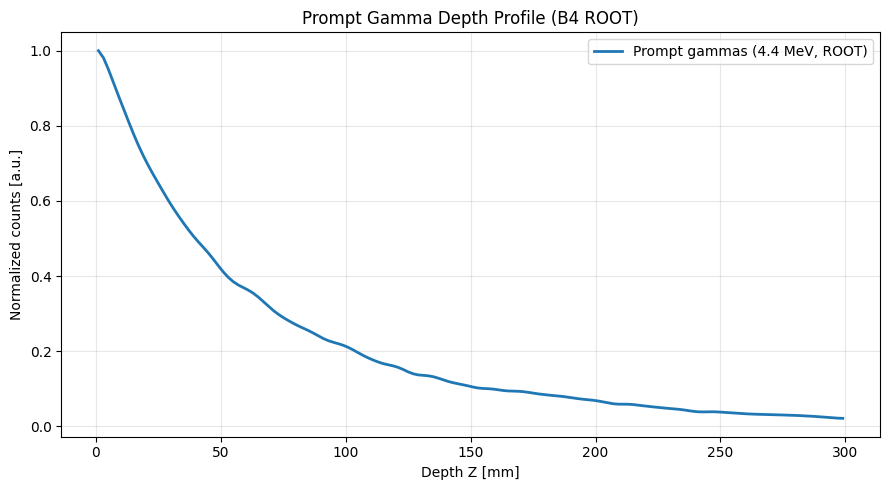

In [59]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ==================================================
# FILE & TREE
# ==================================================
ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
TREE_NAME = "PhotonData"

# ==================================================
# PHYSICS SELECTION
# ==================================================
GAMMA_PID = 22
E_MIN = 4.0   # MeV
E_MAX = 4.5   # MeV

# ==================================================
# Z BINNING (same style as others)
# ==================================================
Z_MIN = 0.0     # mm
Z_MAX = 300.0   # mm
Z_BIN = 2.0     # mm

SMOOTH_SIGMA = 2.0

# ==================================================
# OPEN ROOT FILE
# ==================================================
file = ROOT.TFile(ROOT_FILE, "READ")
tree = file.Get(TREE_NAME)

if not tree:
    raise RuntimeError("Tree not found")

n_entries = tree.GetEntries()
print(f"Total entries: {n_entries:,}")

# ==================================================
# SETUP BRANCHES (index-based, like your code)
# ==================================================
pid = np.zeros(1, dtype=int)
z   = np.zeros(1, dtype=float)
E   = np.zeros(1, dtype=float)

tree.GetBranch(tree.GetListOfBranches()[0].GetName()).SetAddress(pid)
tree.GetBranch(tree.GetListOfBranches()[3].GetName()).SetAddress(z)
tree.GetBranch(tree.GetListOfBranches()[4].GetName()).SetAddress(E)

# ==================================================
# HISTOGRAM SETUP
# ==================================================
z_bins = np.arange(Z_MIN, Z_MAX + Z_BIN, Z_BIN)
z_centers = 0.5 * (z_bins[:-1] + z_bins[1:])
counts = np.zeros(len(z_centers))

# ==================================================
# EVENT LOOP
# ==================================================
for i in range(n_entries):
    tree.GetEntry(i)

    if pid[0] == GAMMA_PID and E_MIN <= E[0] <= E_MAX:
        if Z_MIN <= z[0] < Z_MAX:
            idx = int((z[0] - Z_MIN) / Z_BIN)
            counts[idx] += 1

file.Close()

print("Selected 4.4 MeV gammas:", int(counts.sum()))

# ==================================================
# SMOOTH + NORMALIZE
# ==================================================
counts_smooth = gaussian_filter1d(counts.astype(float), SMOOTH_SIGMA)
counts_norm = counts_smooth / counts_smooth.max()

# ==================================================
# PLOT PROMPT GAMMA DEPTH PROFILE
# ==================================================
plt.figure(figsize=(9, 5))

plt.plot(
    z_centers,
    counts_norm,
    linewidth=2,
    label="Prompt gammas (4.4 MeV, ROOT)"
)

plt.xlabel("Depth Z [mm]")
plt.ylabel("Normalized counts [a.u.]")
plt.title("Prompt Gamma Depth Profile (B4 ROOT)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


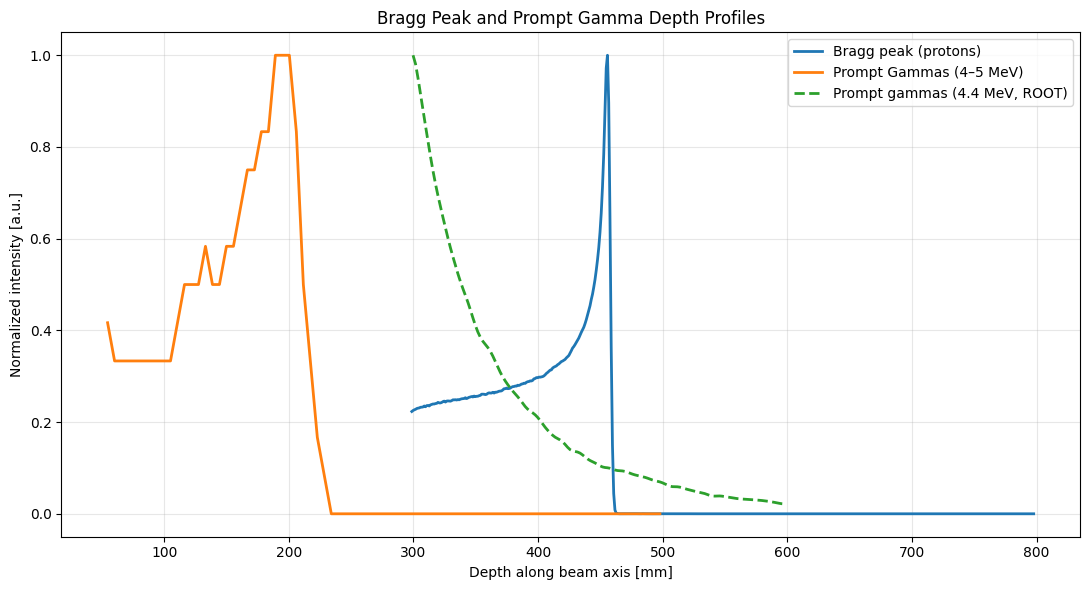

In [74]:

SHIFT_MM = 300.0
gamma_centers_shifted = gamma_centers + SHIFT_MM

# --------------------------------------------------
# Use the EXISTING ROOT gamma depth axis: z_centers
# --------------------------------------------------
x_start = min(
    bragg_z.min(),
    centers.min(),
    z_centers.min()
)

bragg_z_aligned = bragg_z - x_start 
centers_aligned = centers - x_start 
root_z_aligned  = z_centers - x_start 


# --------------------------------------------------
# PLOT
# --------------------------------------------------
plt.figure(figsize=(11, 6))

# Bragg peak
plt.plot(
    bragg_z_aligned,
    bragg_norm,
    linewidth=2,
    label="Bragg peak (protons)"
)

# CSV all gammas
#plt.plot(
   # centers_aligned,
    #gamma_all,
    #linewidth=2,
    #alpha=0.7,
    #label="Prompt gammas (all energies, CSV)"
#)

# CSV 4–5 MeV gammas
#plt.plot(
 #   centers_aligned,
 #   gamma_44,
  #  linewidth=2,
   # label="Prompt gammas (4–5 MeV, CSV)"
#)

# ROOT 4.4 MeV gammas

# CSV 4–5 MeV prompt gammas  ✅
plt.plot(gamma_centers_shifted, gamma_norm,
         label="Prompt Gammas (4–5 MeV)", linewidth=2)


plt.plot(
    root_z_aligned,
    counts_norm,          # <- this IS your ROOT gamma curve
    linewidth=2,
    linestyle="--",
    label="Prompt gammas (4.4 MeV, ROOT)"
)

plt.xlabel("Depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Bragg Peak and Prompt Gamma Depth Profiles")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


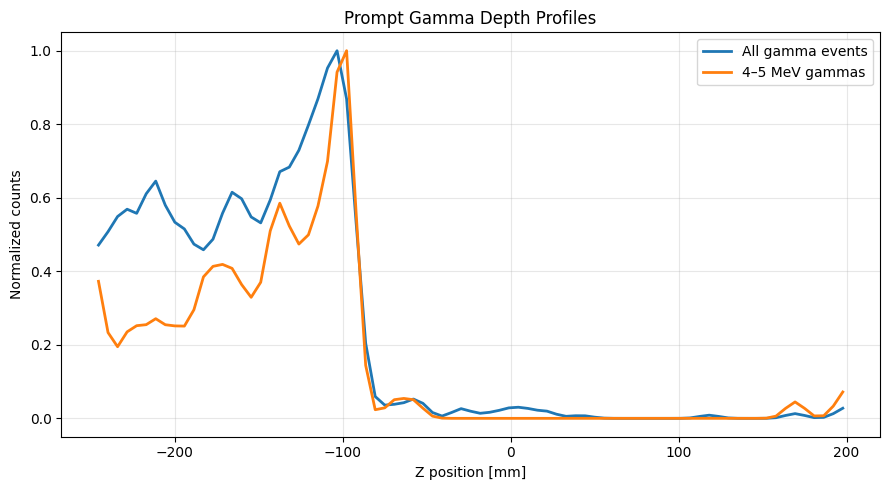

In [90]:
# ==================================================
# USE SAME Z-BINS AS 4.4 MeV CASE
# ==================================================
N_BINS = 80
SMOOTH_SIGMA = 1.0

# ---- Define PHYSICAL bins from 4.4 MeV gammas ----
bins = np.linspace(z_44.min(), z_44.max(), N_BINS)
centers = 0.5 * (bins[:-1] + bins[1:])

# ==================================================
# ALL GAMMAS PROFILE (FIXED)
# ==================================================
counts_all, _ = np.histogram(z_all, bins=bins)
counts_all = gaussian_filter1d(counts_all.astype(float), SMOOTH_SIGMA)
counts_all /= counts_all.max()

# ==================================================
# 4.4 MeV GAMMAS PROFILE (REFERENCE)
# ==================================================
counts_44, _ = np.histogram(z_44, bins=bins)
counts_44 = gaussian_filter1d(counts_44.astype(float), SMOOTH_SIGMA)
counts_44 /= counts_44.max()

# ==================================================
# PLOT GAMMAS ONLY (CORRECT AXIS)
# ==================================================
plt.figure(figsize=(9,5))

plt.plot(centers, counts_all, label="All gamma events", linewidth=2)
plt.plot(centers, counts_44, label="4–5 MeV gammas", linewidth=2)

plt.xlabel("Z position [mm]")
plt.ylabel("Normalized counts")
plt.title("Prompt Gamma Depth Profiles")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


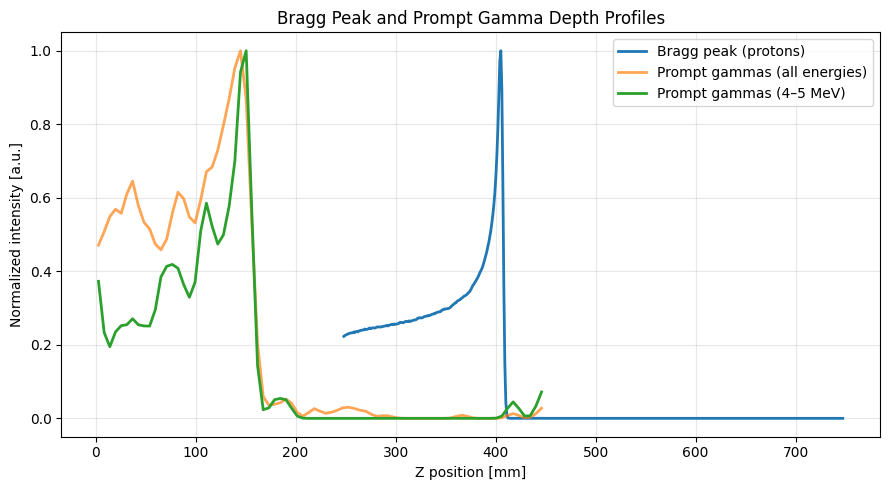

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ==================================================
# PARAMETERS
# ==================================================
N_BINS = 80
SMOOTH_SIGMA = 1.0
dz_mm = 1.0

# ==================================================
# LOAD BRAGG PEAK
# ==================================================
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"

bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX","iY","iZ","Edep_MeV","Edep2","Entries"]
)

bragg_z = bragg_df["iZ"].values * dz_mm
bragg_dose = bragg_df["Edep_MeV"].values
bragg_norm = bragg_dose / bragg_dose.max()

# ==================================================
# USE SAME Z-BINS AS 4.4 MeV GAMMAS
# ==================================================
bins = np.linspace(z_44.min(), z_44.max(), N_BINS)
centers = 0.5 * (bins[:-1] + bins[1:])

# ==================================================
# ALL GAMMAS PROFILE
# ==================================================
counts_all, _ = np.histogram(z_all, bins=bins)
counts_all = gaussian_filter1d(counts_all.astype(float), SMOOTH_SIGMA)
counts_all /= counts_all.max()

# ==================================================
# 4–5 MeV GAMMAS PROFILE
# ==================================================
counts_44, _ = np.histogram(z_44, bins=bins)
counts_44 = gaussian_filter1d(counts_44.astype(float), SMOOTH_SIGMA)
counts_44 /= counts_44.max()

# ==================================================
# ALIGN BRAGG Z TO GAMMA Z AXIS
# ==================================================
z_ref = bins.min()          # same reference as gamma profiles
bragg_z_aligned = bragg_z - z_ref

# Gamma centers already in same reference frame
gamma_z = centers - z_ref

# ==================================================
# PLOT: BRAGG + GAMMAS
# ==================================================
plt.figure(figsize=(9,5))

plt.plot(
    bragg_z_aligned,
    bragg_norm,
    label="Bragg peak (protons)",
    linewidth=2
)

plt.plot(
    gamma_z,
    counts_all,
    label="Prompt gammas (all energies)",
    linewidth=2,
    alpha=0.7
)

plt.plot(
    gamma_z,
    counts_44,
    label="Prompt gammas (4–5 MeV)",
    linewidth=2
)

plt.xlabel("Z position [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Bragg Peak and Prompt Gamma Depth Profiles")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


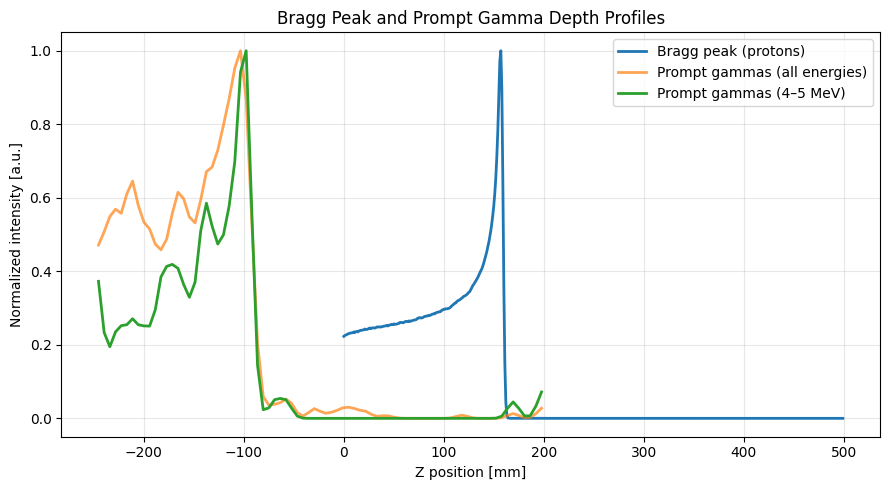

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ==================================================
# PARAMETERS
# ==================================================
N_BINS = 80
SMOOTH_SIGMA = 1.0
dz_mm = 1.0

# ==================================================
# LOAD BRAGG PEAK
# ==================================================
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"

bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX","iY","iZ","Edep_MeV","Edep2","Entries"]
)

bragg_z = bragg_df["iZ"].values * dz_mm
bragg_dose = bragg_df["Edep_MeV"].values
bragg_norm = bragg_dose / bragg_dose.max()

# ==================================================
# USE SAME Z-BINS AS 4.4 MeV GAMMAS
# ==================================================
bins = np.linspace(z_44.min(), z_44.max(), N_BINS)
centers = 0.5 * (bins[:-1] + bins[1:])

# ==================================================
# ALL GAMMAS PROFILE
# ==================================================
counts_all, _ = np.histogram(z_all, bins=bins)
counts_all = gaussian_filter1d(counts_all.astype(float), SMOOTH_SIGMA)
counts_all /= counts_all.max()

# ==================================================
# 4–5 MeV GAMMAS PROFILE
# ==================================================
counts_44, _ = np.histogram(z_44, bins=bins)
counts_44 = gaussian_filter1d(counts_44.astype(float), SMOOTH_SIGMA)
counts_44 /= counts_44.max()

# ==================================================
# ALIGN BRAGG Z TO GAMMA Z AXIS
# ==================================================
# ==================================================
# ALIGN AXES
# ==================================================

# Bragg peak starts at 0
bragg_z_aligned = bragg_z - bragg_z.min()

# Gamma axis unchanged (same as before)
gamma_z = centers

plt.figure(figsize=(9,5))

plt.plot(
    bragg_z_aligned,
    bragg_norm,
    label="Bragg peak (protons)",
    linewidth=2
)

plt.plot(
    gamma_z,
    counts_all,
    label="Prompt gammas (all energies)",
    linewidth=2,
    alpha=0.7
)

plt.plot(
    gamma_z,
    counts_44,
    label="Prompt gammas (4–5 MeV)",
    linewidth=2
)

plt.xlabel("Z position [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Bragg Peak and Prompt Gamma Depth Profiles")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


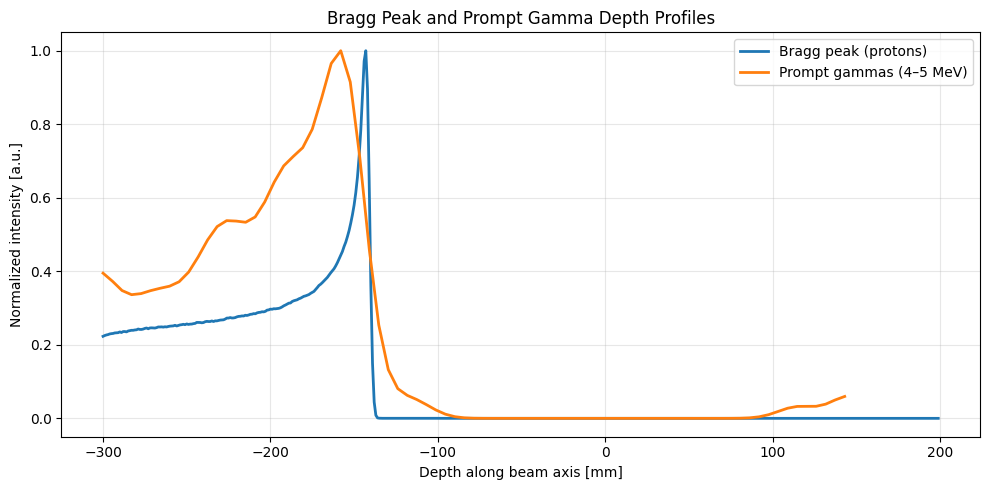

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ==================================================
# FILES
# ==================================================
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"

# ==================================================
# PARAMETERS
# ==================================================
dz_mm = 1.0
BRAGG_START_X = -300.0   # <-- Bragg axis starts at -300 mm

N_BINS = 80
SMOOTH_SIGMA = 2.0

# ==================================================
# LOAD BRAGG PEAK
# ==================================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX","iY","iZ","Edep_MeV","Edep2","Entries"]
)

# Physical depth
bragg_z = bragg_df["iZ"].values * dz_mm
bragg = bragg_df["Edep_MeV"].values
bragg_norm = bragg / bragg.max()

# Align Bragg so it starts at -300 mm
bragg_z = bragg_z - bragg_z.min() + BRAGG_START_X

# ==================================================
# GAMMA BINNING (FROM YOUR WORKING CODE)
# ==================================================
# bins and centers ALREADY DEFINED FROM z_44
# bins = np.linspace(z_44.min(), z_44.max(), N_BINS)
# centers = 0.5 * (bins[:-1] + bins[1:])

# --------------------------------------------------
# ALL GAMMAS
# --------------------------------------------------
counts_all, _ = np.histogram(z_all, bins=bins)
counts_all = gaussian_filter1d(counts_all.astype(float), SMOOTH_SIGMA)
counts_all /= counts_all.max()

# --------------------------------------------------
# 4–5 MeV GAMMAS
# --------------------------------------------------
counts_44, _ = np.histogram(z_44, bins=bins)
counts_44 = gaussian_filter1d(counts_44.astype(float), SMOOTH_SIGMA)
counts_44 /= counts_44.max()

START_X = -300.0

# Shift gamma axis
centers_shifted = centers - centers.min() + START_X

# Shift Bragg axis
bragg_z_shifted = bragg_z - bragg_z.min() + START_X


# ==================================================
# PLOT: BRAGG + GAMMAS
# ==================================================
plt.figure(figsize=(10,5))

plt.plot(
    bragg_z_shifted,
    bragg_norm,
    label="Bragg peak (protons)",
    linewidth=2
)

#plt.plot(
   # centers_shifted,
    #counts_all,
   # label="Prompt gammas (all energies)",
   # linewidth=2,
   # alpha=0.7
#)

plt.plot(
    centers_shifted,
    counts_44,
    label="Prompt gammas (4–5 MeV)",
    linewidth=2
)

plt.xlabel("Depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Bragg Peak and Prompt Gamma Depth Profiles")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


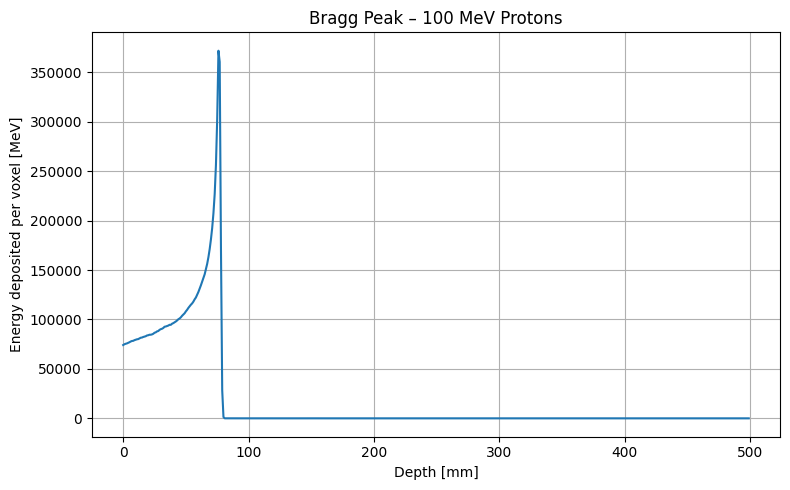

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Correct file path
# --------------------------------------------------
file_path = "/home/meenakshi/bragg-peak/DATA_1/100.000000-MEV-100000-EVTS_protons.txt"

# --------------------------------------------------
# Read Bragg peak data
# --------------------------------------------------
df = pd.read_csv(
    file_path,
    comment="#",
    header=None,
    names=["iX_mm", "iY_mm", "iZ_mm", "Edep_MeV", "Edep2", "Entries"]
)

# --------------------------------------------------
# Shift x-axis (start around 0)
# --------------------------------------------------
depth_shifted = df["iZ_mm"] - 0.0
energy_dep = df["Edep_MeV"]

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(depth_shifted, energy_dep)
plt.xlabel("Depth [mm]")
plt.ylabel("Energy deposited per voxel [MeV]")
plt.title("Bragg Peak – 100 MeV Protons")
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
import numpy as np

depth = df["iZ_mm"].values - 0.0   # same shift as your plot
dose  = df["Edep_MeV"].values

peak_idx = np.argmax(dose)
range_peak = depth[peak_idx]

print(f"Bragg peak range (peak position): {range_peak:.2f} mm")


Bragg peak range (peak position): 76.00 mm


In [12]:
# Normalize dose
dose_norm = dose / dose.max()

# Find peak
peak_idx = np.argmax(dose_norm)

# Look only on distal side
depth_distal = depth[peak_idx:]
dose_distal  = dose_norm[peak_idx:]

# Find R80
R80_idx = np.where(dose_distal <= 0.8)[0][0]
range_R80 = depth_distal[R80_idx]

print(f"Proton range R80: {range_R80:.2f} mm")


Proton range R80: 78.00 mm


Number of selected events: 150


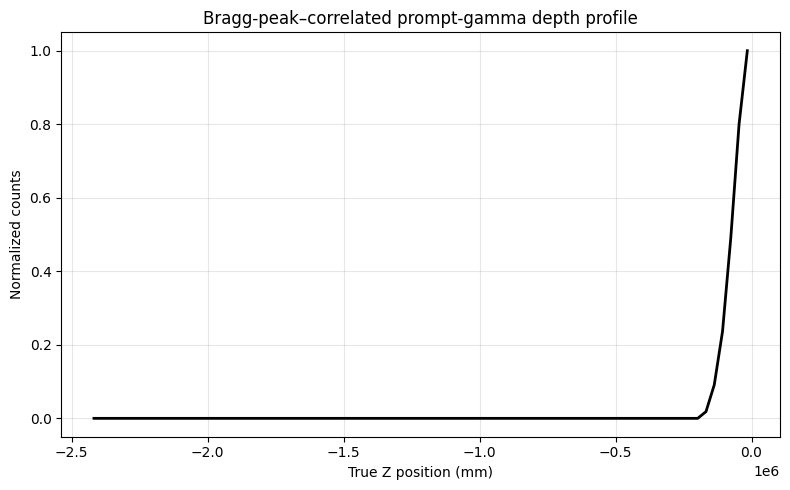

Number of events: 150


In [13]:
import numpy as np
import matplotlib.pyplot as plt

CSV_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100_100000.csv"

TRUE_ENERGY_COL = 11
TRUE_Z_COL = 10

# WIDER energy window (THIS IS THE KEY)
E_MIN = 4.0
E_MAX = 5.0

z_vals = []

with open(CSV_FILE, "r") as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = [p.strip() for p in line.split(",")]
    try:
        E = float(parts[TRUE_ENERGY_COL])
        Z = float(parts[TRUE_Z_COL])

        if E_MIN <= E <= E_MAX:
            z_vals.append(Z)

    except:
        continue
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ----------------------------------
# CONFIGURATION
# ----------------------------------
CSV_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100_100000.csv"

TRUE_ENERGY_COL = 11
TRUE_Z_COL = 10

E_MIN = 3.0   # MeV  (wider window)
E_MAX = 5.0   # MeV

N_BINS = 80
SMOOTH_SIGMA = 2.0   # controls smoothness
# ----------------------------------

z_vals = []

# Read CSV
with open(CSV_FILE, "r") as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = [p.strip() for p in line.split(",")]
    try:
        E = float(parts[TRUE_ENERGY_COL])
        Z = float(parts[TRUE_Z_COL])

        if E_MIN <= E <= E_MAX:
            z_vals.append(Z)

    except:
        continue

z_vals = np.array(z_vals)

print("Number of selected events:", len(z_vals))

# Histogram
counts, edges = np.histogram(z_vals, bins=N_BINS)
centers = 0.5 * (edges[:-1] + edges[1:])

# Smooth histogram
counts_smooth = gaussian_filter1d(counts, sigma=SMOOTH_SIGMA)

# Normalize
counts_smooth = counts_smooth / counts_smooth.max()

# Plot smooth curve ONLY
plt.figure(figsize=(8, 5))

plt.plot(
    centers,
    counts_smooth,
    color="black",
    linewidth=2
)

plt.xlabel("True Z position (mm)")
plt.ylabel("Normalized counts")
plt.title("Bragg-peak–correlated prompt-gamma depth profile")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Number of events:", len(z_vals))

# Histogram
#bins = np.linspace(min(z_vals), max(z_vals), 50)
#counts, edges = np.histogram(z_vals, bins=bins)
#centers = 0.5 * (edges[:-1] + edges[1:])

# Normalize (like paper)
#counts = counts / counts.max()

#plt.figure(figsize=(8, 5))
#plt.plot(centers, counts, drawstyle="steps-mid", linewidth=2)

#plt.xlabel("True Z position (mm)")
#plt.ylabel("Normalized counts")
#plt.title("Bragg-peak-correlated depth profile (3–5 MeV gammas)")
#plt.grid(alpha=0.3)
#plt.tight_layout()
#plt.show()


In [15]:
# ==================================================
# FILE
# ==================================================
CSV_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100_100000.csv"

# ==================================================
# COLUMN INDICES (from your working setup)
# ==================================================
TRUE_Z_COL = 10        # Z position (not strictly needed for counting)
TRUE_ENERGY_COL = 11  # Gamma energy [MeV]

# ==================================================
# ENERGY WINDOW
# ==================================================
E_MIN = 4.0
E_MAX = 5.0

# ==================================================
# COUNT 4–5 MeV GAMMAS
# ==================================================
count_44 = 0

with open(CSV_FILE, "r") as f:
    lines = f.readlines()

for line in lines[1:]:   # skip header
    parts = [p.strip() for p in line.split(",")]
    try:
        E = float(parts[TRUE_ENERGY_COL])
        if E_MIN <= E <= E_MAX:
            count_44 += 1
    except:
        continue

print(f"Number of 4–5 MeV gamma events: {count_44}")


Number of 4–5 MeV gamma events: 99


In [29]:
CSV_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100_100000.csv"

with open(CSV_FILE, "r") as f:
    for i in range(5):
        print(f.readline())


Event_ID, Track_ID, Detector, Pos_X_mm, Pos_Y_mm, Pos_Z_mm, Energy_MeV ,Deposited_MeV, True_Origin_X_mm, True_Origin_Y_mm, True_Origin_Z_mm, Initial_Energy_MeV, Detector_Num

424,     7,    CylDetector,  64.577850,  -7.396036,  -184.275900,  0.710439,  0.000000, -2.537093,  -11.325494,  -182.385478,  0.973848,  1

424,     7,    CylDetector2,  70.239739,  -6.052200,  -184.784770,  0.710439,  0.000000, -2.537093,  -11.325494,  -182.385478,  0.973848,  3019,     7,    CylDetector,  63.949037,  11.641334,  -141.874062,  0.099669,  0.000000, -13.321896,  -20.329225,  -188.247673,  0.251760,  1

3019,     7,    CylDetector2,  69.693044,  10.636238,  -139.575083,  0.099669,  0.000000, -13.321896,  -20.329225,  -188.247673,  0.251760,  2

3019,     6,    CylDetector,  41.693589,  -49.866268,  -213.314836,  1.535308,  0.000000, -13.321896,  -20.329225,  -188.247673,  1.535308,  1



In [30]:
import csv

# ==================================================
# INPUT FILE
# ==================================================
INPUT_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100_100000.csv"

# ==================================================
# OUTPUT FILES
# ==================================================
OUT_TRUE_FILE = "gamma_4p4MeV_trueZ_energy.csv"
OUT_HIT_FILE  = "gamma_4p4MeV_hitZ_energy.csv"

# ==================================================
# COLUMN INDICES
# ==================================================
TRUE_Z_COL      = 10
TRUE_ENERGY_COL = 11
HIT_Z_COL       = 3     # <-- change if your hit-Z column differs

# ==================================================
# ENERGY WINDOW (4.4 MeV line)
# ==================================================
E_MIN = 4.0
E_MAX = 5.0

# ==================================================
# OPEN OUTPUT FILES
# ==================================================
with open(INPUT_FILE, "r") as fin, \
     open(OUT_TRUE_FILE, "w", newline="") as ftrue, \
     open(OUT_HIT_FILE,  "w", newline="") as fhit:

    reader = csv.reader(fin)
    true_writer = csv.writer(ftrue)
    hit_writer  = csv.writer(fhit)

    # Write headers
    true_writer.writerow(["True_Z_mm", "Gamma_Energy_MeV"])
    hit_writer.writerow(["Hit_Z_mm", "Gamma_Energy_MeV"])

    next(reader)  # skip header

    true_count = 0
    hit_count  = 0

    for row in reader:
        try:
            E = float(row[TRUE_ENERGY_COL])

            if E_MIN <= E <= E_MAX:
                true_z = float(row[TRUE_Z_COL])
                hit_z  = float(row[HIT_Z_COL])

                true_writer.writerow([true_z, E])
                hit_writer.writerow([hit_z,  E])

                true_count += 1
                hit_count  += 1

        except:
            continue

print("CSV files created successfully!")
print("4–5 MeV gamma events saved:", true_count)
print("Output files:")
print(" -", OUT_TRUE_FILE)
print(" -", OUT_HIT_FILE)


CSV files created successfully!
4–5 MeV gamma events saved: 99
Output files:
 - gamma_4p4MeV_trueZ_energy.csv
 - gamma_4p4MeV_hitZ_energy.csv


Number of 4–5 MeV gammas: 99
Z range: -2433317.0 to -148.412234


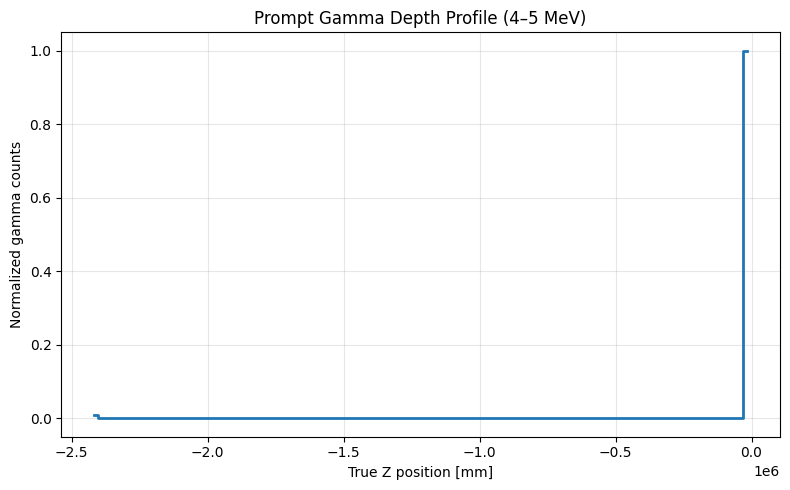

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# INPUT FILE
# ==================================================
CSV_FILE = "gamma_4p4MeV_trueZ_energy.csv"

# ==================================================
# READ CSV
# ==================================================
df = pd.read_csv(CSV_FILE)

z_vals = df["True_Z_mm"].values

print("Number of 4–5 MeV gammas:", len(z_vals))
print("Z range:", z_vals.min(), "to", z_vals.max())

# ==================================================
# BUILD DEPTH PROFILE
# ==================================================
N_BINS = 80

counts, edges = np.histogram(z_vals, bins=N_BINS)
centers = 0.5 * (edges[:-1] + edges[1:])

# Normalize counts
counts_norm = counts / counts.max()

# ==================================================
# PLOT PROMPT GAMMA DEPTH PROFILE
# ==================================================
plt.figure(figsize=(8,5))

plt.plot(
    centers,
    counts_norm,
    drawstyle="steps-mid",
    linewidth=2
)

plt.xlabel("True Z position [mm]")
plt.ylabel("Normalized gamma counts")
plt.title("Prompt Gamma Depth Profile (4–5 MeV)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Number of gamma events: 99
Z range: -2433317.0 to -148.412234


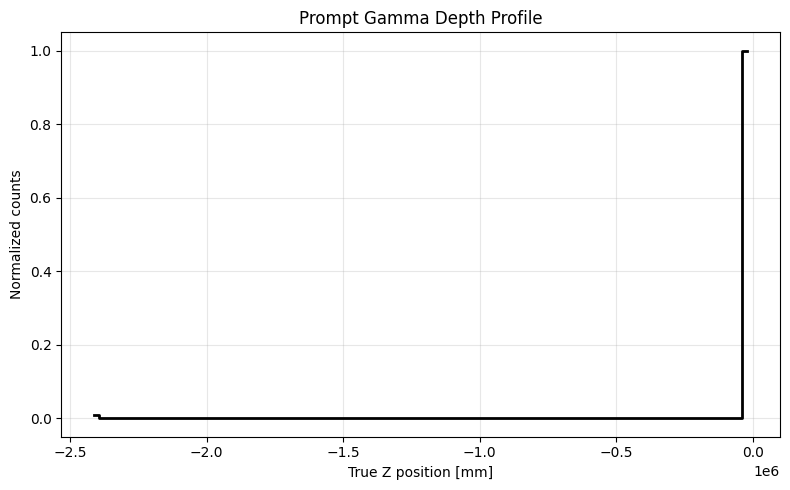

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# INPUT CSV
# ==================================================
CSV_FILE = "gamma_4p4MeV_trueZ_energy.csv"

# ==================================================
# READ DATA
# ==================================================
df = pd.read_csv(CSV_FILE)

z = df["True_Z_mm"].values

print("Number of gamma events:", len(z))
print("Z range:", z.min(), "to", z.max())

# ==================================================
# BUILD DEPTH PROFILE
# ==================================================
N_BINS = 60   # you can change this

counts, edges = np.histogram(z, bins=N_BINS)
centers = 0.5 * (edges[:-1] + edges[1:])

# Normalize counts
counts_norm = counts / counts.max()

# ==================================================
# PLOT
# ==================================================
plt.figure(figsize=(8, 5))

plt.plot(
    centers,
    counts_norm,
    drawstyle="steps-mid",
    linewidth=2,
    color="black"
)

plt.xlabel("True Z position [mm]")
plt.ylabel("Normalized counts")
plt.title("Prompt Gamma Depth Profile")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


In [33]:
import pandas as pd
import numpy as np

df = pd.read_csv("gamma_4p4MeV_trueZ_energy.csv")

z = df["True_Z_mm"].values

print("Raw Z range:", z.min(), z.max())


Raw Z range: -2433317.0 -148.412234


In [34]:
z_center = 0.5 * (z.min() + z.max())
z_physical = z - z_center


In [35]:
mask = (z_physical >= -350) & (z_physical <= 350)
z_physical = z_physical[mask]


GAMMA DEPTH PROFILE (4-5 MeV)

1. Loading CSV file: your_file.csv
✗ ERROR: File 'your_file.csv' not found!

2. Extracting Z positions and energies...
   Using column 'True_Z_mm' for Z position
   Using column 'Gamma_Energy_MeV' for energy
   Z position range: -2433317.00 to -148.41 mm
   Number of gamma rays: 99
   Energy range: 4.000 to 4.970 MeV
   Mean energy: 4.459 MeV
   ✓ Energy range confirmed: 4-5 MeV

3. Creating depth profile...
   Depth range: -2433317.00 to -148.41 mm
   Bin size: 30414.61 mm
   Total counts: 99
   Maximum bin count: 98
   Applied Gaussian smoothing (sigma=2.0)
   Normalized to maximum value
   X-axis shifted to start at -300.0 mm

4. Creating gamma depth profile plot...
✓ Plot saved as: gamma_depth_profile_4_5_MeV_100.png


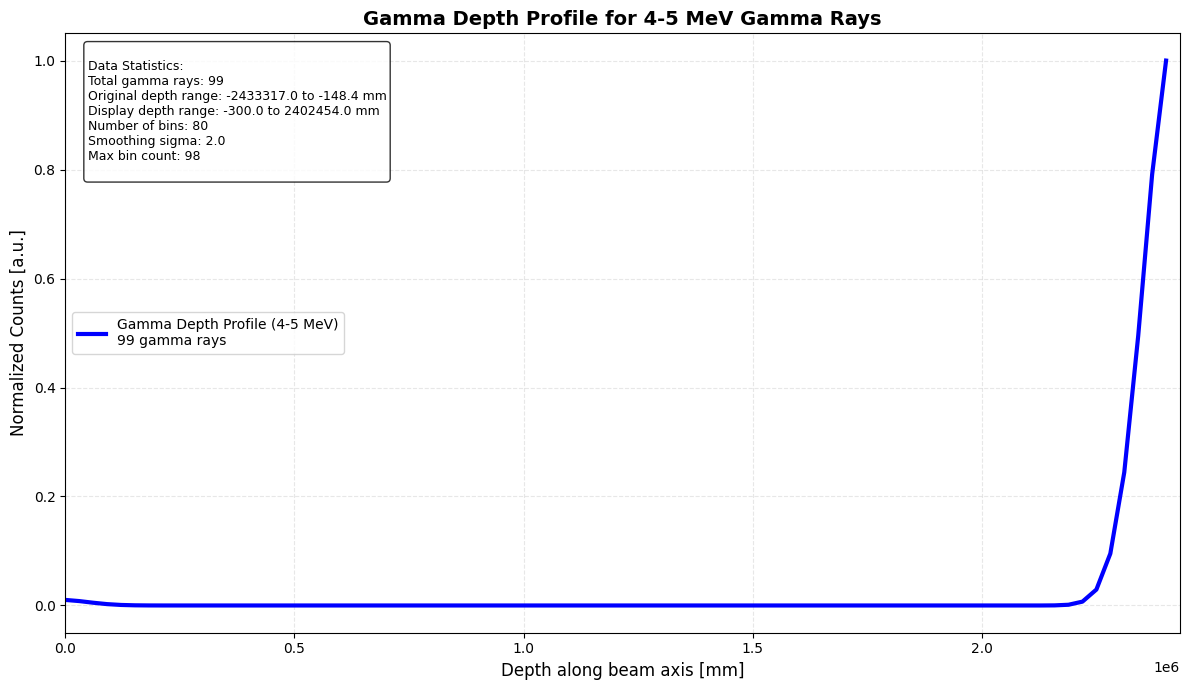

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ==================================================
# CONFIGURATION
# ==================================================
CSV_FILE = "your_file.csv"  # Update with your CSV file path
Z_COLUMN = "True_Origin_Z_mm"  # Column name for true Z position
ENERGY_COLUMN = "Initial_Energy_MeV"  # Column name for energy (for verification)

# Binning parameters
N_BINS = 80  # Number of depth bins
SMOOTH_SIGMA = 2.0  # Sigma for Gaussian smoothing
START_X = -300.0  # Shift x-axis to start at -300 mm
# ==================================================

print("="*60)
print("GAMMA DEPTH PROFILE (4-5 MeV)")
print("="*60)

# 1. LOAD CSV DATA
print(f"\n1. Loading CSV file: {CSV_FILE}")
try:
    df = pd.read_csv(CSV_FILE)
    print(f"   ✓ File loaded successfully")
    print(f"   ✓ Shape: {df.shape} rows × {df.shape[1]} columns")
except FileNotFoundError:
    print(f"✗ ERROR: File '{CSV_FILE}' not found!")
    exit()

# 2. EXTRACT DATA
print(f"\n2. Extracting Z positions and energies...")

# Get Z positions
if Z_COLUMN in df.columns:
    z_data = df[Z_COLUMN].values
else:
    # Try to find Z column automatically
    z_candidates = [col for col in df.columns if 'z' in col.lower() or 'depth' in col.lower()]
    if z_candidates:
        Z_COLUMN = z_candidates[0]
        z_data = df[Z_COLUMN].values
        print(f"   Using column '{Z_COLUMN}' for Z position")
    else:
        print(f"✗ ERROR: No Z position column found!")
        exit()

# Get energies (for verification only)
if ENERGY_COLUMN in df.columns:
    energies = df[ENERGY_COLUMN].values
else:
    # Try to find energy column automatically
    energy_candidates = [col for col in df.columns if 'energy' in col.lower()]
    if energy_candidates:
        ENERGY_COLUMN = energy_candidates[0]
        energies = df[ENERGY_COLUMN].values
        print(f"   Using column '{ENERGY_COLUMN}' for energy")
    else:
        energies = None
        print(f"   Note: No energy column found")

print(f"   Z position range: {z_data.min():.2f} to {z_data.max():.2f} mm")
print(f"   Number of gamma rays: {len(z_data):,}")

if energies is not None:
    print(f"   Energy range: {energies.min():.3f} to {energies.max():.3f} MeV")
    print(f"   Mean energy: {energies.mean():.3f} MeV")
    
    # Verify energy is in 4-5 MeV range
    if energies.min() >= 4.0 and energies.max() <= 5.0:
        print(f"   ✓ Energy range confirmed: 4-5 MeV")
    else:
        print(f"   ⚠ Warning: Energy range is {energies.min():.2f}-{energies.max():.2f} MeV")
        print(f"   Expected: 4-5 MeV")

# 3. CREATE DEPTH PROFILE
print(f"\n3. Creating depth profile...")

# Create bins
z_min = z_data.min()
z_max = z_data.max()
bins = np.linspace(z_min, z_max, N_BINS + 1)
centers = 0.5 * (bins[:-1] + bins[1:])

# Create histogram
counts, _ = np.histogram(z_data, bins=bins)

print(f"   Depth range: {z_min:.2f} to {z_max:.2f} mm")
print(f"   Bin size: {(z_max - z_min)/N_BINS:.2f} mm")
print(f"   Total counts: {counts.sum():,}")
print(f"   Maximum bin count: {counts.max():,}")

# Apply smoothing
if SMOOTH_SIGMA > 0:
    counts_smooth = gaussian_filter1d(counts.astype(float), SMOOTH_SIGMA)
    print(f"   Applied Gaussian smoothing (sigma={SMOOTH_SIGMA})")
else:
    counts_smooth = counts.astype(float)

# Normalize to maximum
counts_normalized = counts_smooth / counts_smooth.max()
print(f"   Normalized to maximum value")

# Shift x-axis to start at START_X
centers_shifted = centers - centers.min() + START_X
print(f"   X-axis shifted to start at {START_X} mm")

# 4. CREATE THE MAIN PLOT
print(f"\n4. Creating gamma depth profile plot...")

plt.figure(figsize=(12, 7))

# Plot the depth profile
plt.plot(centers_shifted, counts_normalized, 
         linewidth=3, color='blue', 
         label=f'Gamma Depth Profile (4-5 MeV)\n{len(z_data):,} gamma rays')

# Add labels and title
plt.xlabel("Depth along beam axis [mm]", fontsize=12)
plt.ylabel("Normalized Counts [a.u.]", fontsize=12)
plt.title("Gamma Depth Profile for 4-5 MeV Gamma Rays", 
          fontsize=14, fontweight='bold')

# Add grid
plt.grid(True, alpha=0.3, linestyle='--')

# Add statistics box
stats_text = f"""
Data Statistics:
Total gamma rays: {len(z_data):,}
Original depth range: {z_min:.1f} to {z_max:.1f} mm
Display depth range: {centers_shifted.min():.1f} to {centers_shifted.max():.1f} mm
Number of bins: {N_BINS}
Smoothing sigma: {SMOOTH_SIGMA}
Max bin count: {counts.max():,}
"""

plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
         fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Set x-limits
plt.xlim(START_X, START_X + (z_max - z_min))

# Add legend
plt.legend(loc='best', fontsize=10)

plt.tight_layout()

# Save the plot
output_file = "gamma_depth_profile_4_5_MeV_100.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✓ Plot saved as: {output_file}")
plt.show()

# 5. CREATE COMPARISON WITH PROTON BRAGG PEAK (OPTIONAL)
#print(f"\n5. Optional: Load proton Bragg peak for comparison...")

# If you have proton Bragg data in the same format as before
#PROTON_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"

#try:
    # Load proton Bragg peak (using your previous code structure)
   # bragg_df = pd.read_csv(
     #   PROTON_FILE,
      #  comment="#",
      #  header=None,
      #  names=["iX","iY","iZ","Edep_MeV","Edep2","Entries"]
    #)
    
    # Process proton data
   # dz_mm = 1.0
  #  bragg_z = bragg_df["iZ"].values * dz_mm
   # bragg = bragg_df["Edep_MeV"].values
   # bragg_norm = bragg / bragg.max()
   # bragg_z_shifted = bragg_z - bragg_z.min() + START_X
    
  #  print(f"   ✓ Proton Bragg peak loaded: {len(bragg_z):,} points")
    
    # Create comparison plot
    #plt.figure(figsize=(12, 7))
    
    # Plot proton Bragg peak
   # plt.plot(bragg_z_shifted, bragg_norm, 
        #     linewidth=3, color='red', alpha=0.8,
       #      label='Proton Bragg Peak (150 MeV)')
    
    # Plot gamma depth profile
   # plt.plot(centers_shifted, counts_normalized, 
           #  linewidth=3, color='blue', alpha=0.8,
            # label=f'Gamma Depth Profile (4-5 MeV)\n{len(z_data):,} gamma rays')
    
   # plt.xlabel("Depth along beam axis [mm]", fontsize=12)
    #plt.ylabel("Normalized Intensity [a.u.]", fontsize=12)
    #plt.title("Comparison: Proton Bragg Peak vs Gamma Depth Profile", 
       #       fontsize=14, fontweight='bold')
   # plt.grid(True, alpha=0.3, linestyle='--')
   # plt.legend(loc='best', fontsize=10)
    #plt.xlim(START_X, START_X + (z_max - z_min))
    
    #plt.tight_layout()
    
    #output_comparison = "proton_bragg_vs_gamma_depth.png"
    #plt.savefig(output_comparison, dpi=300, bbox_inches='tight')
   # print(f"✓ Comparison plot saved as: {output_comparison}")
    
   # plt.show()
    
#except Exception as e:
  #  print(f"   Note: Could not load proton data for comparison: {e}")
#
# 6. SAVE PROCESSED DATA
#print(f"\n6. Saving processed data...")

# Save binned data to CSV
#binned_data = pd.DataFrame({
#    'Original_Z_Center_mm': centers,
 #   'Shifted_Z_Center_mm': centers_shifted,
 ###   'Smoothed_Counts': counts_smooth,
  #  'Normalized_Counts': counts_normalized
#})

#output_csv = "gamma_depth_profile_4_5_MeV_binned.csv"
#binned_data.to_csv(output_csv, index=False)
#print(f"✓ Binned data saved as: {output_csv}")

# Save summary statistics
#summary_stats = {
  #  'Total_Gamma_Rays': len(z_data),
   # 'Z_Min_mm': z_min,
    #'Z_Max_mm': z_max,
   ### 'Bin_Size_mm': (z_max - z_min) / N_BINS,
    #'Smoothing_Sigma': SMOOTH_SIGMA,
    #'Max_Raw_Count': int(counts.max()),
   # 'Total_Raw_Counts': int(counts.sum())
#}

#if energies is not None:
 #   summary_stats['Energy_Min_MeV'] = energies.min()
 #   summary_stats['Energy_Max_MeV'] = energies.max()
  #  summary_stats['Energy_Mean_MeV'] = energies.mean()

#summary_df = pd.DataFrame([summary_stats])
#summary_csv = "gamma_depth_profile_summary.csv"
#summary_df.to_csv(summary_csv, index=False)
#print(f"✓ Summary statistics saved as: {summary_csv}")

# 7. PRINT FINAL SUMMARY
#print(f"\n" + "="*60)
#print("ANALYSIS COMPLETE")
#print("="*60)
#print(f"Input file: {CSV_FILE}")
#print(f"Gamma rays analyzed: {len(z_data):,}")
#if energies is not None:
 #   print(f"Energy range: {energies.min():.3f} - {energies.max():.3f} MeV")
#print(f"Depth range: {z_min:.2f} - {z_max:.2f} mm")
#print(f"Bin size: {(z_max - z_min)/N_BINS:.2f} mm")
#print(f"\nOutput files generated:")
#print(f"1. {output_file} (gamma depth profile plot)")
#print(f"2. {output_csv} (binned depth profile data)")
#print(f"3. {summary_csv} (summary statistics)")
#if 'output_comparison' in locals():
  #  print(f"4. {output_comparison} (comparison with proton Bragg peak)")
#print("="*60)

Number of gamma events: 98
Z range used: -244.551446 to -148.412234


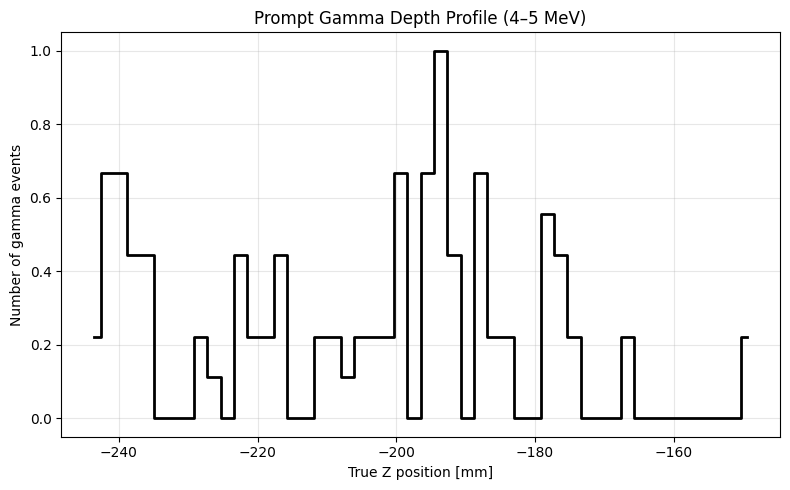

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# INPUT FILE
# =====================================
CSV_FILE = "gamma_4p4MeV_trueZ_energy.csv"

# =====================================
# READ DATA
# =====================================
df = pd.read_csv(CSV_FILE)

z = df["True_Z_mm"].values

# -------------------------------------
# KEEP ONLY PHYSICAL Z RANGE
# (based on your statement: -244 is real)
# -------------------------------------
z = z[(z >= -350) & (z <= 350)]

print("Number of gamma events:", len(z))
print("Z range used:", z.min(), "to", z.max())

# =====================================
# HISTOGRAM (COUNTS ONLY)
# =====================================
N_BINS = 50

counts, edges = np.histogram(z, bins=N_BINS)
centers = 0.5 * (edges[:-1] + edges[1:])

# =====================================
# PLOT
# =====================================
plt.figure(figsize=(8,5))
counts = counts / counts.max()


plt.plot(
    centers,
    counts,
    drawstyle="steps-mid",
    linewidth=2,
    color="black"
)

plt.xlabel("True Z position [mm]")
plt.ylabel("Number of gamma events")
plt.title("Prompt Gamma Depth Profile (4–5 MeV)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Number of gamma events: 98
Z range: -244.551446 to -148.412234


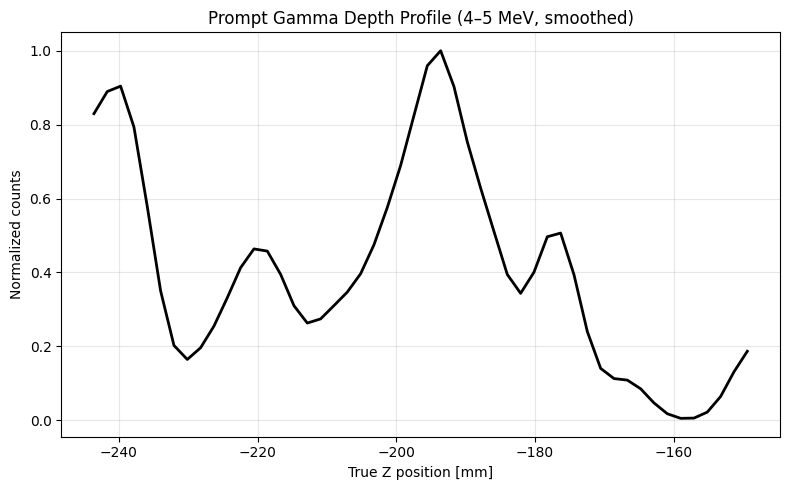

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# =====================================
# INPUT FILE
# =====================================
CSV_FILE = "gamma_4p4MeV_trueZ_energy.csv"

# =====================================
# READ DATA
# =====================================
df = pd.read_csv(CSV_FILE)
z = df["True_Z_mm"].values

# Keep only physical detector region
z = z[(z >= -350) & (z <= 350)]

print("Number of gamma events:", len(z))
print("Z range:", z.min(), "to", z.max())

# =====================================
# HISTOGRAM
# =====================================
N_BINS = 50

counts, edges = np.histogram(z, bins=N_BINS)
centers = 0.5 * (edges[:-1] + edges[1:])

# =====================================
# LIGHT SMOOTHING (THIS IS THE KEY)
# =====================================
SMOOTH_SIGMA = 1.6   # small value → no broadening
counts_smooth = gaussian_filter1d(counts.astype(float), sigma=SMOOTH_SIGMA)

# =====================================
# PLOT
# =====================================
plt.figure(figsize=(8,5))
counts_smooth /= counts_smooth.max()

plt.plot(
    centers,
    counts_smooth,
    linewidth=2,
    color="black"
)

plt.xlabel("True Z position [mm]")
plt.ylabel("Normalized counts")
plt.title("Prompt Gamma Depth Profile (4–5 MeV, smoothed)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Number of gamma events: 98
Z range: -244.551446 to -148.412234


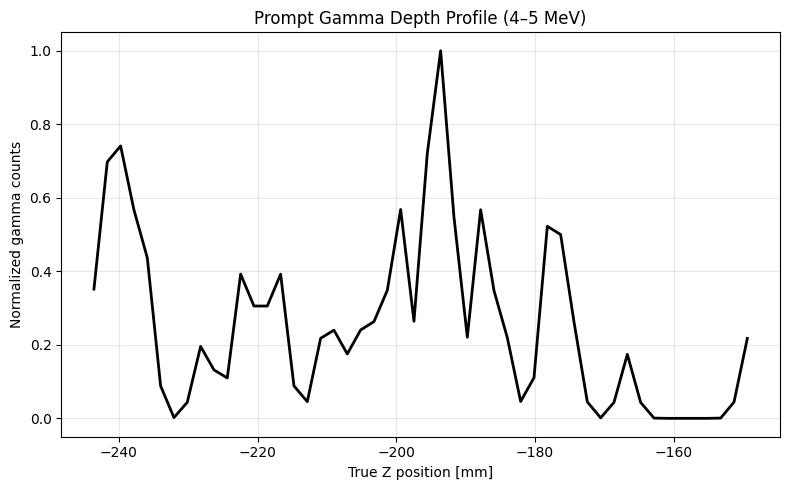

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# =====================================
# INPUT FILE
# =====================================
CSV_FILE = "gamma_4p4MeV_trueZ_energy.csv"

# =====================================
# READ DATA
# =====================================
df = pd.read_csv(CSV_FILE)
z = df["True_Z_mm"].values

# Keep only physical detector range
z = z[(z >= -350) & (z <= 350)]

print("Number of gamma events:", len(z))
print("Z range:", z.min(), "to", z.max())

# =====================================
# HISTOGRAM (DEPTH PROFILE)
# =====================================
N_BINS = 50

counts, edges = np.histogram(z, bins=N_BINS)
centers = 0.5 * (edges[:-1] + edges[1:])

# =====================================
# LIGHT SMOOTHING
# =====================================
SMOOTH_SIGMA = 0.6   # gentle smoothing
counts_smooth = gaussian_filter1d(counts.astype(float), sigma=SMOOTH_SIGMA)

# Normalize
counts_smooth /= counts_smooth.max()

# =====================================
# PLOT
# =====================================
plt.figure(figsize=(8,5))

plt.plot(
    centers,
    counts_smooth,
    linewidth=2,
    color="black"
)

plt.xlabel("True Z position [mm]")
plt.ylabel("Normalized gamma counts")
plt.title("Prompt Gamma Depth Profile (4–5 MeV)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


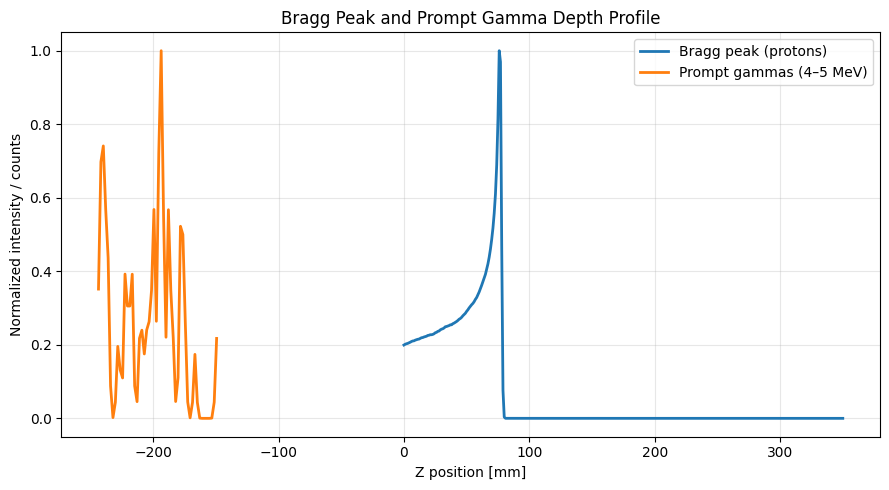

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# =====================================
# INPUT FILES
# =====================================
GAMMA_FILE = "gamma_4p4MeV_trueZ_energy.csv"
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/100.000000-MEV-100000-EVTS_protons.txt"

# =====================================
# -------- GAMMA DEPTH PROFILE --------
# =====================================
df_g = pd.read_csv(GAMMA_FILE)
z_gamma = df_g["True_Z_mm"].values

# Keep only physical region
z_gamma = z_gamma[(z_gamma >= -350) & (z_gamma <= 350)]

# Histogram
N_BINS_G = 50
g_counts, g_edges = np.histogram(z_gamma, bins=N_BINS_G)
g_centers = 0.5 * (g_edges[:-1] + g_edges[1:])

# Light smoothing
g_counts = gaussian_filter1d(g_counts.astype(float), sigma=0.6)
g_counts /= g_counts.max()

# =====================================
# -------- BRAGG PEAK PROFILE ----------
# =====================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX","iY","iZ","Edep_MeV","Edep2","Entries"]
)

z_bragg = bragg_df["iZ"].values
dose = bragg_df["Edep_MeV"].values

# Normalize Bragg peak
dose /= dose.max()

# Optional: keep same Z range for clarity
mask = (z_bragg >= -350) & (z_bragg <= 350)
z_bragg = z_bragg[mask]
dose = dose[mask]

# =====================================
# -------------- PLOT -----------------
# =====================================
plt.figure(figsize=(9,5))

plt.plot(
    z_bragg,
    dose,
    linewidth=2,
    label="Bragg peak (protons)"
)

plt.plot(
    g_centers,
    g_counts,
    linewidth=2,
    label="Prompt gammas (4–5 MeV)"
)

plt.xlabel("Z position [mm]")
plt.ylabel("Normalized intensity / counts")
plt.title("Bragg Peak and Prompt Gamma Depth Profile")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


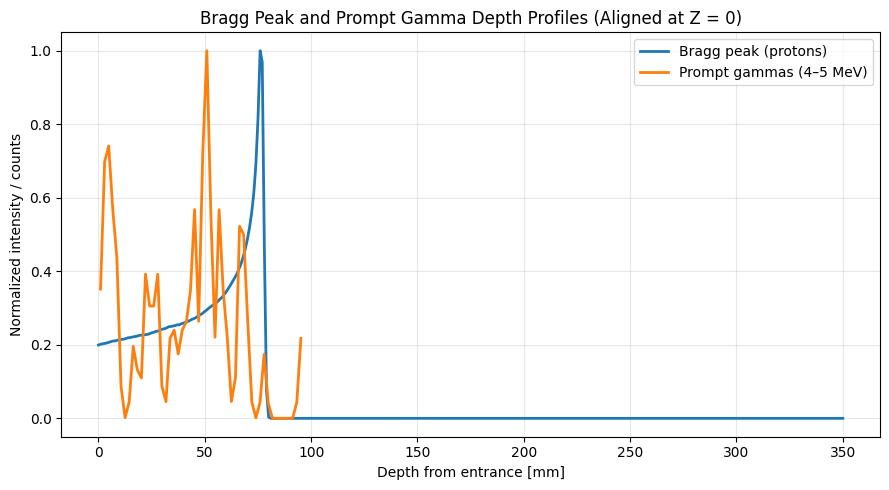

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# =====================================
# INPUT FILES
# =====================================
GAMMA_FILE = "gamma_4p4MeV_trueZ_energy.csv"
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/100.000000-MEV-100000-EVTS_protons.txt"

# =====================================
# -------- GAMMA DEPTH PROFILE --------
# =====================================
df_g = pd.read_csv(GAMMA_FILE)
z_gamma = df_g["True_Z_mm"].values

# Keep physical region
z_gamma = z_gamma[(z_gamma >= -350) & (z_gamma <= 350)]

# Align gamma to start at 0
z_gamma = z_gamma - z_gamma.min()

# Histogram
N_BINS_G = 50
g_counts, g_edges = np.histogram(z_gamma, bins=N_BINS_G)
g_centers = 0.5 * (g_edges[:-1] + g_edges[1:])

# Light smoothing
g_counts = gaussian_filter1d(g_counts.astype(float), sigma=0.6)
g_counts /= g_counts.max()

# =====================================
# -------- BRAGG PEAK PROFILE ----------
# =====================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX","iY","iZ","Edep_MeV","Edep2","Entries"]
)

z_bragg = bragg_df["iZ"].values
dose = bragg_df["Edep_MeV"].values

# Keep same physical region
mask = (z_bragg >= -350) & (z_bragg <= 350)
z_bragg = z_bragg[mask]
dose = dose[mask]

# Align Bragg to start at 0
z_bragg = z_bragg - z_bragg.min()

# Normalize Bragg peak
dose /= dose.max()

# =====================================
# -------------- PLOT -----------------
# =====================================
plt.figure(figsize=(9,5))

plt.plot(
    z_bragg,
    dose,
    linewidth=2,
    label="Bragg peak (protons)"
)

plt.plot(
    g_centers,
    g_counts,
    linewidth=2,
    label="Prompt gammas (4–5 MeV)"
)

plt.xlabel("Depth from entrance [mm]")
plt.ylabel("Normalized intensity / counts")
plt.title("Bragg Peak and Prompt Gamma Depth Profiles (Aligned at Z = 0)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:
# Bragg peak position
bragg_peak_idx = np.argmax(dose)
z_bragg_peak = z_bragg[bragg_peak_idx]

print(f"Bragg peak position: {z_bragg_peak:.2f} mm")


Bragg peak position: 76.00 mm


In [11]:
# Gamma peak position
gamma_peak_idx = np.argmax(g_counts)
z_gamma_peak = g_centers[gamma_peak_idx]

print(f"Gamma peak position: {z_gamma_peak:.2f} mm")


Gamma peak position: 50.95 mm


In [12]:
delta_peak = z_bragg_peak - z_gamma_peak
print(f"Peak shift (Bragg − Gamma): {delta_peak:.2f} mm")


Peak shift (Bragg − Gamma): 25.05 mm


Number of gamma hit events: 99
Z range: -69.83835 to 70.445525


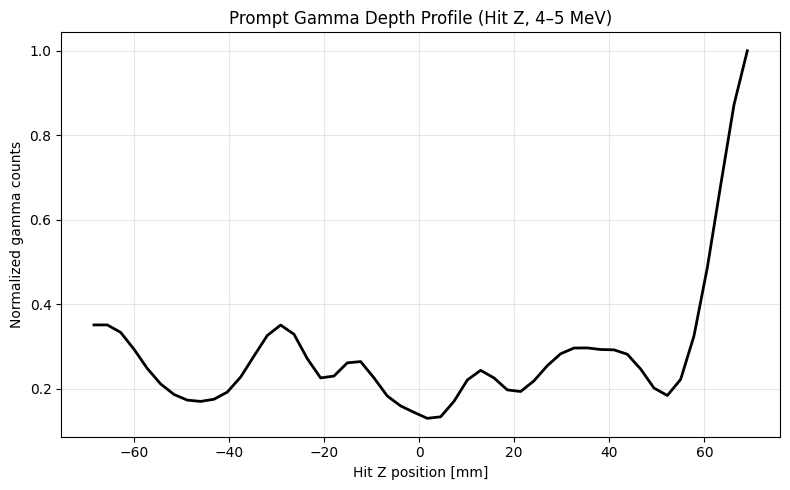

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# =====================================
# INPUT FILE
# =====================================
CSV_FILE = "gamma_4p4MeV_hitZ_energy.csv"

# =====================================
# READ DATA
# =====================================
df = pd.read_csv(CSV_FILE)
z_hit = df["Hit_Z_mm"].values

# Keep only physical detector region (same logic as before)
z_hit = z_hit[(z_hit >= -350) & (z_hit <= 350)]

print("Number of gamma hit events:", len(z_hit))
print("Z range:", z_hit.min(), "to", z_hit.max())

# =====================================
# HISTOGRAM
# =====================================
N_BINS = 50

counts, edges = np.histogram(z_hit, bins=N_BINS)
centers = 0.5 * (edges[:-1] + edges[1:])

# =====================================
# LIGHT SMOOTHING
# =====================================
SMOOTH_SIGMA = 1.6
counts_smooth = gaussian_filter1d(counts.astype(float), sigma=SMOOTH_SIGMA)

# Normalize
counts_smooth /= counts_smooth.max()

# =====================================
# PLOT
# =====================================
plt.figure(figsize=(8,5))

plt.plot(
    centers,
    counts_smooth,
    linewidth=2,
    color="black"
)

plt.xlabel("Hit Z position [mm]")
plt.ylabel("Normalized gamma counts")
plt.title("Prompt Gamma Depth Profile (Hit Z, 4–5 MeV)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


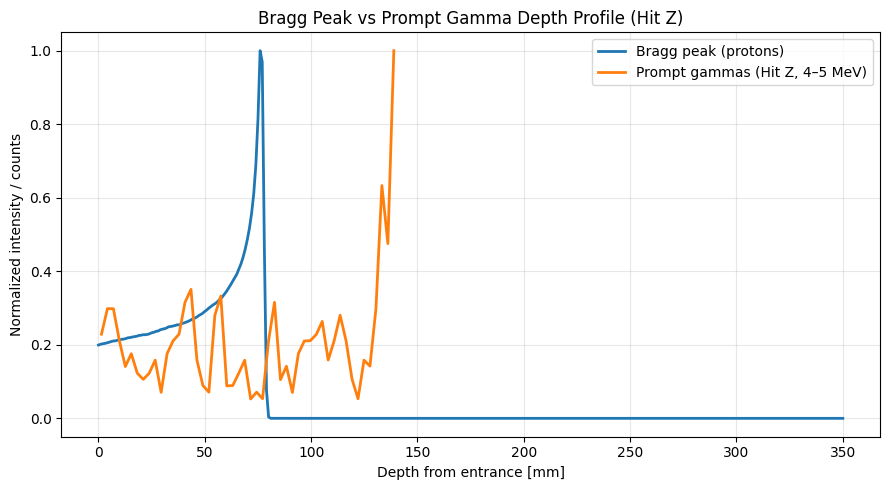

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# =====================================
# INPUT FILES
# =====================================
GAMMA_HIT_FILE = "gamma_4p4MeV_hitZ_energy.csv"
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/100.000000-MEV-100000-EVTS_protons.txt"

# =====================================
# -------- GAMMA HIT-Z PROFILE --------
# =====================================
df_g = pd.read_csv(GAMMA_HIT_FILE)
z_hit = df_g["Hit_Z_mm"].values

# Keep physical detector region
z_hit = z_hit[(z_hit >= -350) & (z_hit <= 350)]

# Align to start at Z = 0
z_hit = z_hit - z_hit.min()

# Histogram
N_BINS = 50
g_counts, g_edges = np.histogram(z_hit, bins=N_BINS)
g_centers = 0.5 * (g_edges[:-1] + g_edges[1:])

# Light smoothing
g_counts = gaussian_filter1d(g_counts.astype(float), sigma=0.6)
g_counts /= g_counts.max()

# =====================================
# -------- BRAGG PEAK PROFILE ----------
# =====================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX","iY","iZ","Edep_MeV","Edep2","Entries"]
)

z_bragg = bragg_df["iZ"].values
dose = bragg_df["Edep_MeV"].values

# Keep same physical region
mask = (z_bragg >= -350) & (z_bragg <= 350)
z_bragg = z_bragg[mask]
dose = dose[mask]

# Align to start at Z = 0
z_bragg = z_bragg - z_bragg.min()

# Normalize dose
dose /= dose.max()

# =====================================
# -------------- PLOT -----------------
# =====================================
plt.figure(figsize=(9,5))

plt.plot(
    z_bragg,
    dose,
    linewidth=2,
    label="Bragg peak (protons)"
)

plt.plot(
    g_centers,
    g_counts,
    linewidth=2,
    label="Prompt gammas (Hit Z, 4–5 MeV)"
)

plt.xlabel("Depth from entrance [mm]")
plt.ylabel("Normalized intensity / counts")
plt.title("Bragg Peak vs Prompt Gamma Depth Profile (Hit Z)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [16]:
# Bragg peak position (range)
bragg_peak_idx = np.argmax(dose)
z_bragg_peak = z_bragg[bragg_peak_idx]

print(f"Bragg peak range (peak position): {z_bragg_peak:.2f} mm")


Bragg peak range (peak position): 76.00 mm


In [17]:
# Gamma peak position (hit Z)
gamma_peak_idx = np.argmax(g_counts)
z_gamma_peak = g_centers[gamma_peak_idx]

print(f"Gamma peak range (hit Z): {z_gamma_peak:.2f} mm")


Gamma peak range (hit Z): 138.88 mm


In [18]:
delta_range = z_bragg_peak - z_gamma_peak
print(f"Peak-based range shift (Bragg − Gamma): {delta_range:.2f} mm")


Peak-based range shift (Bragg − Gamma): -62.88 mm


Gamma counts:
 All energies: 692
 4–5 MeV: 98


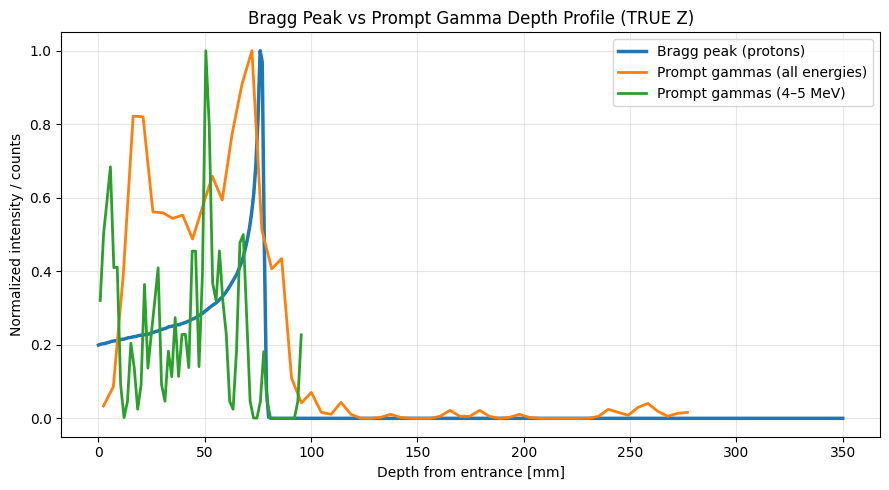

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# =====================================
# FILES
# =====================================
GAMMA_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100_100000.csv"
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/100.000000-MEV-100000-EVTS_protons.txt"

# =====================================
# COLUMN INDICES
# =====================================
TRUE_Z_COL = 10
ENERGY_COL = 11

# =====================================
# PARAMETERS
# =====================================
E_MIN, E_MAX = 4.0, 5.0
Z_MIN, Z_MAX = -350, 350
N_BINS = 60
SMOOTH_SIGMA = 0.6

# =====================================
# READ GAMMA DATA (MANUAL PARSE)
# =====================================
z_all = []
z_45  = []

with open(GAMMA_FILE) as f:
    lines = f.readlines()[1:]

for line in lines:
    parts = line.split(",")
    try:
        z = float(parts[TRUE_Z_COL])
        E = float(parts[ENERGY_COL])

        if Z_MIN <= z <= Z_MAX:
            z_all.append(z)
            if E_MIN <= E <= E_MAX:
                z_45.append(z)
    except:
        continue

z_all = np.array(z_all)
z_45  = np.array(z_45)

print("Gamma counts:")
print(" All energies:", len(z_all))
print(" 4–5 MeV:", len(z_45))

# =====================================
# FUNCTION TO BUILD DEPTH PROFILE
# =====================================
def depth_profile(z):
    z = z - z.min()   # align to Z = 0
    counts, edges = np.histogram(z, bins=N_BINS)
    centers = 0.5 * (edges[:-1] + edges[1:])
    counts = gaussian_filter1d(counts.astype(float), SMOOTH_SIGMA)
    return centers, counts / counts.max()

# Gamma profiles
x_all, c_all = depth_profile(z_all)
x_45,  c_45  = depth_profile(z_45)

# =====================================
# BRAGG PEAK
# =====================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX","iY","iZ","Edep","Edep2","Entries"]
)

z_bragg = bragg_df["iZ"].values
dose = bragg_df["Edep"].values

mask = (z_bragg >= Z_MIN) & (z_bragg <= Z_MAX)
z_bragg = z_bragg[mask]
dose = dose[mask]

z_bragg = z_bragg - z_bragg.min()   # align to Z = 0
dose = dose / dose.max()

# =====================================
# PLOT
# =====================================
plt.figure(figsize=(9,5))

plt.plot(z_bragg, dose, lw=2.5, label="Bragg peak (protons)")
plt.plot(x_all, c_all, lw=2, label="Prompt gammas (all energies)")
plt.plot(x_45,  c_45,  lw=2, label="Prompt gammas (4–5 MeV)")

plt.xlabel("Depth from entrance [mm]")
plt.ylabel("Normalized intensity / counts")
plt.title("Bragg Peak vs Prompt Gamma Depth Profile (TRUE Z)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Gamma counts (HIT Z):
 All energies: 694
 4–5 MeV: 99


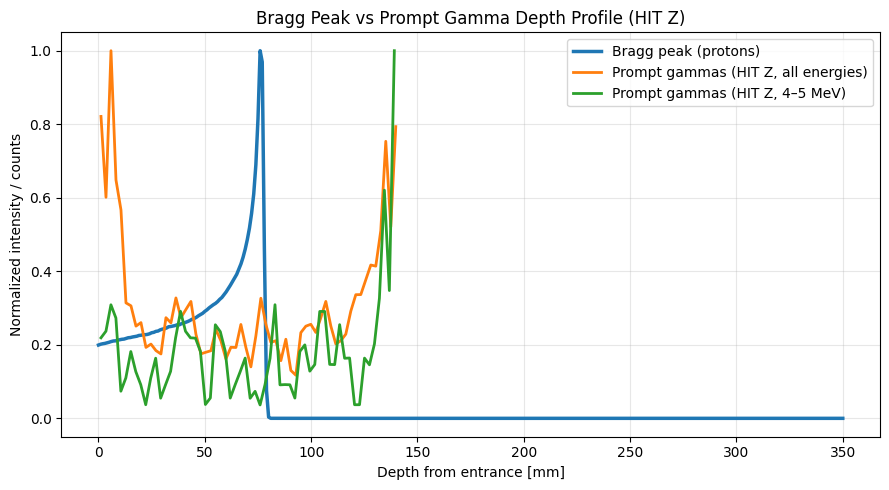

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# =====================================
# FILES
# =====================================
GAMMA_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100_100000.csv"
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/100.000000-MEV-100000-EVTS_protons.txt"

# =====================================
# COLUMN INDICES
# =====================================
HIT_Z_COL  = 3
ENERGY_COL = 11

# =====================================
# PARAMETERS
# =====================================
E_MIN, E_MAX = 4.0, 5.0
Z_MIN, Z_MAX = -350, 350
N_BINS = 60
SMOOTH_SIGMA = 0.6

# =====================================
# READ GAMMA DATA (MANUAL PARSE)
# =====================================
z_all = []
z_45  = []

with open(GAMMA_FILE) as f:
    lines = f.readlines()[1:]

for line in lines:
    parts = line.split(",")
    try:
        z = float(parts[HIT_Z_COL])
        E = float(parts[ENERGY_COL])

        if Z_MIN <= z <= Z_MAX:
            z_all.append(z)
            if E_MIN <= E <= E_MAX:
                z_45.append(z)
    except:
        continue

z_all = np.array(z_all)
z_45  = np.array(z_45)

print("Gamma counts (HIT Z):")
print(" All energies:", len(z_all))
print(" 4–5 MeV:", len(z_45))

# =====================================
# FUNCTION TO BUILD DEPTH PROFILE
# =====================================
def depth_profile(z):
    z = z - z.min()   # align to Z = 0
    counts, edges = np.histogram(z, bins=N_BINS)
    centers = 0.5 * (edges[:-1] + edges[1:])
    counts = gaussian_filter1d(counts.astype(float), SMOOTH_SIGMA)
    return centers, counts / counts.max()

# Gamma profiles
x_all, c_all = depth_profile(z_all)
x_45,  c_45  = depth_profile(z_45)

# =====================================
# BRAGG PEAK
# =====================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX","iY","iZ","Edep","Edep2","Entries"]
)

z_bragg = bragg_df["iZ"].values
dose = bragg_df["Edep"].values

mask = (z_bragg >= Z_MIN) & (z_bragg <= Z_MAX)
z_bragg = z_bragg[mask]
dose = dose[mask]

z_bragg = z_bragg - z_bragg.min()   # align to Z = 0
dose = dose / dose.max()

# =====================================
# PLOT
# =====================================
plt.figure(figsize=(9,5))

plt.plot(z_bragg, dose, lw=2.5, label="Bragg peak (protons)")
plt.plot(x_all, c_all, lw=2, label="Prompt gammas (HIT Z, all energies)")
plt.plot(x_45,  c_45,  lw=2, label="Prompt gammas (HIT Z, 4–5 MeV)")

plt.xlabel("Depth from entrance [mm]")
plt.ylabel("Normalized intensity / counts")
plt.title("Bragg Peak vs Prompt Gamma Depth Profile (HIT Z)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
